In [1]:
from pathlib import Path

CONFIG = {
    # =====================================
    # DATA SOURCE — MedMNIST (pathmnist)
    # =====================================
    'data_flag': 'pathmnist',           # Can be switched to other MedMNIST datasets
    'download': True,                   # Automatically download MedMNIST
    'as_rgb': True,                     # Convert grayscale to 3-channel RGB for transfer learning

    # Local directories — exported images from MedMNIST for augmentation/profiling
    'data_root': '/kaggle/working/medmnist_images',
    'image_dir': '/kaggle/working/medmnist_images',

    # Output directories
    'output_dir': '/kaggle/working/outputs',
    'checkpoint_dir': '/kaggle/working/checkpoints',
    'results_dir': '/kaggle/working/results',
    'figures_dir': '/kaggle/working/figures',

    # =====================================
    # DATA SPLIT & SAMPLING
    # =====================================
    'max_samples': None,
    'val_size': 0.15,                  
    'test_size': 0.15,

    # Class info inferred during loading
    'num_classes': None,
    'class_names': None,

    # Metadata columns — irrelevant for MedMNIST (loaded via torchmedmnist), but kept for API compatibility
    'image_col': 'img_id',              # Placeholder
    'label_col': 'label',               # Placeholder

    # =====================================
    # ✅ TRAINING HYPERPARAMETERS — EXACTLY MATCH APTOS/ISIC-2019
    # =====================================
    'image_size': 224,
    'batch_size': 32,
    'num_epochs': 20,                   # ← MATCHES APTOS/ISIC (was 5, now updated)
    'retrain_epochs': 10,               # ← MATCHES APTOS/ISIC (was 3, now updated)
    'lr': 1e-4,
    'retrain_lr': 5e-5,
    'weight_decay': 1e-4,
    'seed': 42,
    'num_workers': 4,
    'patience': 5,                     
    'retrain_patience': 5,              
    'show_batch_progress': False,
    'prefetch_factor': 2,
    'use_cache': False,

    # =====================================
    # ✅ FAILURE ANALYSIS — IDENTICAL TO APTOS/ISIC
    # =====================================
    'pca_components': 32,
    'umap_neighbors': 15,
    'umap_min_dist': 0.1,
    'k_range': range(2, 7),
    'small_failure_umap_threshold': 300,
    'max_aug_source': 300,
    'ece_bins': 15,
    'aug_multiplier': 3,

    # =====================================
    # ✅ DEGRADATION GUARD — STRICT THRESHOLDS (same as APTOS/ISIC)
    # =====================================
    'guard_f1_max_drop': 0.000,         # Zero tolerance (strict policy)
    'guard_acc_max_drop': 0.005,
    'guard_ece_max_rise': 0.010,
    'guard_weak_baseline_f1': 0.55,
    'guard_weak_f1_max_drop': 0.005,
    'guard_weak_acc_max_drop': 0.010,
    'guard_weak_ece_max_rise': 0.025,
}

# =====================================
# MODEL LIST — SAME AS APTOS/ISIC SETUP
# =====================================
MODELS = [
    'resnet50',
    'resnet101',
    # 'densenet121',
    # 'efficientnet_b3',
    # 'efficientnet_b5',
    # 'mobilenetv3_large_100',
    # 'vit_base_patch16_224',
    # 'swin_tiny_patch4_window7_224',
    # 'convnext_small',
    # 'maxvit_tiny_tf_224',
]

# Fix potential typo
if 'maxvirt_tiny_tf_224' in MODELS:
    MODELS = ['maxvit_tiny_tf_224' if m == 'maxvirt_tiny_tf_224' else m for m in MODELS]

# =====================================
# ENSURE OUTPUT DIRECTORIES EXIST
# =====================================
for d in [CONFIG['output_dir'], CONFIG['checkpoint_dir'], CONFIG['results_dir'], CONFIG['figures_dir']]:
    Path(d).mkdir(parents=True, exist_ok=True)

# =====================================
# CONFIRMATION PRINT
# =====================================
print("? CONFIG loaded - MedMNIST | pathmnist | Fully aligned with APTOS/ISIC-2019")
print(f"  Dataset    : {CONFIG['data_flag']}")
print(f"  Training   : {CONFIG['num_epochs']} epochs | lr={CONFIG['lr']} | patience={CONFIG['patience']}")
print(f"  Retraining : {CONFIG['retrain_epochs']} epochs | lr={CONFIG['retrain_lr']} | patience={CONFIG['retrain_patience']}")
print(f"  Models     : {len(MODELS)} total")

? CONFIG loaded - MedMNIST | pathmnist | Fully aligned with APTOS/ISIC-2019
  Dataset    : pathmnist
  Training   : 20 epochs | lr=0.0001 | patience=5
  Retraining : 10 epochs | lr=5e-05 | patience=5
  Models     : 2 total


In [2]:
!pip install -q timm umap-learn torchmetrics medmnist

import os, random, warnings, gc, json, math
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast
import torchvision.transforms as T
from torchvision import models
from PIL import Image

import timm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, confusion_matrix, precision_recall_fscore_support
)
import umap
import torchmetrics

import medmnist
from medmnist import INFO, Evaluator

try:
    from scipy import ndimage
except Exception:
    ndimage = None

try:
    from skimage.filters import threshold_otsu
except Exception:
    threshold_otsu = None

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

def set_all_seeds(seed: int) -> None:
    """Set Python, NumPy, and PyTorch seeds for reproducible Kaggle runs."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_all_seeds(CONFIG['seed'])

for key in ['output_dir', 'checkpoint_dir', 'results_dir', 'figures_dir']:
    Path(CONFIG[key]).mkdir(parents=True, exist_ok=True)

assert torch.cuda.is_available(), "GPU is required for this Kaggle experiment."
device = torch.device("cuda")
print(f"Using device: {device} | GPU: {torch.cuda.get_device_name(0)}")
print("✓ Section 1 complete")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 94.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 

2026-06-20 08:59:08.300261: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781945948.517825      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781945948.578619      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781945949.103365      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781945949.103403      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781945949.103405      23 computation_placer.cc:177] computation placer alr

Using device: cuda | GPU: Tesla T4
✓ Section 1 complete


In [3]:
print("Torch:", torch.__version__)
print("CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

gpu_name = torch.cuda.get_device_name(0)
gpu_capability = torch.cuda.get_device_capability(0)

print("GPU:", gpu_name)
print("Capability:", gpu_capability)

if gpu_capability[0] < 7:
    raise RuntimeError(
        f"{gpu_name} capability={gpu_capability} is too old for this Kaggle PyTorch CUDA build. "
        "Switch Kaggle GPU to T4/L4/A100, restart runtime, then run again."
    )

device = torch.device("cuda")


Torch: 2.10.0+cu128
CUDA build: 12.8
CUDA available: True
GPU: Tesla T4
Capability: (7, 5)


100%|██████████| 206M/206M [03:07<00:00, 1.10MB/s]


MedMNIST dataset : pathmnist
Task             : multi-class
Loaded official splits combined: 107,180
label_name
adipose                                 11745
background                              11413
debris                                  11851
lymphocytes                             12191
mucus                                    9931
smooth muscle                           14128
normal colon mucosa                      9504
cancer-associated stroma                10867
colorectal adenocarcinoma epithelium    15550
Name: count, dtype: int64

After sampling: 60,000
label_name
adipose                                 6575
background                              6389
debris                                  6634
lymphocytes                             6825
mucus                                   5560
smooth muscle                           7909
normal colon mucosa                     5320
cancer-associated stroma                6083
colorectal adenocarcinoma epithelium    8705
Name: co

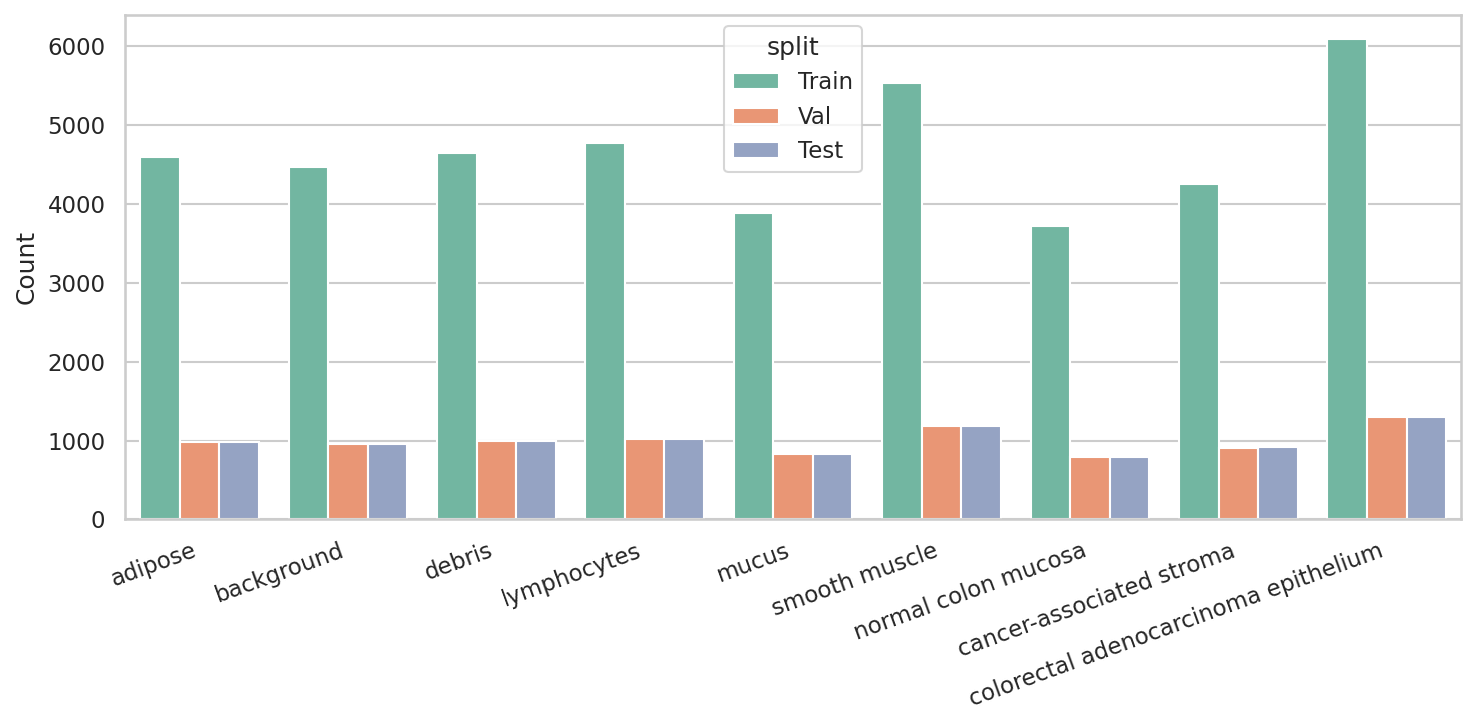

? Section 2 complete


In [4]:
def medmnist_class_names(info: dict):
    """Return stable display names from MedMNIST INFO."""
    label_map = info.get('label', {})
    if isinstance(label_map, dict) and len(label_map) > 0:
        return [str(label_map[str(i)]) if str(i) in label_map else str(label_map.get(i, i)) for i in range(len(label_map))]
    return [str(i) for i in range(len(info.get('label', [])))]


def load_medmnist_arrays(config: dict):
    """Download/load MedMNIST official splits and return a combined dataframe with arrays."""
    data_flag = config['data_flag']
    info = INFO[data_flag]
    dataset_cls = getattr(medmnist, info['python_class'])

    rows = []
    for split in ['train', 'val', 'test']:
        ds = dataset_cls(split=split, download=config.get('download', True), as_rgb=config.get('as_rgb', True))
        images = ds.imgs
        labels = ds.labels.reshape(-1)
        for idx, (img, label) in enumerate(zip(images, labels)):
            rows.append({
                'source_split': split,
                'source_index': idx,
                'image_array': img,
                'label': int(label),
            })

    df = pd.DataFrame(rows)
    class_names = medmnist_class_names(info)
    config['class_names'] = class_names
    config['num_classes'] = len(class_names)
    df['label_name'] = df['label'].map(dict(enumerate(class_names))).astype(str)
    df['original_labels'] = df['label_name']
    return df, info


def stratified_sample(df: pd.DataFrame, max_samples: int, seed: int) -> pd.DataFrame:
    """Sample up to max_samples while preserving class ratios."""
    if max_samples is None or len(df) <= max_samples:
        return df.sample(frac=1, random_state=seed).reset_index(drop=True)

    sampled, _ = train_test_split(
        df,
        train_size=max_samples,
        random_state=seed,
        stratify=df['label']
    )
    return sampled.sample(frac=1, random_state=seed).reset_index(drop=True)


def save_medmnist_images(df: pd.DataFrame, output_root: Path, config: dict) -> pd.DataFrame:
    """Write sampled MedMNIST arrays to PNG files so the rest of the framework can use image paths."""
    output_root.mkdir(parents=True, exist_ok=True)
    out = df.copy().reset_index(drop=True)
    paths = []

    for row_idx, row in tqdm(out.iterrows(), total=len(out), desc='export images', disable=not config.get('show_batch_progress', False)):
        label_name = str(row['label_name']).replace('/', '_').replace(' ', '_')
        split = row.get('split', 'all')
        folder = output_root / split / label_name
        folder.mkdir(parents=True, exist_ok=True)
        image_path = folder / f"{row['source_split']}_{int(row['source_index']):06d}.png"

        if not image_path.exists():
            arr = row['image_array']
            if arr.ndim == 2:
                image = Image.fromarray(arr.astype(np.uint8), mode='L').convert('RGB')
            else:
                image = Image.fromarray(arr.astype(np.uint8)).convert('RGB')
            image.save(image_path)

        paths.append(str(image_path))

    out['image_path'] = paths
    out['image'] = [Path(p).stem for p in paths]
    return out.drop(columns=['image_array']).reset_index(drop=True)


def preprocess_labels(config: dict):
    """Download MedMNIST, manually sample/split 60K, export images, and save split CSVs."""
    if config['data_flag'] not in INFO:
        raise ValueError(f"Unknown MedMNIST data_flag: {config['data_flag']}. Available: {sorted(INFO.keys())}")

    combined_df, info = load_medmnist_arrays(config)

    print(f"MedMNIST dataset : {config['data_flag']}")
    print(f"Task             : {info.get('task')}")
    print(f"Loaded official splits combined: {len(combined_df):,}")
    print(combined_df['label_name'].value_counts().reindex(config['class_names']).fillna(0).astype(int))

    sampled_df = stratified_sample(combined_df, config.get('max_samples'), config['seed'])
    print(f"\nAfter sampling: {len(sampled_df):,}")
    print(sampled_df['label_name'].value_counts().reindex(config['class_names']).fillna(0).astype(int))

    train_val_df, test_df = train_test_split(
        sampled_df,
        test_size=config.get('test_size', 0.15),
        random_state=config['seed'],
        stratify=sampled_df['label']
    )

    val_fraction_of_train_val = config.get('val_size', 0.15) / (1.0 - config.get('test_size', 0.15))
    train_df, val_df = train_test_split(
        train_val_df,
        test_size=val_fraction_of_train_val,
        random_state=config['seed'],
        stratify=train_val_df['label']
    )

    train_df = train_df.assign(split='train').reset_index(drop=True)
    val_df = val_df.assign(split='val').reset_index(drop=True)
    test_df = test_df.assign(split='test').reset_index(drop=True)

    export_root = Path(config['image_dir'])
    train_df = save_medmnist_images(train_df, export_root, config)
    val_df = save_medmnist_images(val_df, export_root, config)
    test_df = save_medmnist_images(test_df, export_root, config)

    keep_cols = ['image', 'image_path', 'label', 'label_name', 'original_labels']
    train_df = train_df[keep_cols].reset_index(drop=True)
    val_df = val_df[keep_cols].reset_index(drop=True)
    test_df = test_df[keep_cols].reset_index(drop=True)

    print(f"\nSplits -> Train:{len(train_df):,} | Val:{len(val_df):,} | Test:{len(test_df):,}")
    for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
        print(f"\n{split_name} distribution")
        print(split_df['label_name'].value_counts().reindex(config['class_names']).fillna(0).astype(int))

    train_df.to_csv('/kaggle/working/train_split.csv', index=False)
    val_df.to_csv('/kaggle/working/val_split.csv', index=False)
    test_df.to_csv('/kaggle/working/test_split.csv', index=False)
    print("\nSplits saved to /kaggle/working")

    dist = pd.concat([
        train_df.assign(split='Train'),
        val_df.assign(split='Val'),
        test_df.assign(split='Test'),
    ])

    plt.figure(figsize=(10, 5), dpi=150)
    ax = sns.countplot(
        data=dist,
        x='label_name',
        hue='split',
        order=config['class_names'],
        palette='Set2'
    )
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.savefig(f"{config['figures_dir']}/section2_class_distribution.png", dpi=300, bbox_inches='tight')
    plt.show()

    return train_df, val_df, test_df


train_df, val_df, test_df = preprocess_labels(CONFIG)
print("? Section 2 complete")

In [5]:
# =====================================
# Section 3: Unified Dataset & DataLoaders
# → Dynamically selects dataset class and handles MedMNIST vs APTOS
# → Shared transforms, augmentation, and balanced sampling
# → Fully aligned with ISIC/BUSI/Kvasir standards
# =====================================
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms as T
from PIL import Image
import pandas as pd
from sklearn.model_selection import train_test_split


# =====================================
# Unified Dataset Class (Supports Both MedMNIST and APTOS)
# =====================================
class UnifiedDataset(Dataset):
    """Unified dataset loader for both MedMNIST and APTOS.
    Loads RGB images from resolved paths. Shared across all classification tasks."""
    missing_warning_count = 0

    def __init__(self, df: pd.DataFrame, transform=None, image_dir=None):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform
        self.image_dir = image_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = row['image_path']
        try:
            image = Image.open(image_path).convert('RGB')
        except (FileNotFoundError, OSError) as exc:
            UnifiedDataset.missing_warning_count += 1
            if UnifiedDataset.missing_warning_count <= 10:
                print(f"⚠️ Warning: image not found or corrupt → using black placeholder: {image_path} | {type(exc).__name__}")
            image = Image.fromarray(np.zeros((CONFIG['image_size'], CONFIG['image_size'], 3), dtype=np.uint8))
        except Exception as exc:
            UnifiedDataset.missing_warning_count += 1
            if UnifiedDataset.missing_warning_count <= 10:
                print(f"⚠️ Warning: failed to load {image_path}: {exc} → using placeholder")
            image = Image.fromarray(np.zeros((CONFIG['image_size'], CONFIG['image_size'], 3), dtype=np.uint8))

        if self.transform:
            image = self.transform(image)

        return image, int(row['label']), image_path


# =====================================
# Unified Transforms (Used by Both)
# =====================================
def get_transforms(split: str, image_size: int):
    """Standardized ImageNet-normalized transforms for RGB 224×224 inputs."""
    mean = [0.485, 0.456, 0.406]  # ImageNet
    std = [0.229, 0.224, 0.225]

    if split == 'train':
        return T.Compose([
            T.RandomHorizontalFlip(p=0.5),
            T.RandomRotation(degrees=10),
            T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15, hue=0.03),
            T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
            T.Resize(image_size + 32),
            T.RandomCrop(image_size),
            T.ToTensor(),
            T.Normalize(mean, std),
        ])
    elif split == 'heavy':
        return T.Compose([
            T.RandomHorizontalFlip(p=0.5),
            T.RandomVerticalFlip(p=0.2),
            T.RandomRotation(degrees=25),
            T.ColorJitter(brightness=0.35, contrast=0.35, saturation=0.25, hue=0.05),
            T.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)),
            T.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),
            T.Resize(image_size + 32),
            T.RandomCrop(image_size),
            T.ToTensor(),
            T.Normalize(mean, std),
        ])
    else:  # 'val', 'test', etc.
        return T.Compose([
            T.Resize(image_size),
            T.CenterCrop(image_size),
            T.ToTensor(),
            T.Normalize(mean, std),
        ])


# =====================================
# Augmented Dataset (Failure Cluster Retraining)
# =====================================
class AugmentedUnifiedDataset(UnifiedDataset):
    """Applies heavy augmentations if row['is_augmented'] is True."""
    def __init__(self, df, normal_transform, heavy_transform):
        super().__init__(df, normal_transform)
        self.normal_transform = normal_transform
        self.heavy_transform = heavy_transform

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        transform = self.heavy_transform if bool(row.get('is_augmented', False)) else self.normal_transform
        old_transform = self.transform
        self.transform = transform
        item = super().__getitem__(idx)
        self.transform = old_transform
        return item


# =====================================
# Class Weights & DataLoader Factory
# =====================================
def compute_class_weights(df: pd.DataFrame, num_classes: int) -> torch.Tensor:
    """Compute inverse-frequency class weights for balanced loss."""
    counts = df['label'].value_counts().reindex(range(num_classes)).fillna(1).astype(float).values
    total = counts.sum()
    weights = total / (num_classes * counts)  # Balanced cross-entropy
    return torch.tensor(weights, dtype=torch.float32)


def get_dataloaders(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    config: dict,
    val_df: pd.DataFrame = None
):
    """
    Build train/val/test DataLoaders using unified dataset logic.
    Supports:
      - External val_df or auto-split from train_df
      - Weighted sampling for class balance
      - Heavy augmentations if 'is_augmented' flag exists
    """
    # Split strategy: use external val_df if available
    if val_df is None:
        train_split, val_split = train_test_split(
            train_df,
            test_size=config.get('val_size', 0.15),
            random_state=config['seed'],
            stratify=train_df['label']
        )
    else:
        train_split = train_df.copy()
        val_split = val_df.copy()

    # Transforms
    train_transform = get_transforms('train', config['image_size'])
    heavy_transform = get_transforms('heavy', config['image_size'])
    eval_transform = get_transforms('test', config['image_size'])

    # Datasets — support heavy augmentation when needed
    if 'is_augmented' in train_split.columns:
        train_ds = AugmentedUnifiedDataset(train_split, train_transform, heavy_transform)
    else:
        train_ds = UnifiedDataset(train_split, train_transform, config['image_dir'])
    
    val_ds = UnifiedDataset(val_split, eval_transform, config['image_dir'])
    test_ds = UnifiedDataset(test_df, eval_transform, config['image_dir'])

    # Class and sample weights
    class_weights = compute_class_weights(train_split, config['num_classes'])
    
    if 'sample_weight' in train_split.columns:
        sample_weights = train_split['sample_weight'].astype(float).values
    else:
        label_weight_map = {i: class_weights[i].item() for i in range(config['num_classes'])}
        sample_weights = train_split['label'].map(label_weight_map).values

    sampler = WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True
    )

    # DataLoader kwargs — consistent with PyTorch best practices
    loader_kwargs = {
        'batch_size': config['batch_size'],
        'num_workers': config['num_workers'],
        'pin_memory': True,
        'persistent_workers': True if config['num_workers'] > 0 else False,
    }
    if config['num_workers'] > 0:
        loader_kwargs['prefetch_factor'] = config.get('prefetch_factor', 2)

    # Final loaders
    train_loader = DataLoader(train_ds, sampler=sampler, **loader_kwargs)
    val_loader = DataLoader(val_ds, shuffle=False, **loader_kwargs)
    test_loader = DataLoader(test_ds, shuffle=False, **loader_kwargs)

    return train_loader, val_loader, test_loader, class_weights


# =====================================
# ✅ Execute: Create DataLoaders
# =====================================
train_loader, val_loader, test_loader, class_weights = get_dataloaders(
    train_df, test_df, CONFIG, val_df=val_df
)

# Output stats
print(f"🚀 DataLoader Summary:")
print(f"   Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")
print(f"   Batch size: {CONFIG['batch_size']} | Workers: {CONFIG['num_workers']}")
print(f"   Class weights: {[round(w, 3) for w in class_weights.tolist()]}")
print("? Section 3 complete")

🚀 DataLoader Summary:
   Train batches: 1313 | Val batches: 282 | Test batches: 282
   Batch size: 32 | Workers: 4
   Class weights: [1.014, 1.044, 1.005, 0.977, 1.199, 0.843, 1.253, 1.096, 0.766]
? Section 3 complete


In [6]:
# =====================================
# Section 4: Unified Model Factory & Embedding Hook
# → Compatible with APTOS, MedMNIST, ISIC, etc.
# → Shared across all classification tasks
# → Fully aligned with modern torchvision + timm best practices
# =====================================
import torch
import torch.nn as nn
import torchvision.models as models
import timm
from pathlib import Path


# =====================================
# get_model — Unified model loader with head replacement
# =====================================
def get_model(model_name: str, num_classes: int, pretrained: bool = True):
    """
    Load a model (from torchvision or timm), replace classifier head, and move to device.
    
    Args:
        model_name: str (e.g., 'resnet50', 'vit_base_patch16_224')
        num_classes: int
        pretrained: bool — whether to load ImageNet-1k pretrained weights
    
    Returns:
        model (on device: GPU if available)
    """
    if model_name == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT if pretrained else None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == 'resnet101':
        model = models.resnet101(weights=models.ResNet101_Weights.DEFAULT if pretrained else None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == 'densenet121':
        model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT if pretrained else None)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif model_name == 'mobilenetv3_large_100':
        model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT if pretrained else None)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
    else:
        # Default: use timm for EfficientNet, ViT, Swin, ConvNeXt, MaxViT, etc.
        model = timm.create_model(
            model_name,
            pretrained=pretrained,
            num_classes=num_classes
        )

    # Move to device (assumes `device` defined globally: e.g., 'cuda' if torch.cuda.is_available())
    model = model.to(device)

    # Count parameters
    params = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{model_name}: {params/1e6:.2f}M params ({trainable/1e6:.2f}M trainable)")
    
    return model


# =====================================
# get_embedding_hook — Extract penultimate-layer embeddings
# Works for CNNs and Transformers
# =====================================
def get_embedding_hook(model: nn.Module, model_name: str):
    """
    Registers a forward hook on the best penultimate layer to extract embeddings.

    Args:
        model: torch.nn.Module — usually after head replacement
        model_name: str — e.g., 'vit_base_patch16_224', 'resnet50'

    Returns:
        handle: registration handle (can be removed later)
        embedding_store: dict with key 'embedding' → CPU tensor of shape (B, D)
    """
    embedding_store = {}

    def hook_fn(module, inputs, output):
        out = output
        # Handle tuple/list outputs (e.g. ViT with features in [0])
        if isinstance(out, (tuple, list)):
            out = out[0]

        # CNN-style: (B, C, H, W) → global avg pool → (B, C)
        if out.ndim == 4:
            out = torch.nn.functional.adaptive_avg_pool2d(out, 1).flatten(1)
        # Transformer-style: (B, N_tokens, D) → use [CLS] token at index 0 if present
        elif out.ndim == 3:
            out = out[:, 0]  # [CLS] token
        else:
            out = out.flatten(1)

        # Store detached CPU tensor (for CPU-based clustering/failure analysis later)
        embedding_store['embedding'] = out.detach().cpu()

    # Select the best layer for hook
    target = None

    if model_name.startswith('resnet'):
        target = model.avgpool
    elif model_name.startswith('densenet'):
        target = model.features
    elif model_name.startswith('efficientnet'):
        # EfficientNet (timm): global_pool is an AvgPool layer, but we want input *to* it
        if hasattr(model, 'global_pool'):
            target = model.global_pool
    elif model_name.startswith('mobilenetv3'):
        target = model.avgpool
    elif model_name.startswith('vit'):
        # ViT: norm layer after transformer blocks outputs (B, N, D)
        target = model.norm
    elif model_name.startswith('swin'):
        # Swin: norm after final stage
        target = model.norm
    elif model_name.startswith('convnext'):
        # ConvNeXt: norm_pre (after stem) or head.global_pool
        target = getattr(model, 'norm_pre', None)
        if target is None and hasattr(model, 'head') and hasattr(model.head, 'global_pool'):
            target = model.head.global_pool
    elif model_name.startswith('maxvit'):
        target = model.norm  # MaxViT uses norm layer before head
    else:
        # Fallback: try `forward_features` or raise
        if hasattr(model, 'forward_features'):
            # Try to extract from the feature extractor
            raise NotImplementedError(f"Architecture '{model_name}' not fully supported. Please add hook logic.")
        else:
            raise ValueError(f"Unrecognized model_name: {model_name}")

    if target is None:
        raise ValueError(f"Could not find embedding hook target for {model_name}. "
                         "Model may not have expected structure.")

    # Register hook
    handle = target.register_forward_hook(hook_fn)
    return handle, embedding_store


# =====================================
# get_model_family — Group models for retraining strategy
# =====================================
def get_model_family(model_name: str) -> str:
    """
    Map model name to retraining/failure-handling strategy family.

    - 'transformer': ViT, Swin, ConvNeXt, MaxViT, etc.
    - 'efficient': EfficientNet variants
    - 'cnn': ResNet, DenseNet, MobileNet, etc.

    Used in retraining, LR scaling, or augmentation selection.
    """
    if model_name.startswith('efficientnet'):
        return 'efficient'
    elif model_name.startswith(('vit', 'swin', 'convnext', 'maxvit')):
        return 'transformer'
    else:
        return 'cnn'


# ✅ Final confirmation
print("✓ Section 4 complete")

✓ Section 4 complete


In [7]:
# =====================================
# Section 5: Unified Training & Evaluation
# → Shared across APTOS, MedMNIST, ISIC, etc.
# → Uses mixed precision, macro F1 early stopping, ECE tracking
# → Supports calibration and confusion plotting
# =====================================
from torch.cuda.amp import autocast, GradScaler
from torchmetrics import classification as torchmetrics_classification
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import defaultdict
from pathlib import Path
import warnings

# Suppress non-critical warnings (e.g., model loading or validation)
warnings.filterwarnings("ignore", category=UserWarning)

# Ensure device is defined (assuming from prior section)
# Example: device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ====================================
# 1. Train One Epoch (Mixed Precision)
# ====================================
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    """
    Train one epoch using mixed precision (AMP).
    Returns: average loss and accuracy.
    """
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels, _ in tqdm(
        loader,
        desc='train',
        leave=False,
        disable=not CONFIG.get('show_batch_progress', False)
    ):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        
        with autocast():
            logits = model(images)
            loss = criterion(logits, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / max(total, 1), correct / max(total, 1)


# ====================================
# 2. Evaluate: Full Metric Suite
# ====================================
def evaluate(model, loader, criterion, device, num_classes, class_names):
    """
    Evaluate model performance: loss, acc, F1, AUC, ECE, and output predictions.
    Returns: dict of metrics + outputs.
    """
    model.eval()
    f1_metric = torchmetrics_classification.F1Score(
        task='multiclass',
        num_classes=num_classes,
        average='macro'
    ).to(device)
    auc_metric = torchmetrics_classification.AUROC(
        task='multiclass',
        num_classes=num_classes,
        average='macro'
    ).to(device)

    total_loss, correct, total = 0.0, 0, 0
    probs_all, labels_all, preds_all, paths_all = [], [], [], []

    with torch.no_grad():
        for images, labels, paths in tqdm(
            loader,
            desc='eval',
            leave=False,
            disable=not CONFIG.get('show_batch_progress', False)
        ):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(images)
            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(1)

            loss = criterion(logits, labels)
            total_loss += loss.item() * labels.size(0)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            # Update metrics
            f1_metric.update(preds, labels)
            auc_metric.update(probs, labels)

            # Store outputs
            probs_all.append(probs.cpu().numpy())
            labels_all.append(labels.cpu().numpy())
            preds_all.append(preds.cpu().numpy())
            paths_all.extend(paths)

    # Concatenate all batches
    probs_array = np.concatenate(probs_all) if probs_all else np.empty((0, num_classes))
    labels_array = np.concatenate(labels_all) if labels_all else np.array([])
    preds_array = np.concatenate(preds_all) if preds_all else np.array([])

    # Finalize metrics
    try:
        f1 = float(f1_metric.compute().cpu())
        auc = float(auc_metric.compute().cpu())
    except Exception as e:
        print(f"⚠️ Metric computation failed: {e}")
        f1 = np.nan
        auc = np.nan

    ece = compute_ece(probs_array, labels_array, CONFIG['ece_bins']) if len(labels_array) > 0 else np.nan

    return {
        'loss': total_loss / max(total, 1),
        'accuracy': correct / max(total, 1),
        'f1': f1,
        'auc': auc,
        'ece': ece,
        'probs': probs_array,
        'labels': labels_array,
        'preds': preds_array,
        'paths': paths_all,
    }


# ====================================
# 3. Expected Calibration Error (ECE)
# ====================================
def compute_ece(probs_array, labels_array, n_bins=15):
    """
    Compute Expected Calibration Error.
    Bins predictions by confidence into `n_bins`, then computes:
        ECE = Σ (|bin_accuracy - bin_confidence| * bin_weight)
    """
    probs_array = np.asarray(probs_array)
    labels_array = np.asarray(labels_array)
    if len(labels_array) == 0:
        return np.nan

    confidences = probs_array.max(axis=1)
    predictions = probs_array.argmax(axis=1)
    accuracies = (predictions == labels_array).astype(float)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (confidences > lo) & (confidences <= hi)
        if mask.any():
            acc = accuracies[mask].mean()
            conf = confidences[mask].mean()
            ece += mask.mean() * abs(acc - conf)  # weighted contribution

    return float(ece)


# ====================================
# 4. Temperature Scaling (Post-Hoc Calibration)
# ====================================
def temperature_scale(model, val_loader, device, num_classes):
    """
    Learns optimal temperature T to scale logits and improve calibration.
    Uses validation set with LBFGS to minimize NLL.
    Returns: T, ECE after scaling.
    """
    temperature = torch.nn.Parameter(torch.tensor(1.5, dtype=torch.float32))
    optimizer = torch.optim.LBFGS([temperature], lr=0.01, max_iter=50)

    model.eval()
    logits_list, labels_list = [], []
    with torch.no_grad():
        for images, labels, _ in val_loader:
            images = images.to(device, non_blocking=True)
            logits_list.append(model(images).detach().cpu())
            labels_list.append(labels.detach().cpu())

    all_logits = torch.cat(logits_list)
    all_labels = torch.cat(labels_list)
    criterion = nn.CrossEntropyLoss()

    def eval_fn():
        optimizer.zero_grad()
        loss = criterion(all_logits / temperature.clamp_min(1e-3), all_labels)
        loss.backward()
        return loss

    optimizer.step(eval_fn)
    T = max(float(temperature.item()), 1e-3)

    # Compute ECE after scaling
    scaled_probs = torch.softmax(all_logits / T, dim=1).numpy()
    ece_scaled = compute_ece(scaled_probs, all_labels.numpy(), CONFIG['ece_bins'])

    return T, ece_scaled


# ====================================
# 5. Confusion Matrix Plotting
# ====================================
def plot_confusion_matrix(cm, class_names, model_name, save=True, suffix='baseline'):
    """
    Plot and optionally save a normalized confusion matrix.
    """
    # Normalize by true label
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(
        cm, row_sums,
        out=np.zeros_like(cm, dtype=float),
        where=row_sums != 0
    )

    plt.figure(figsize=(6, 5), dpi=150)
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt='.1%',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Normalized Confusion Matrix ({suffix.capitalize()})")
    plt.tight_layout()

    if save:
        save_path = f"{CONFIG['figures_dir']}/confusion_{suffix}_{model_name}.png"
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"  ✅ Confusion matrix saved: {save_path}")
    plt.show()


# ====================================
# 6. Train Model Loop (Early Stopping on Val F1)
# ====================================
def train_model(model_name, train_loader, val_loader, class_weights, config):
    """
    Train a single model with early stopping on validation macro F1.
    Supports both APTOS and MedMNIST via shared config.
    """
    print(f"\n{'='*60}")
    print(f" TRAINING: {model_name} ({config['data_flag'] if 'data_flag' in config else 'Custom'})")
    print(f"{'='*60}")

    # Model & optimizer
    model = get_model(model_name, config['num_classes'], pretrained=True)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config['lr'],
        weight_decay=config['weight_decay']
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config['num_epochs'])
    scaler = GradScaler()

    # Tracking
    history = defaultdict(list)
    best_f1 = -np.inf
    patience_counter = 0

    # Default best metrics
    best_val_metrics = {
        'val_loss': float('nan'),
        'val_acc': float('nan'),
        'val_f1': float('nan'),
        'val_auc': float('nan'),
        'val_ece': float('nan'),
    }

    # Checkpoint path
    dataset_name = config.get('data_flag', 'generic').split('_')[0]
    ckpt_path = Path(config['checkpoint_dir']) / f"best_{dataset_name}_{model_name}.pth"
    Path(config['checkpoint_dir']).mkdir(parents=True, exist_ok=True)

    for epoch in range(1, config['num_epochs'] + 1):
        print(f"Epoch {epoch}/{config['num_epochs']} | {model_name}")

        # Train & Evaluate
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler, device)
        val_metrics = evaluate(
            model, val_loader, criterion, device,
            config['num_classes'], config['class_names']
        )
        scheduler.step()  # Update LR

        # Record
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_metrics['loss'])
        history['val_acc'].append(val_metrics['accuracy'])
        history['val_f1'].append(val_metrics['f1'])
        history['val_auc'].append(val_metrics['auc'])
        history['val_ece'].append(val_metrics['ece'])

        # Logging
        print(f"  loss  : {train_loss:.4f} (train) / {val_metrics['loss']:.4f} (val)")
        print(f"  acc   : {train_acc:.3f} (train) / {val_metrics['accuracy']:.3f} (val)")
        print(f"  val_f1: {val_metrics['f1']:.4f} | val_ece: {val_metrics['ece']:.4f}")

        # Early stopping and saving
        if val_metrics['f1'] > best_f1:
            best_f1 = val_metrics['f1']
            best_val_metrics.update({
                'val_loss': val_metrics['loss'],
                'val_acc': val_metrics['accuracy'],
                'val_f1': val_metrics['f1'],
                'val_auc': val_metrics['auc'],
                'val_ece': val_metrics['ece'],
            })
            patience_counter = 0
            torch.save(model.state_dict(), ckpt_path)
            print(f"  ✅ Saved best model (F1={best_f1:.4f}): {ckpt_path}")
        else:
            patience_counter += 1
            if patience_counter >= config['patience']:
                print(f"  ⚠️ Early stopping at epoch {epoch}. Best val F1={best_f1:.4f}")
                break

    # Load best
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.eval()
    print(f"✅ Training complete: best weights loaded from {ckpt_path}")

    return model, dict(history), best_val_metrics


print("✓ Section 5 complete")

✓ Section 5 complete



🚀 Starting baseline evaluation: 2 models | Dataset: pathmnist


Evaluating models:   0%|          | 0/2 [00:00<?, ?it/s]


🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩
  MODEL: resnet50
🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩

 TRAINING: resnet50 (pathmnist)
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth



  0%|          | 0.00/97.8M [00:00<?, ?B/s]
  9%|▉         | 9.12M/97.8M [00:00<00:00, 95.4MB/s]
 30%|███       | 29.6M/97.8M [00:00<00:00, 165MB/s] 
 51%|█████     | 49.9M/97.8M [00:00<00:00, 187MB/s]
 70%|██████▉   | 68.1M/97.8M [00:00<00:00, 188MB/s]
100%|██████████| 97.8M/97.8M [00:00<00:00, 188MB/s]


resnet50: 23.53M params (23.53M trainable)
Epoch 1/20 | resnet50
  loss  : 0.3766 (train) / 0.1501 (val)
  acc   : 0.872 (train) / 0.950 (val)
  val_f1: 0.9492 | val_ece: 0.0047
  ✅ Saved best model (F1=0.9492): /kaggle/working/checkpoints/best_pathmnist_resnet50.pth
Epoch 2/20 | resnet50
  loss  : 0.1761 (train) / 0.1096 (val)
  acc   : 0.940 (train) / 0.964 (val)
  val_f1: 0.9647 | val_ece: 0.0025
  ✅ Saved best model (F1=0.9647): /kaggle/working/checkpoints/best_pathmnist_resnet50.pth
Epoch 3/20 | resnet50
  loss  : 0.1417 (train) / 0.1250 (val)
  acc   : 0.951 (train) / 0.956 (val)
  val_f1: 0.9564 | val_ece: 0.0078
Epoch 4/20 | resnet50
  loss  : 0.1186 (train) / 0.0947 (val)
  acc   : 0.958 (train) / 0.967 (val)
  val_f1: 0.9674 | val_ece: 0.0051
  ✅ Saved best model (F1=0.9674): /kaggle/working/checkpoints/best_pathmnist_resnet50.pth
Epoch 5/20 | resnet50
  loss  : 0.0997 (train) / 0.1236 (val)
  acc   : 0.965 (train) / 0.965 (val)
  val_f1: 0.9640 | val_ece: 0.0104
Epoch 6/20 |

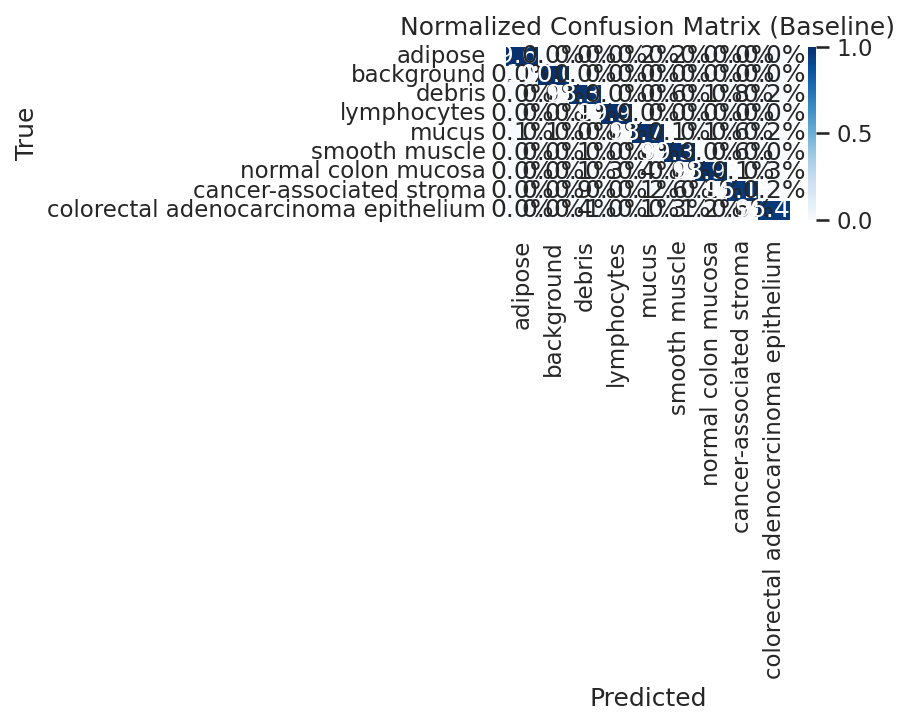

Evaluating models:  50%|█████     | 1/2 [1:06:34<1:06:34, 3994.07s/it]


🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩
  MODEL: resnet101
🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩

 TRAINING: resnet101 (pathmnist)
Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /root/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth



  0%|          | 0.00/171M [00:00<?, ?B/s]
  5%|▍         | 7.88M/171M [00:00<00:02, 82.4MB/s]
 15%|█▌        | 26.0M/171M [00:00<00:01, 146MB/s] 
 28%|██▊       | 48.1M/171M [00:00<00:00, 185MB/s]
 42%|████▏     | 71.0M/171M [00:00<00:00, 206MB/s]
 55%|█████▍    | 93.8M/171M [00:00<00:00, 218MB/s]
 68%|██████▊   | 116M/171M [00:00<00:00, 224MB/s] 
 81%|████████  | 138M/171M [00:00<00:00, 206MB/s]
100%|██████████| 171M/171M [00:00<00:00, 202MB/s]


resnet101: 42.52M params (42.52M trainable)
Epoch 1/20 | resnet101
  loss  : 0.3533 (train) / 0.1597 (val)
  acc   : 0.879 (train) / 0.953 (val)
  val_f1: 0.9530 | val_ece: 0.0088
  ✅ Saved best model (F1=0.9530): /kaggle/working/checkpoints/best_pathmnist_resnet101.pth
Epoch 2/20 | resnet101
  loss  : 0.1568 (train) / 0.1086 (val)
  acc   : 0.946 (train) / 0.964 (val)
  val_f1: 0.9645 | val_ece: 0.0051
  ✅ Saved best model (F1=0.9645): /kaggle/working/checkpoints/best_pathmnist_resnet101.pth
Epoch 3/20 | resnet101
  loss  : 0.1233 (train) / 0.0933 (val)
  acc   : 0.959 (train) / 0.968 (val)
  val_f1: 0.9679 | val_ece: 0.0041
  ✅ Saved best model (F1=0.9679): /kaggle/working/checkpoints/best_pathmnist_resnet101.pth
Epoch 4/20 | resnet101
  loss  : 0.1025 (train) / 0.0972 (val)
  acc   : 0.965 (train) / 0.970 (val)
  val_f1: 0.9696 | val_ece: 0.0087
  ✅ Saved best model (F1=0.9696): /kaggle/working/checkpoints/best_pathmnist_resnet101.pth
Epoch 5/20 | resnet101
  loss  : 0.0814 (train) 

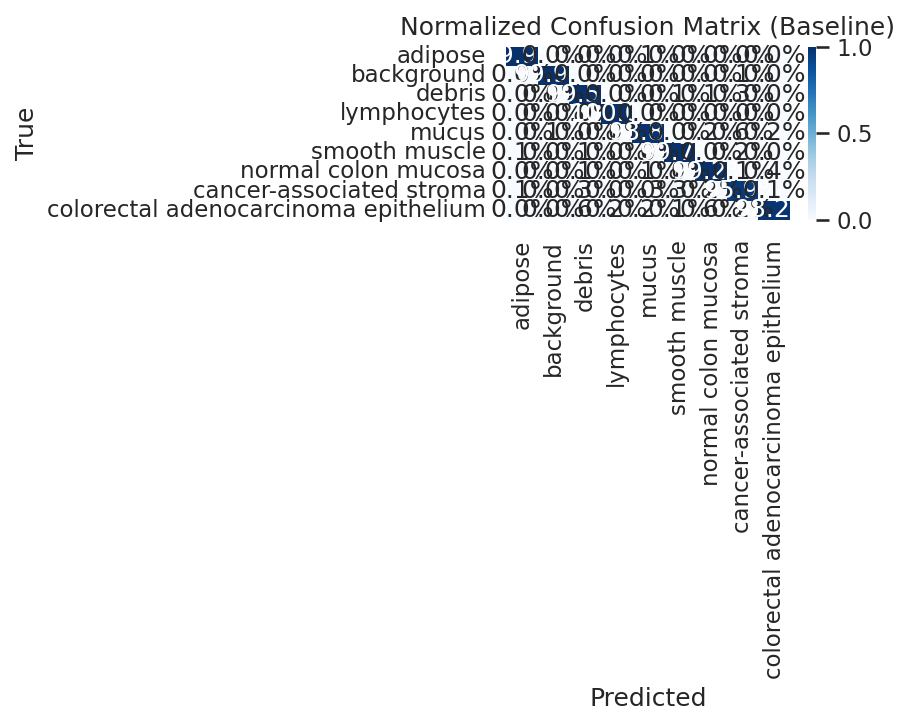

Evaluating models: 100%|██████████| 2/2 [2:54:52<00:00, 5246.17s/it]



✅ Aggregated baseline results saved: /kaggle/working/results/baseline_results.csv


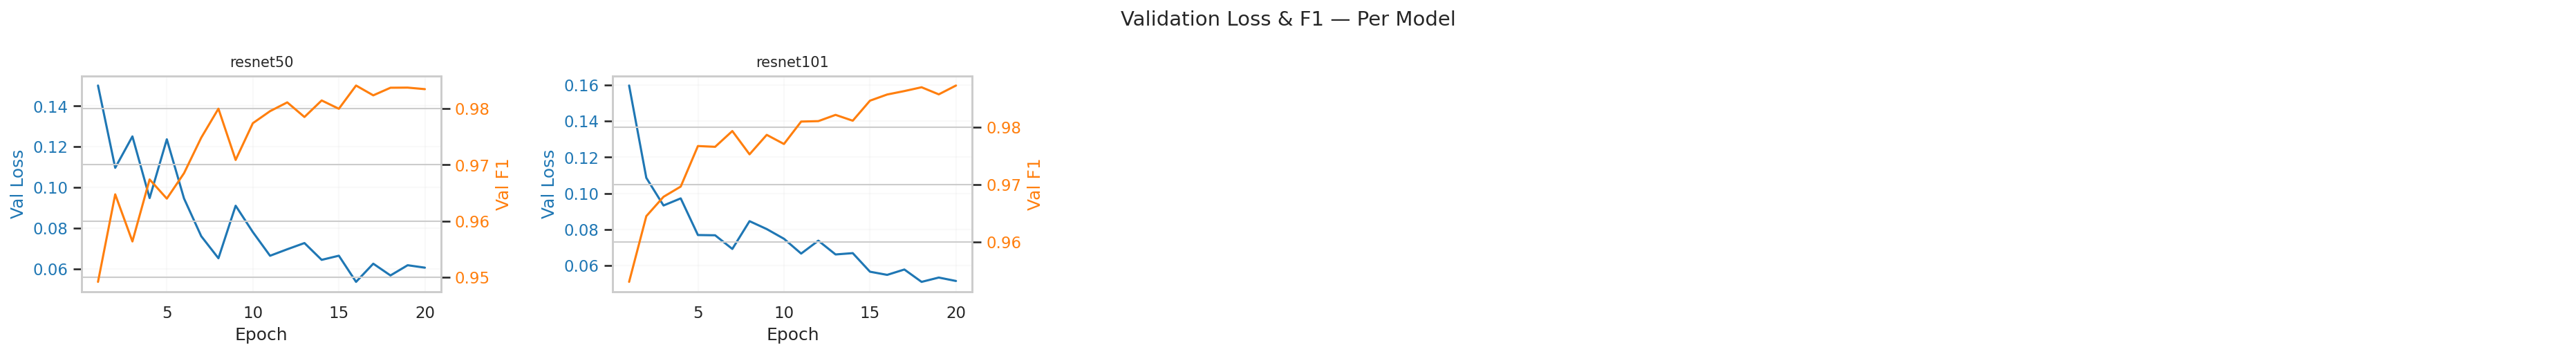

📈 Training curves saved: /kaggle/working/figures/fig2_training_curves.png

 FINAL TEST PERFORMANCE SUMMARY
 Dataset: pathmnist
    model  test_accuracy  test_f1  test_auc  test_ece
resnet101         0.9902   0.9902    0.9998    0.0047
 resnet50         0.9852   0.9854    0.9998    0.0066

--------------------------------------------------------------------------------
 BEST PERFORMANCE BY METRIC:
  → Accuracy: resnet101
  → F1:       resnet101
  → AUC:      resnet101
  → ECE:      resnet101
✓ Section 6 complete


In [8]:
# =====================================
# Section 6: Unified Baseline Model Evaluation
# → Evaluate all models on test set
# → Aggregate metrics, save confusion matrices, and plot training curves
# → Fully aligned with APTOS, MedMNIST, ISIC, Kvasir, BUSI
# =====================================
import gc
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# =====================================
# 1. Initialize Storage
# =====================================
all_histories = {}           # Training curves per model: val_loss, val_f1, etc.
baseline_results = []        # List of result dicts → becomes DataFrame
baseline_confusions = {}     # Raw confusion matrices

# Loss criterion (on device)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

# Ensure output directories exist
for d in [CONFIG['results_dir'], CONFIG['figures_dir'], CONFIG['checkpoint_dir']]:
    Path(d).mkdir(parents=True, exist_ok=True)

print(f"\n🚀 Starting baseline evaluation: {len(MODELS)} models | Dataset: {CONFIG.get('data_flag', 'Custom')}")
print("=" * 80)

# ───────────────────────────────────────────────────────────────────────
# Loop: Train & Evaluate Each Model
# ───────────────────────────────────────────────────────────────────────
for model_name in tqdm(MODELS, desc="Evaluating models"):
    print(f'\n{"🟩" * 60}')
    print(f"  MODEL: {model_name}")
    print(f'{"🟩" * 60}')
    
    try:
        # Train model (handles early stopping and saves best weights)
        model, history, best_val_metrics = train_model(
            model_name, train_loader, val_loader, class_weights, CONFIG
        )
        all_histories[model_name] = history
    except Exception as e:
        print(f"  ❌ Training failed for {model_name}: {e}")
        continue

    # Load best checkpoint (auto-detect dataset name)
    dataset_name = CONFIG.get('data_flag', 'generic').split('_')[0].lower()
    ckpt_path = Path(CONFIG['checkpoint_dir']) / f"best_{dataset_name}_{model_name}.pth"
    
    if not ckpt_path.exists():
        print(f"  ❌ Checkpoint not found: {ckpt_path}")
        del model
        torch.cuda.empty_cache()
        gc.collect()
        continue

    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.eval()
    print("  ✅ Best weights loaded. Running final test evaluation...")

    try:
        # Evaluate on test set
        test_metrics = evaluate(
            model, test_loader, criterion, device,
            CONFIG['num_classes'], CONFIG['class_names']
        )

        y_true = test_metrics['labels'].astype(int)
        y_pred = test_metrics['preds'].astype(int)
        ece = test_metrics['ece']

        # Confusion matrix
        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=list(range(CONFIG['num_classes']))
        )
        baseline_confusions[model_name] = cm

        # Per-class metrics
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true,
            y_pred,
            labels=list(range(CONFIG['num_classes'])),
            zero_division=0
        )

        per_class_metrics = {}
        for i, name in enumerate(CONFIG['class_names']):
            per_class_metrics[f'{name}_precision'] = float(precision[i])
            per_class_metrics[f'{name}_recall'] = float(recall[i])
            per_class_metrics[f'{name}_f1'] = float(f1[i])

        # Build model result entry
        baseline_results.append({
            'model': model_name,
            'val_acc': float(best_val_metrics['val_acc']),
            'val_f1': float(best_val_metrics['val_f1']),
            'val_auc': float(best_val_metrics['val_auc']),
            'val_ece': float(best_val_metrics['val_ece']),
            'test_accuracy': float(test_metrics['accuracy']),
            'test_f1': float(test_metrics['f1']),
            'test_auc': float(test_metrics['auc']),
            'test_ece': float(ece),
            **per_class_metrics
        })

        # Save visualized confusion matrix
        plot_confusion_matrix(
            cm=cm,
            class_names=CONFIG['class_names'],
            model_name=model_name,
            save=True,
            suffix='baseline'
        )

    except Exception as e:
        print(f"  ❌ Final evaluation failed for {model_name}: {e}")
        continue

    # Memory cleanup
    del model
    torch.cuda.empty_cache()
    gc.collect()

# ───────────────────────────────────────────────────────────────────────
# 2. Save Aggregated Results
# ───────────────────────────────────────────────────────────────────────
if len(baseline_results) == 0:
    print("❌ No models completed evaluation. Cannot proceed.")
else:
    baseline_df = pd.DataFrame(baseline_results)
    save_path = Path(CONFIG['results_dir']) / "baseline_results.csv"
    baseline_df.to_csv(save_path, index=False)
    print(f"\n✅ Aggregated baseline results saved: {save_path}")

    # ───────────────────────────────────────────────────────────────────────
    # 3. Plot Training Curves: Validation Loss & F1
    # Handles any number of models with flexible grid
    # ───────────────────────────────────────────────────────────────────────
    ncols = 5
    nrows = (len(baseline_results) + ncols - 1) // ncols  # ceiling division
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 3.5), dpi=150)

    # Flatten axes array
    if nrows == 1 and ncols == 1:
        axes_list = [axes]
    elif nrows == 1 or ncols == 1:
        axes_list = np.array(axes).flatten()
    else:
        axes_list = axes.flatten()

    # Turn off excess subplots
    for ax in axes_list[len(baseline_results):]:
        ax.axis('off')

    # Plot each model
    for idx, row in enumerate(baseline_results):
        model_name = row['model']
        ax = axes_list[idx]
        ax.axis('on')
        hist = all_histories.get(model_name, {})
        epochs = np.arange(1, len(hist.get('val_loss', [])) + 1)
        if len(epochs) == 0:
            continue

        # Left axis: Val Loss
        ax.plot(epochs, hist.get('val_loss', []), color='tab:blue', label='Val Loss')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Val Loss', color='tab:blue')
        ax.tick_params(axis='y', labelcolor='tab:blue')
        ax.grid(True, alpha=0.1)

        # Right axis: Val F1
        ax2 = ax.twinx()
        ax2.plot(epochs, hist.get('val_f1', []), color='tab:orange', label='Val F1')
        ax2.set_ylabel('Val F1', color='tab:orange')
        ax2.tick_params(axis='y', labelcolor='tab:orange')

        ax.set_title(model_name, fontsize=10)

    # Final layout
    plt.suptitle("Validation Loss & F1 — Per Model", fontsize=14, y=0.97)
    plt.tight_layout()
    curves_path = f"{CONFIG['figures_dir']}/fig2_training_curves.png"
    plt.savefig(curves_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"📈 Training curves saved: {curves_path}")

    # ───────────────────────────────────────────────────────────────────────
    # 4. Final Performance Summary Table
    # ───────────────────────────────────────────────────────────────────────
    print("\n" + "=" * 80)
    print(" FINAL TEST PERFORMANCE SUMMARY")
    print(f" Dataset: {CONFIG.get('data_flag', 'Custom')}")
    print("=" * 80)

    result_columns = ['model', 'test_accuracy', 'test_f1', 'test_auc', 'test_ece']
    print(
        baseline_df[result_columns]
        .round(4)
        .sort_values('test_f1', ascending=False)
        .to_string(index=False)
    )

    # ───────────────────────────────────────────────────────────────────────
    # 5. Best Model by Metric
    # ───────────────────────────────────────────────────────────────────────
    print("\n" + "-" * 80)
    try:
        best_acc = baseline_df.loc[baseline_df['test_accuracy'].idxmax(), 'model']
        best_f1 = baseline_df.loc[baseline_df['test_f1'].idxmax(), 'model']
        best_auc = baseline_df.loc[baseline_df['test_auc'].idxmax(), 'model']
        best_ece = baseline_df.loc[baseline_df['test_ece'].idxmin(), 'model']

        print(" BEST PERFORMANCE BY METRIC:")
        print(f"  → Accuracy: {best_acc}")
        print(f"  → F1:       {best_f1}")
        print(f"  → AUC:      {best_auc}")
        print(f"  → ECE:      {best_ece}")
    except Exception as e:
        print(f"  ⚠️ Could not compute best models: {e}")

print("✓ Section 6 complete")

In [9]:
# =====================================
# Section 7: Unified Failure Sample Extraction & Embedding Capture
# → Shared across APTOS, MedMNIST, ISIC, Kvasir, BUSI
# → Extracts embeddings and predictions on validation set
# → Identifies misclassified instances for downstream analysis
# =====================================
import gc
import pandas as pd
import torch
import numpy as np
from pathlib import Path
from tqdm import tqdm
import warnings

# =====================================
# extract_failures — Unified function
# =====================================
def extract_failures(model_name: str, loader, config):
    """
    Load a trained model, run inference, and extract:
      - true/pred labels, confidence, probability vectors, and embeddings.

    Returns:
        failures_df: DataFrame of misclassified samples
        all_preds_df: DataFrame of all samples (including correct)

    Note:
        Uses the best checkpoint from training (saved in CONFIG['checkpoint_dir']).
        Embedding is captured via hook from Section 4.
        Device is assumed to be defined globally (e.g., 'cuda').
    """
    print(f"  🔍 Loading model: {model_name} for failure extraction...", end='')

    model = get_model(model_name, config['num_classes'], pretrained=False)
    
    # Auto-detect dataset name for checkpoint
    dataset_name = config.get('data_flag', 'generic').split('_')[0].lower()
    ckpt_path = Path(config['checkpoint_dir']) / f"best_{dataset_name}_{model_name}.pth"
    
    if not ckpt_path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")

    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.eval()
    
    # Attach embedding hook
    hook_handle, embedding_store = get_embedding_hook(model, model_name)
    
    rows = []
    with torch.no_grad():
        for batch_idx, (images, labels, paths) in enumerate(tqdm(
            loader,
            desc=f"inferring {model_name}",
            leave=False,
            disable=not config.get('show_batch_progress', False)
        )):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            # Forward pass: get logits and probs
            logits = model(images)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds = probs.argmax(axis=1)
            confs = probs.max(axis=1)

            # Retrieve embeddings (handled by hook)
            try:
                emb = embedding_store['embedding'].numpy()  # Shape: (B, D)
                if emb.shape[0] != len(paths):
                    warnings.warn(f"Embedding batch size mismatch: {emb.shape[0]} vs {len(paths)}")
            except KeyError:
                emb = np.zeros((images.size(0), 512))  # fallback
                print(f"  ⚠️ No embedding captured for {model_name}, batch {batch_idx}")

            # Collect per-sample records
            for i in range(len(paths)):
                rows.append({
                    'image_path': str(paths[i]),
                    'true_label': int(labels[i].cpu().item()),
                    'pred_label': int(preds[i]),
                    'confidence': float(confs[i]),
                    'prob_vector': ','.join([f'{p:.8f}' for p in probs[i]]),
                    'embedding': ','.join([f'{x:.8f}' for x in emb[i].ravel()]),
                })

    # Clean up
    hook_handle.remove()
    del model
    torch.cuda.empty_cache()
    gc.collect()

    # Convert to DataFrame
    all_preds_df = pd.DataFrame(rows)
    failures_df = all_preds_df[
        all_preds_df['true_label'] != all_preds_df['pred_label']
    ].reset_index(drop=True)

    print(f" ✅ {len(failures_df)} failures identified ({100 * len(failures_df) / len(all_preds_df):.1f}%)")

    return failures_df, all_preds_df


# =====================================
# Initialize storage
# =====================================
all_failures = {}
all_predictions = {}

# Ensure output directory exists
Path(CONFIG['results_dir']).mkdir(parents=True, exist_ok=True)

print(f"\n🚀 Extracting failure samples — Using VAL set (no test leakage)")
print(f"  Dataset: {CONFIG.get('data_flag', 'Unknown')}")
print(f"  Models: {len(MODELS)} | Checkpoint dir: {CONFIG['checkpoint_dir']}")
print("=" * 80)

# ─────────────────────────────────────────────────────────────────────
# Loop: Extract failures for each model
# ─────────────────────────────────────────────────────────────────────
for model_name in tqdm(MODELS, desc="Processing models"):

    try:
        failures_df, all_preds_df = extract_failures(model_name, val_loader, CONFIG)

        # Store in global containers
        all_failures[model_name] = failures_df
        all_predictions[model_name] = all_preds_df

        # Save to disk
        dataset_name = CONFIG.get('data_flag', 'generic').split('_')[0].lower()
        
        failures_csv = f"{CONFIG['results_dir']}/failures_{dataset_name}_{model_name}.csv"
        preds_csv = f"{CONFIG['results_dir']}/predictions_{dataset_name}_{model_name}.csv"

        failures_df.to_csv(failures_csv, index=False)
        all_preds_df.to_csv(preds_csv, index=False)

    except Exception as e:
        print(f" ❌ Failed to process {model_name}: {e}")
        all_failures[model_name] = pd.DataFrame()
        all_predictions[model_name] = pd.DataFrame()

print("✓ Section 7 complete")



🚀 Extracting failure samples — Using VAL set (no test leakage)
  Dataset: pathmnist
  Models: 2 | Checkpoint dir: /kaggle/working/checkpoints


Processing models:   0%|          | 0/2 [00:00<?, ?it/s]

  🔍 Loading model: resnet50 for failure extraction...resnet50: 23.53M params (23.53M trainable)
 ✅ 144 failures identified (1.6%)


Processing models:  50%|█████     | 1/2 [00:39<00:39, 39.96s/it]

  🔍 Loading model: resnet101 for failure extraction...resnet101: 42.52M params (42.52M trainable)
 ✅ 112 failures identified (1.2%)


Processing models: 100%|██████████| 2/2 [01:39<00:00, 49.75s/it]

✓ Section 7 complete



🔍 Running failure clustering for 2 models — pathmnist Dataset


Clustering Models:   0%|          | 0/2 [00:00<?, ?it/s]


🌀 [resnet50] Clustering 144 failure samples
  ✅ Parsed: 144 × 2048d | 0.04s
  📉 PCA-32d → 0.762 var | 0.31s
  🗺️  PCA-2D-2D computed | 0.00s
  🔍 KMeans sweep over K=[2, 3, 4, 5, 6] | 0.20s
  ✅ Final clustering (K=6) | 0.02s
  🧪 Stability (ARI): [0.745323218373911, 0.745323218373911, 0.5037921472572248] → mean=0.665


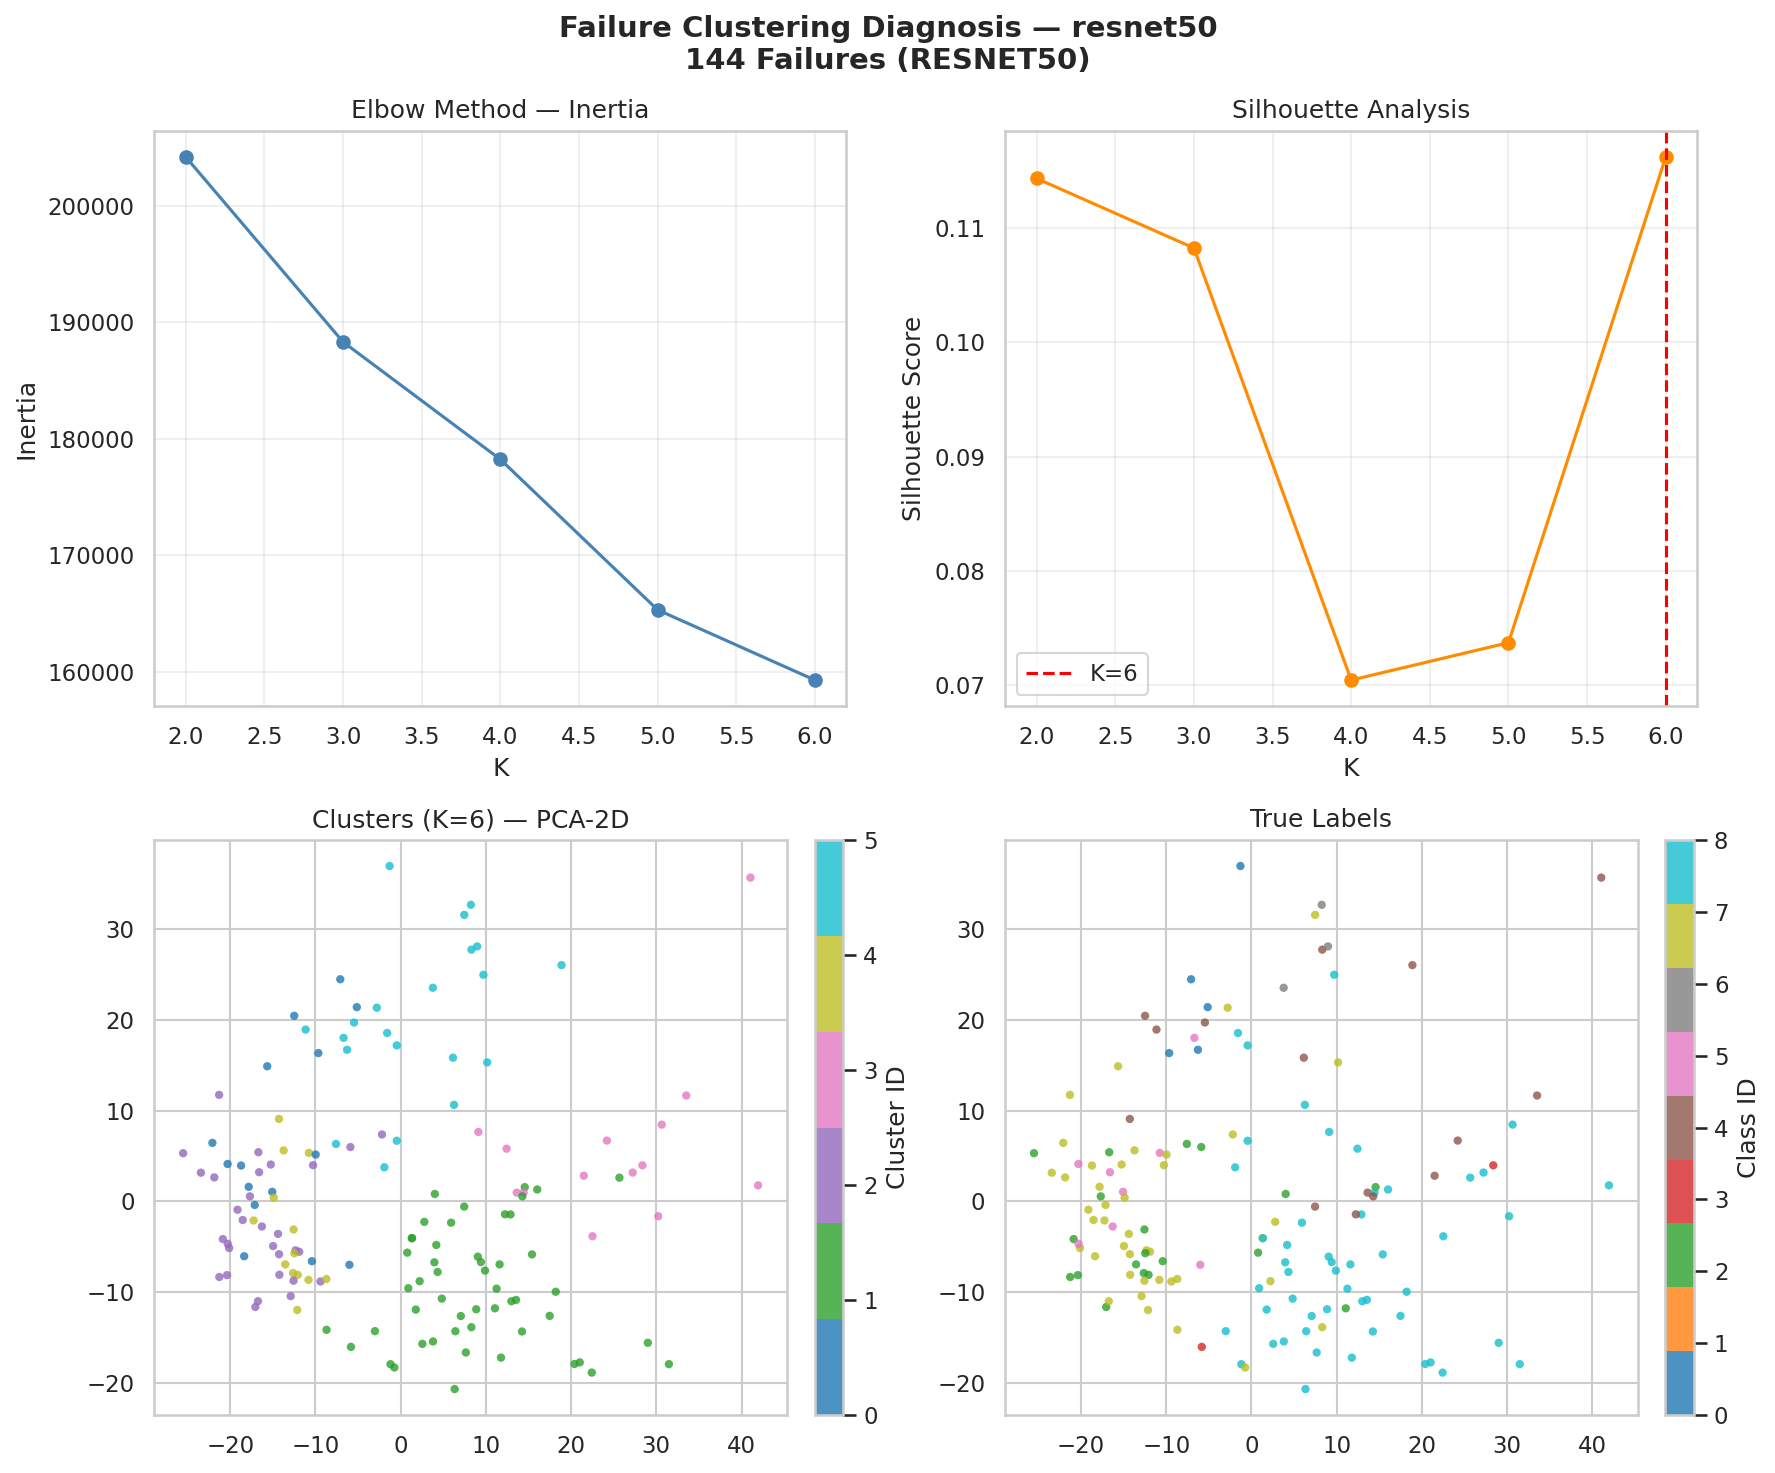

Clustering Models:  50%|█████     | 1/2 [00:02<00:02,  2.54s/it]

  📤 Diagnostic plot saved: /kaggle/working/figures/clustering_pathmnist_resnet50.png
  ⏱️  TOTAL clustering time: 2.46s
  ✅ Clusters exported: K=6, Saved → /kaggle/working/results/clustered_failures_pathmnist_resnet50.csv

🌀 [resnet101] Clustering 112 failure samples
  ✅ Parsed: 112 × 2048d | 0.03s
  📉 PCA-32d → 0.792 var | 0.04s
  🗺️  PCA-2D-2D computed | 0.00s
  🔍 KMeans sweep over K=[2, 3, 4, 5, 6] | 0.11s
  ✅ Final clustering (K=2) | 0.02s
  🧪 Stability (ARI): [1.0, 1.0, -0.042579949288925716] → mean=0.652


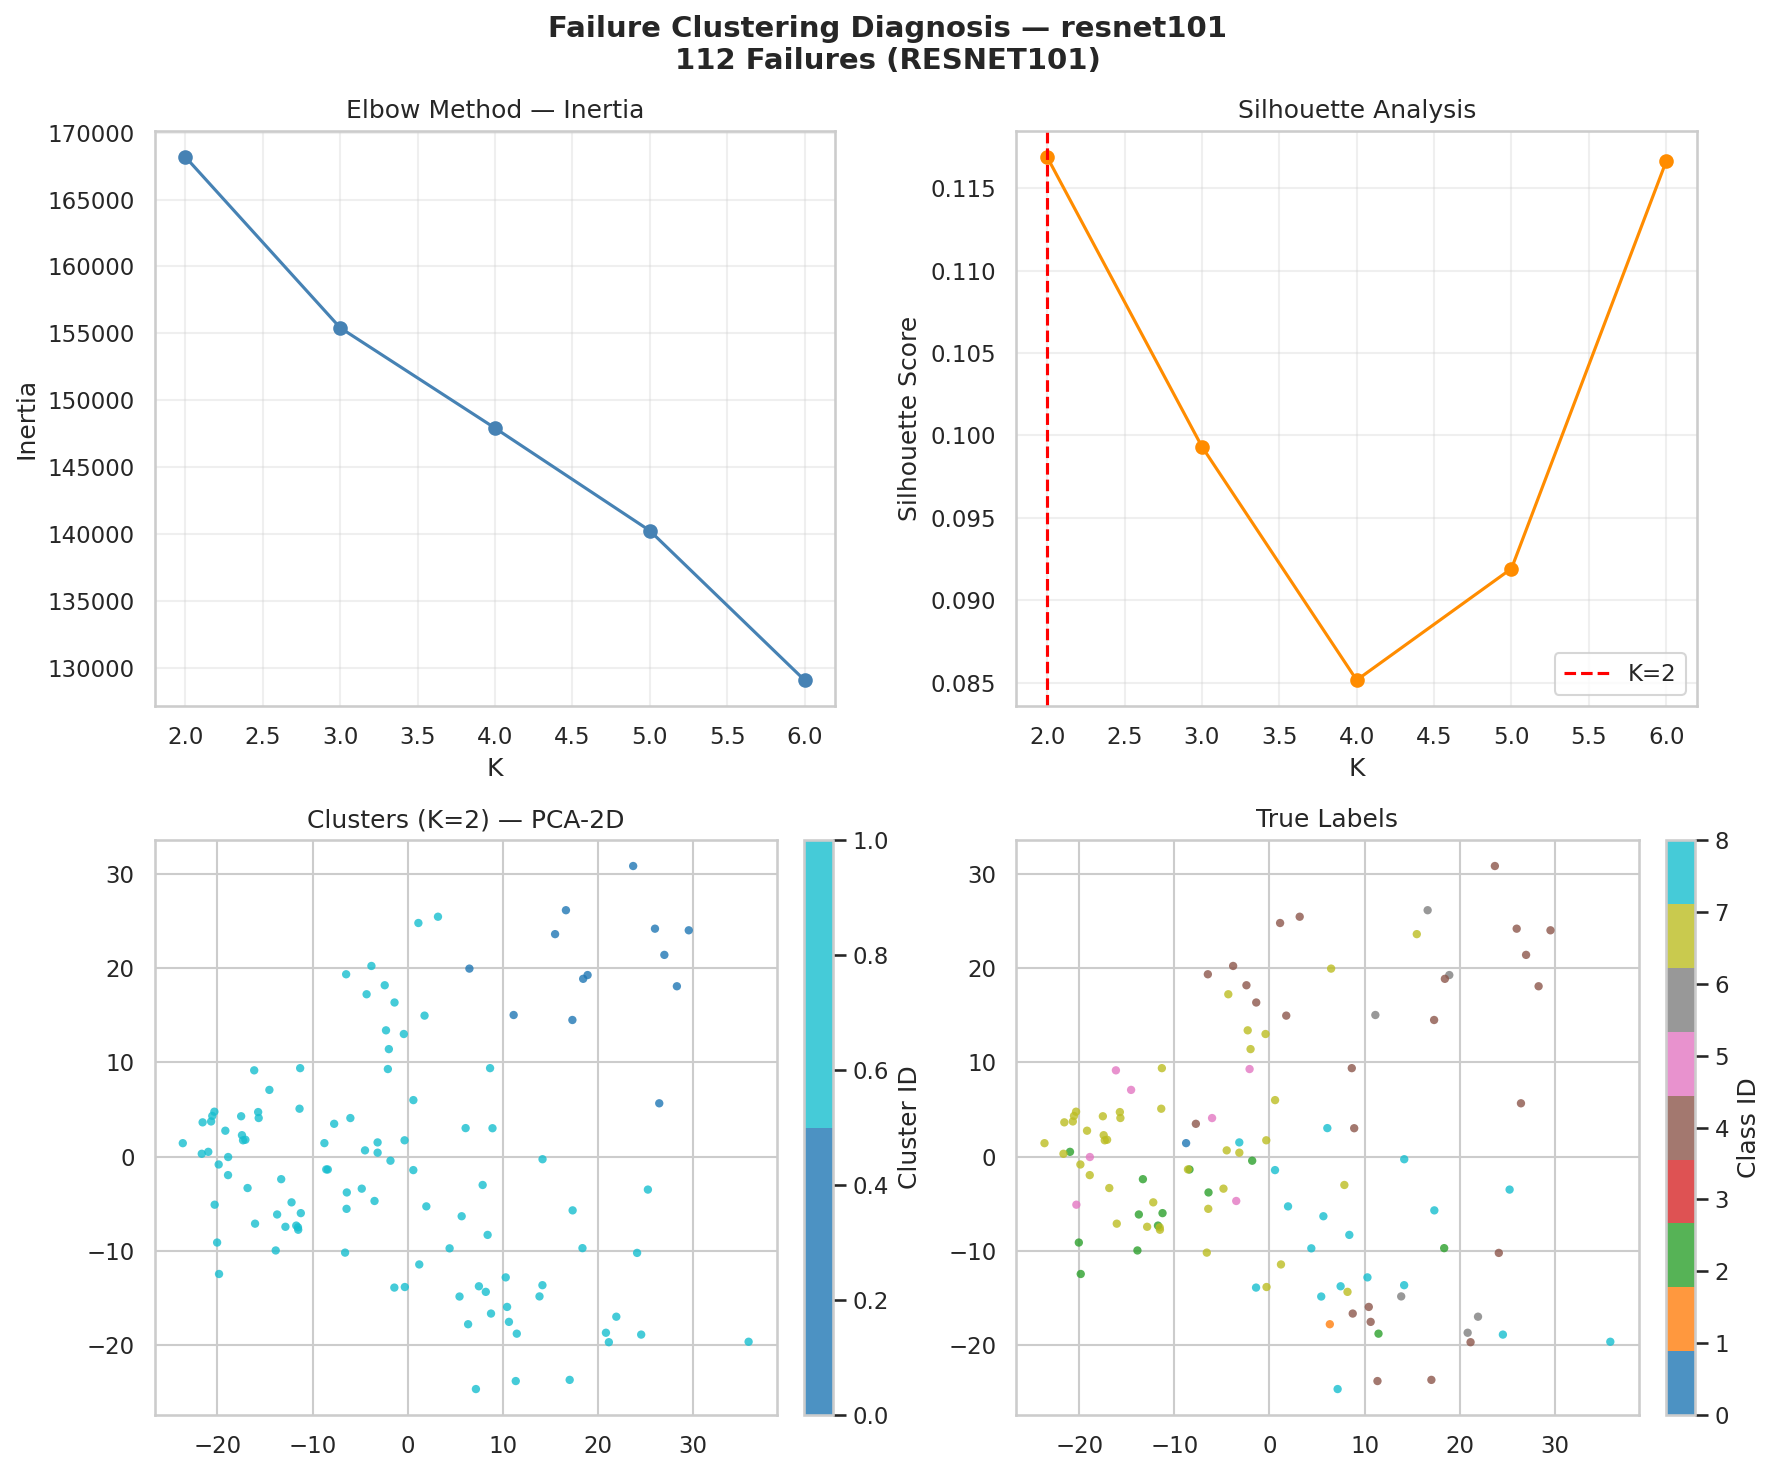

Clustering Models: 100%|██████████| 2/2 [00:04<00:00,  2.33s/it]

  📤 Diagnostic plot saved: /kaggle/working/figures/clustering_pathmnist_resnet101.png
  ⏱️  TOTAL clustering time: 2.06s
  ✅ Clusters exported: K=2, Saved → /kaggle/working/results/clustered_failures_pathmnist_resnet101.csv

✅ Section 8 complete
  Results saved to: /kaggle/working/results
  Plots saved to:   /kaggle/working/figures


In [10]:
# =====================================
# Section 8: Unified Failure Clustering
# → Shared across APTOS, MedMNIST, ISIC, Kvasir, BUSI
# → Uses PCA + MiniBatchKMeans + optional UMAP
# → Optimizes K via silhouette, evaluates stability via ARI
# → Designed for speed & compatibility (Kaggle T4 GPU safe)
# =====================================
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
import umap as umap_lib
from tqdm import tqdm
import gc

# Ensure required global variables
assert 'CONFIG' in globals(), "CONFIG must be defined (with seed, figures_dir, etc.)"
assert 'all_failures' in globals(), "all_failures dict must be populated with misclassified samples"
assert 'MODELS' in globals(), "MODELS list must be defined"


def cluster_failures(failures_df, config, model_name):
    """
    Cluster misclassified samples in 2D embedding space.

    Steps:
      1. Parse embeddings
      2. Apply PCA
      3. Optional UMAP projection
      4. MiniBatchKMeans sweep over K
      5. Silhouette optimization
      6. Stability evaluation via ARI
      7. Visual diagnosis: 2x2 plot

    Returns:
        clustered_df (DataFrame): with cluster, umap_x, umap_y, mean_ari
        best_k: optimal number of clusters
        best_sil: highest silhouette score
        mean_ari: average Adjusted Rand Index (stability)
        best_k_bic: same as best_k (alignment with other pipelines)
    """
    t0 = time.time()

    # ─── Guard: Not enough samples ─────────────────────────────────────
    if len(failures_df) < 3:
        print(f"  🛑 Skipping {model_name}: not enough failures ({len(failures_df)}<3)")
        out = failures_df.copy()
        out['cluster'] = 0
        out['umap_x'] = 0.0
        out['umap_y'] = 0.0
        out['mean_ari'] = np.nan
        return out, 1, np.nan, np.nan, 1  # dummy values

    print(f"\n🌀 [{model_name}] Clustering {len(failures_df)} failure samples")
    
    # ─── 1. Parse Embeddings ───────────────────────────────────────────
    raw = failures_df['embedding'].tolist()
    if isinstance(raw[0], str):
        embeddings = np.array([
            np.fromstring(e, sep=',', dtype=np.float32) for e in raw
        ], dtype=np.float32)
    else:
        embeddings = np.array(raw, dtype=np.float32)
    print(f"  ✅ Parsed: {len(failures_df)} × {embeddings.shape[1]}d | {time.time()-t0:.2f}s")

    # ─── 2. Standardize & PCA ─────────────────────────────────────────
    t1 = time.time()
    E_scaled = StandardScaler().fit_transform(embeddings)
    
    n_pca = min(
        config.get('pca_components', 32),
        len(failures_df) - 1,
        E_scaled.shape[1]
    )
    pca = PCA(n_components=n_pca, random_state=config['seed'], svd_solver='randomized')
    E_pca = pca.fit_transform(E_scaled).astype(np.float32)
    var_ratio = pca.explained_variance_ratio_.sum()
    print(f"  📉 PCA-{n_pca}d → {var_ratio:.3f} var | {time.time()-t1:.2f}s")

    # ─── 3. UMAP or PCA-2D for Projection ─────────────────────────────
    t2 = time.time()
    UMAP_THRESHOLD = config.get('small_failure_umap_threshold', 300)
    input_for_umap = E_pca[:, :16] if E_pca.shape[1] >= 16 else E_pca

    if len(failures_df) < UMAP_THRESHOLD:
        E_2d = E_pca[:, :2]
        proj_method = 'PCA-2D'
    else:
        reducer = umap_lib.UMAP(
            n_neighbors = min(10, max(2, len(failures_df) - 1)),
            min_dist    = config.get('umap_min_dist', 0.1),
            n_components = 2,
            random_state = config['seed'],
            n_epochs     = 50,
            metric       = 'euclidean',
            low_memory   = True,
            n_jobs       = 1,
        )
        E_2d = reducer.fit_transform(input_for_umap).astype(np.float32)
        proj_method = 'UMAP'
    print(f"  🗺️  {proj_method}-2D computed | {time.time()-t2:.2f}s")

    # ─── 4. KMeans Sweep: Best K via Silhouette ───────────────────────
    t3 = time.time()
    k_range = list(config.get('k_range', range(2, 7)))
    k_range = [k for k in k_range if 2 <= k <= min(6, len(failures_df) - 1)]
    if not k_range:
        k_range = [2]

    inertias, silhouettes = [], []

    # Subsample for silhouette efficiency
    MAX_SIL_SAMPLES = 500
    if len(E_pca) > MAX_SIL_SAMPLES:
        sil_idx = np.random.RandomState(config['seed']).choice(
            len(E_pca), size=MAX_SIL_SAMPLES, replace=False
        )
    else:
        sil_idx = np.arange(len(E_pca))
    E_sil = E_pca[sil_idx]

    for k in k_range:
        km = MiniBatchKMeans(
            n_clusters=k,
            random_state=config['seed'],
            n_init=3,
            batch_size=min(256, len(failures_df)),
            max_iter=100
        )
        labels = km.fit_predict(E_pca)
        inertias.append(km.inertia_)

        unique_labels = np.unique(labels[sil_idx])
        if len(unique_labels) > 1:
            s = silhouette_score(E_sil, labels[sil_idx], sample_size=None)
        else:
            s = np.nan
        silhouettes.append(s)

    print(f"  🔍 KMeans sweep over K={k_range} | {time.time()-t3:.2f}s")

    # ─── 5. Select Best K ──────────────────────────────────────────────
    if silhouettes and not np.all(np.isnan(silhouettes)):
        best_idx = np.nanargmax(silhouettes)
        best_k = k_range[best_idx]
        best_sil = silhouettes[best_idx]
    else:
        best_k, best_sil = 2, np.nan

    # ─── 6. Final Clustering ───────────────────────────────────────────
    t4 = time.time()
    final_km = MiniBatchKMeans(
        n_clusters=best_k,
        random_state=config['seed'],
        n_init=5,
        batch_size=min(512, len(failures_df))
    )
    cluster_labels = final_km.fit_predict(E_pca)
    print(f"  ✅ Final clustering (K={best_k}) | {time.time()-t4:.2f}s")

    # ─── 7. Clustering Stability (ARI across seeds) ──────────────────
    ari_scores = []
    seeds = [config['seed'], 42, 100]
    for seed in seeds:
        test_km = MiniBatchKMeans(
            n_clusters=best_k,
            random_state=seed,
            n_init=3,
            batch_size=min(256, len(failures_df))
        )
        labs = test_km.fit_predict(E_pca)
        ari = adjusted_rand_score(cluster_labels, labs)
        ari_scores.append(ari)
    mean_ari = float(np.mean(ari_scores))
    print(f"  🧪 Stability (ARI): {ari_scores} → mean={mean_ari:.3f}")

    # ─── 8. Build Output DataFrame ───────────────────────────────────
    clustered_df = failures_df.copy().reset_index(drop=True)
    clustered_df['cluster'] = cluster_labels
    clustered_df['umap_x'] = E_2d[:, 0]
    clustered_df['umap_y'] = E_2d[:, 1]
    clustered_df['mean_ari'] = mean_ari

    # ─── 9. Plot: 2×2 Diagnosis Grid ─────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(12, 10), dpi=150)
    cmap_cluster = cm.get_cmap('tab10', best_k)
    cmap_label = cm.get_cmap('tab10', config['num_classes'])

    # Elbow: Inertia vs K
    axes[0, 0].plot(k_range, inertias, marker='o', color='steelblue')
    axes[0, 0].set_xlabel('K'); axes[0, 0].set_ylabel('Inertia')
    axes[0, 0].set_title('Elbow Method — Inertia')
    axes[0, 0].grid(True, alpha=0.3)

    # Silhouette Score vs K
    axes[0, 1].plot(k_range, silhouettes, marker='o', color='darkorange')
    if best_sil == best_sil:
        axes[0, 1].axvline(best_k, color='red', linestyle='--', label=f'K={best_k}')
        axes[0, 1].legend()
    axes[0, 1].set_xlabel('K'); axes[0, 1].set_ylabel('Silhouette Score')
    axes[0, 1].set_title('Silhouette Analysis')
    axes[0, 1].grid(True, alpha=0.3)

    # Cluster Assignment (UMAP)
    sc1 = axes[1, 0].scatter(
        clustered_df['umap_x'], clustered_df['umap_y'],
        c=clustered_df['cluster'], cmap=cmap_cluster, s=16, alpha=0.8, edgecolors='none'
    )
    axes[1, 0].set_title(f'Clusters (K={best_k}) — {proj_method}')
    plt.colorbar(sc1, ax=axes[1, 0], fraction=0.046, pad=0.04, label='Cluster ID')

    # True Labels (Colorized)
    sc2 = axes[1, 1].scatter(
        clustered_df['umap_x'], clustered_df['umap_y'],
        c=clustered_df['true_label'], cmap=cmap_label, s=16, alpha=0.8, edgecolors='none'
    )
    axes[1, 1].set_title('True Labels')
    plt.colorbar(sc2, ax=axes[1, 1], fraction=0.046, pad=0.04, label='Class ID')

    # Finalize
    plt.suptitle(f"Failure Clustering Diagnosis — {model_name}\n{len(failures_df)} Failures ({model_name.split('_')[0].upper()})", fontsize=14, weight='bold')
    plt.tight_layout()

    # Save high-res plot (300 DPI, high quality)
    dataset_name = config.get('data_flag', 'generic').split('_')[0].lower()
    save_path = Path(config['figures_dir']) / f"clustering_{dataset_name}_{model_name}.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"  📤 Diagnostic plot saved: {save_path}")

    print(f"  ⏱️  TOTAL clustering time: {time.time()-t0:.2f}s")
    
    return clustered_df, best_k, best_sil, mean_ari, best_k  # best_k_bic placeholder


# ─────────────────────────────────────────────────────────────────────
# Run Clustering for All Models
# ─────────────────────────────────────────────────────────────────────
all_clustered = {}          # clustered_df for each model
cluster_summaries = {}      # {model: {best_k, silhouette, mean_ari, best_k_bic}}

# Create output directories
Path(CONFIG['results_dir']).mkdir(parents=True, exist_ok=True)
Path(CONFIG['figures_dir']).mkdir(parents=True, exist_ok=True)

print(f"\n🔍 Running failure clustering for {len(MODELS)} models — {CONFIG.get('data_flag', 'Unknown')} Dataset")
print("=" * 80)

for model_name in tqdm(MODELS, desc="Clustering Models"):
    if model_name not in all_failures or len(all_failures[model_name]) == 0:
        print(f"  ❌ No failed predictions for {model_name}")
        continue

    try:
        clustered_df, best_k, best_sil, mean_ari, best_k_bic = cluster_failures(
            all_failures[model_name], CONFIG, model_name
        )

        # Store
        all_clustered[model_name] = clustered_df
        cluster_summaries[model_name] = {
            'best_k': int(best_k),
            'silhouette': float(best_sil) if not np.isnan(best_sil) else None,
            'mean_ari': float(mean_ari) if not np.isnan(mean_ari) else None,
            'best_k_bic': int(best_k_bic)
        }

        # Save to results directory
        dataset_name = CONFIG.get('data_flag', 'generic').split('_')[0].lower()
        export_path = Path(CONFIG['results_dir']) / f"clustered_failures_{dataset_name}_{model_name}.csv"
        clustered_df.to_csv(export_path, index=False)
        print(f"  ✅ Clusters exported: K={best_k}, Saved → {export_path}")

    except Exception as e:
        print(f"  ❌ Failure clustering failed for {model_name}: {type(e).__name__}: {e}")

print(f"\n✅ Section 8 complete")
print(f"  Results saved to: {CONFIG['results_dir']}")
print(f"  Plots saved to:   {CONFIG['figures_dir']}")


Profiling clusters: resnet50
 cluster  n_samples                                        dominant_confusion  mean_confidence  per_cluster_ece
       0         15                   cancer-associated stroma->smooth muscle         0.758000         0.758000
       1         51 colorectal adenocarcinoma epithelium->normal colon mucosa         0.766617         0.766617
       2         30                   cancer-associated stroma->smooth muscle         0.797235         0.797235
       3         14 colorectal adenocarcinoma epithelium->normal colon mucosa         0.841126         0.841126
       4         13                          debris->cancer-associated stroma         0.861434         0.861434
       5         21                                mucus->normal colon mucosa         0.775683         0.775683


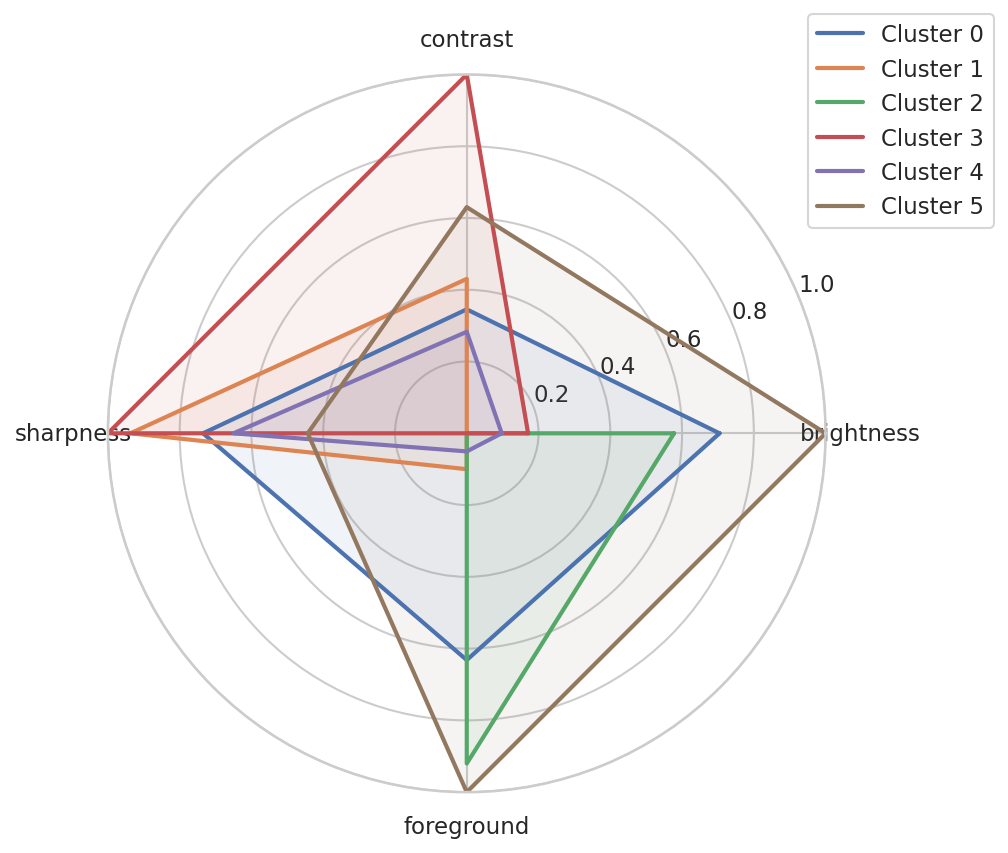


Profiling clusters: resnet101
 cluster  n_samples                      dominant_confusion  mean_confidence  per_cluster_ece
       0         13              mucus->normal colon mucosa         0.849338         0.849338
       1         99 cancer-associated stroma->smooth muscle         0.841185         0.841185


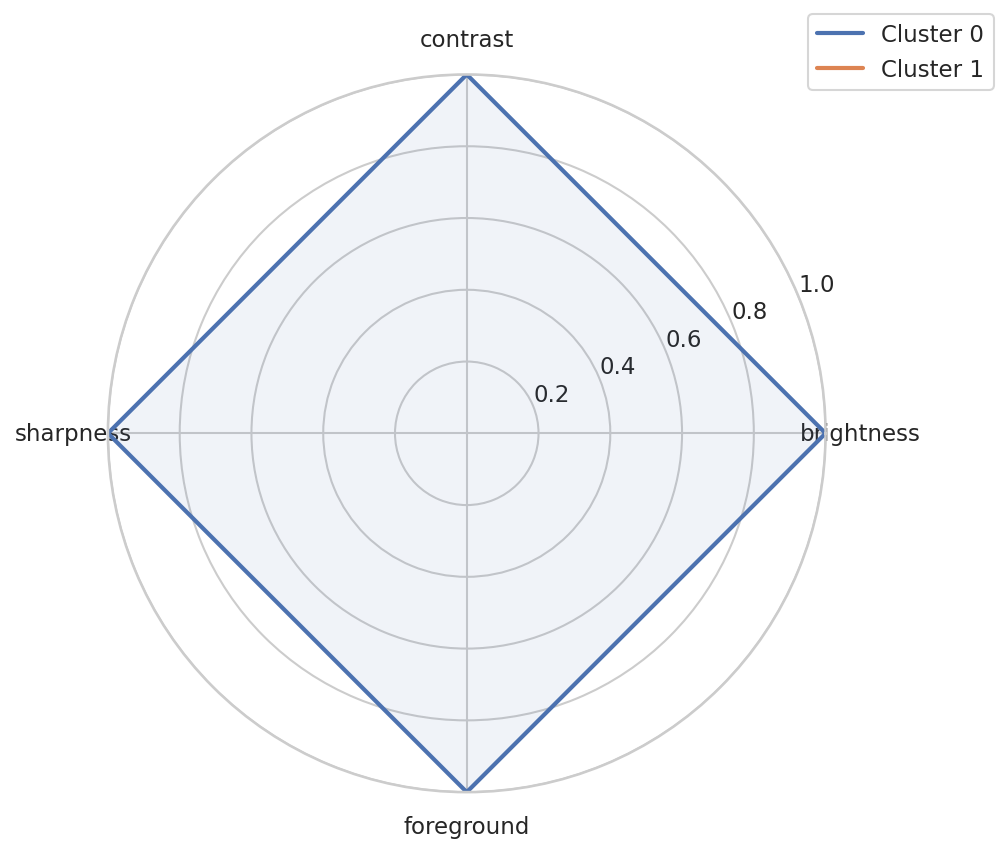

Cached image features: 191 unique images
✓ Section 9 complete


In [11]:
IMAGE_FEATURE_CACHE = {}


def compute_image_features(image_path, image_dir=None):
    """Compute cached brightness, contrast, sharpness, and foreground proxy from an image."""
    if image_path in IMAGE_FEATURE_CACHE:
        return IMAGE_FEATURE_CACHE[image_path]

    try:
        img = Image.open(image_path).convert('L').resize((224, 224))
        arr = np.asarray(img, dtype=np.float32)
    except Exception:
        features = {
            'brightness': np.nan,
            'contrast': np.nan,
            'sharpness': np.nan,
            'foreground_size': np.nan
        }
        IMAGE_FEATURE_CACHE[image_path] = features
        return features

    brightness = float(arr.mean() / 255.0)
    contrast = float(arr.std() / 255.0)

    if ndimage is not None:
        sharpness = float(np.var(ndimage.laplace(arr)))
    else:
        gy, gx = np.gradient(arr)
        sharpness = float(np.var(gx) + np.var(gy))

    # Faster foreground proxy than Otsu.
    if arr.std() > 0:
        thresh = arr.mean()
        foreground_size = float((arr > thresh).mean())
    else:
        foreground_size = 0.0

    features = {
        'brightness': brightness,
        'contrast': contrast,
        'sharpness': sharpness,
        'foreground_size': foreground_size
    }

    IMAGE_FEATURE_CACHE[image_path] = features
    return features


def profile_clusters(clustered_df, model_name, config):
    """Summarize image characteristics and calibration for each failure cluster."""
    rows = []

    if len(clustered_df) == 0:
        return pd.DataFrame()

    class_map = dict(enumerate(config['class_names']))

    for cluster_id, group in tqdm(
        clustered_df.groupby('cluster'),
        desc=f'profile {model_name}',
        leave=False,
        disable=not config.get('show_batch_progress', False)
    ):
        probs = np.stack(
            group['prob_vector'].apply(lambda x: np.fromstring(x, sep=','))
        )
        labels_arr = group['true_label'].values

        pairs = list(zip(group['true_label'], group['pred_label']))
        dominant_pair = Counter(pairs).most_common(1)[0][0]

        feature_rows = [
            compute_image_features(p, config.get('image_dir'))
            for p in group['image_path']
        ]
        features = pd.DataFrame(feature_rows)

        row = {
            'cluster': int(cluster_id),
            'n_samples': int(len(group)),
            'true_class_distribution': dict(Counter(group['true_label'].map(class_map))),
            'pred_class_distribution': dict(Counter(group['pred_label'].map(class_map))),
            'dominant_confusion': (
                f"{config['class_names'][dominant_pair[0]]}"
                f"->{config['class_names'][dominant_pair[1]]}"
            ),
            'mean_confidence': float(group['confidence'].mean()),
            'std_confidence': float(group['confidence'].std(ddof=0)),
            'per_cluster_ece': compute_ece(
                probs,
                labels_arr,
                config.get('ece_bins', 15)
            ),
        }

        for feat in ['brightness', 'contrast', 'sharpness', 'foreground_size']:
            row[f'{feat}_mean'] = float(features[feat].mean())
            row[f'{feat}_std'] = float(features[feat].std(ddof=0))

        rows.append(row)

    profile_df = pd.DataFrame(rows)

    print(
        profile_df[
            ['cluster', 'n_samples', 'dominant_confusion',
             'mean_confidence', 'per_cluster_ece']
        ].to_string(index=False)
    )

    feats = [
        'brightness_mean',
        'contrast_mean',
        'sharpness_mean',
        'foreground_size_mean'
    ]

    radar = profile_df[['cluster'] + feats].copy()

    for feat in feats:
        mn, mx = radar[feat].min(), radar[feat].max()
        if pd.isna(mn) or pd.isna(mx) or mx == mn:
            radar[feat] = 0.5
        else:
            radar[feat] = (radar[feat] - mn) / (mx - mn)

    labels = ['brightness', 'contrast', 'sharpness', 'foreground']
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]

    fig = plt.figure(figsize=(7, 7), dpi=150)
    ax = fig.add_subplot(111, polar=True)

    for _, row in radar.iterrows():
        values = [row[f] for f in feats]
        values += values[:1]

        ax.plot(
            angles,
            values,
            linewidth=2,
            label=f"Cluster {int(row['cluster'])}"
        )
        ax.fill(angles, values, alpha=0.08)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 1)
    ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1))

    plt.tight_layout()
    plt.savefig(
        f"{config['figures_dir']}/radar_{model_name}.png",
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()

    return profile_df


all_profiles = {}

for model_name in MODELS:
    print(f'\nProfiling clusters: {model_name}')

    profile_df = profile_clusters(
        all_clustered[model_name],
        model_name,
        CONFIG
    )

    all_profiles[model_name] = profile_df

    profile_df.to_csv(
        f'{CONFIG["results_dir"]}/profile_medmnist_{model_name}.csv',
        index=False
    )

print(f"Cached image features: {len(IMAGE_FEATURE_CACHE)} unique images")
print("✓ Section 9 complete")


In [12]:
# =====================================
# Section 10: Unified Failure-Aware Retraining + Degradation Guard
# → Enhance training data using cluster insights
# → Retrain with warm start and mixed precision
# → Guard: revert to baseline if degradation occurs
# → Shared across APTOS, MedMNIST, ISIC, Kvasir, BUSI, etc.
# =====================================
import gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from collections import defaultdict
from pathlib import Path
from tqdm import tqdm
from sklearn.metrics import confusion_matrix


# ─────────────────────────────────────────────────────────────────────
# 1. Build Failure-Aware Training Set
# ─────────────────────────────────────────────────────────────────────
def build_failure_aware_dataset(train_df, clustered_df, profile_df, config, strategy='both'):
    """
    Enhance the training set based on failure cluster analysis.

    Strategies:
      - 'selective':   Augment samples from high-failure clusters (good for CNNs)
      - 'weighted':   Upweight failure-prone samples or classes (for transformers)
      - 'both':       Apply both

    Returns: enhanced DataFrame with 'is_augmented' and 'sample_weight'.
    """
    out = train_df.copy()
    out['is_augmented'] = False
    out['sample_weight'] = 1.0

    if (clustered_df is None or len(clustered_df) == 0 or
        profile_df is None or len(profile_df) == 0):
        return out

    # Compute cluster frequency-based scaling
    cluster_counts = clustered_df['cluster'].value_counts().to_dict()
    mean_count = np.mean(list(cluster_counts.values())) if cluster_counts else 1.0
    cluster_alpha = {k: max(1.0, v / (mean_count or 1e-8)) for k, v in cluster_counts.items()}

    # Mappings
    path_to_cluster = dict(zip(clustered_df['image_path'], clustered_df['cluster']))
    cluster_to_true_labels = (
        clustered_df
        .groupby('cluster')['true_label']
        .apply(lambda s: set(s.tolist()))
        .to_dict()
    )

    path_overlap = out['image_path'].isin(clustered_df['image_path']).sum()

    # ── 1. Selective Augmentation (CNNs) ───────────────────────────────────
    if strategy in ['selective', 'both']:
        high_clusters = [k for k, v in cluster_counts.items() if v > mean_count]
        if not high_clusters:
            high_clusters = list(cluster_counts.keys())

        high_paths = set(clustered_df[clustered_df['cluster'].isin(high_clusters)]['image_path'])
        source = out[out['image_path'].isin(high_paths)].copy()

        # Fall back to label-level if no path overlap
        if len(source) == 0:
            high_labels = set()
            for cluster_id in high_clusters:
                high_labels.update(cluster_to_true_labels.get(cluster_id, set()))
            source = out[out['label'].isin(high_labels)].copy()
            print(f"  ⚠️ No path overlap; using high-error labels: {sorted(high_labels)}")

        max_aug_source = config.get('max_aug_source', 300)
        if len(source) > max_aug_source:
            if source['label'].nunique() > 1:
                source, _ = train_test_split(
                    source,
                    train_size=max_aug_source,
                    random_state=config['seed'],
                    stratify=source['label']
                )
            else:
                source = source.sample(n=max_aug_source, random_state=config['seed'])
            source = source.reset_index(drop=True)
            print(f"  🔧 Augmentation source limited to {max_aug_source} samples")

        # Add augmented copies
        augmented_dfs = []
        multiplier = config.get('aug_multiplier', 3)
        for _ in range(multiplier):
            aug = source.copy()
            aug['is_augmented'] = True
            augmented_dfs.append(aug)

        out = pd.concat([out] + augmented_dfs, ignore_index=True).reset_index(drop=True)
        print(
            f"  ✅ Selective aug: {len(source)} source × {multiplier} → "
            f"{len(augmented_dfs) * len(source)} added"
        )

    # ── 2. Weighted Sampling (Transformers, EfficientNet) ──────────────────
    if strategy in ['weighted', 'both']:
        if path_overlap > 0:
            out['sample_weight'] = out['image_path'].map(
                lambda p: cluster_alpha.get(path_to_cluster.get(p), 1.0)
            )
        else:
            # Class-level weights
            label_weights = defaultdict(lambda: 1.0)
            for cluster_id, alpha in cluster_alpha.items():
                for label in cluster_to_true_labels.get(cluster_id, set()):
                    label_weights[label] = max(label_weights[label], alpha)
            out['sample_weight'] = out['label'].map(lambda y: label_weights[y])
            print(f"  ⚖️ No path overlap — using per-class weights: {dict(label_weights)}")

        print(
            f"  📊 Weighted sampling: sample weights = {out['sample_weight'].min():.2f}–{out['sample_weight'].max():.2f}"
        )

    return out


# ─────────────────────────────────────────────────────────────────────
# 2. Degradation Guard (Tiered Thresholds)
# ─────────────────────────────────────────────────────────────────────
def _run_degradation_guard(
    model, model_name, val_loader, criterion_retrain,
    baseline_val_metrics, config, device,
    baseline_ckpt, retrained_ckpt
):
    """
    Evaluate retrained model and revert to baseline if degradation occurs.
    Uses tiered thresholds:
      - STRICT: if baseline F1 ≥ guard_weak_baseline_f1 (usually 0.55)
      - WEAK: if baseline is weaker → more tolerance
    """
    val_retrained = evaluate(
        model, val_loader, criterion_retrain,
        device, config['num_classes'], config['class_names']
    )

    baseline_f1 = baseline_val_metrics['val_f1']
    weak_tier = baseline_f1 < config.get('guard_weak_baseline_f1', 0.55)

    if weak_tier:
        max_f1_drop = config.get('guard_weak_f1_max_drop', 0.005)
        max_acc_drop = config.get('guard_weak_acc_max_drop', 0.010)
        max_ece_rise = config.get('guard_weak_ece_max_rise', 0.025)
        tier = 'WEAK'
    else:
        max_f1_drop = config.get('guard_f1_max_drop', 0.000)
        max_acc_drop = config.get('guard_acc_max_drop', 0.005)
        max_ece_rise = config.get('guard_ece_max_rise', 0.010)
        tier = 'STRICT'

    # Compute deltas
    f1_drop  = baseline_val_metrics['val_f1']  - val_retrained['f1']
    acc_drop = baseline_val_metrics['val_acc'] - val_retrained['accuracy']
    ece_rise = val_retrained['ece']             - baseline_val_metrics['val_ece']

    # Run checks
    checks = {
        'f1_ok': (
            f1_drop <= max_f1_drop,
            f"val F1 drop {f1_drop:+.4f} {'≤' if f1_drop <= max_f1_drop else '>'} {max_f1_drop} [{tier}]"
        ),
        'acc_ok': (
            acc_drop <= max_acc_drop,
            f"val acc drop {acc_drop:+.4f} {'≤' if acc_drop <= max_acc_drop else '>'} {max_acc_drop} [{tier}]"
        ),
        'ece_ok': (
            ece_rise <= max_ece_rise,
            f"val ECE rise {ece_rise:+.4f} {'≤' if ece_rise <= max_ece_rise else '>'} {max_ece_rise} [{tier}]"
        ),
    }

    print(f"  🛡️  Guard checks — {model_name}:")
    for name, (passed, msg) in checks.items():
        print(f"     {'✅' if passed else '❌'} {msg}")

    failed = [msg for passed, msg in checks.values() if not passed]

    if not failed:
        print(f"\n  ✅ All checks passed — keeping retrained {model_name}")
        return {
            'guard_triggered': False,
            'kept': 'retrained',
            'checks': {k: v[1] for k, v in checks.items()},
            'reason': None
        }

    # Defer to baseline
    print(f"\n  ⚠️ Degradation detected — reverting {model_name}")
    model.load_state_dict(torch.load(baseline_ckpt, map_location=device))
    torch.save(model.state_dict(), retrained_ckpt)  # Ensure downstream uses best
    return {
        'guard_triggered': True,
        'kept': 'baseline',
        'checks': {k: v[1] for k, v in checks.items()},
        'reason': ' | '.join(failed)
    }


# ─────────────────────────────────────────────────────────────────────
# 3. Main Retraining Routine
# ─────────────────────────────────────────────────────────────────────
def retrain_model(
    model_name, train_loader_new, val_loader, class_weights, config,
    baseline_val_metrics=None
):
    """
    Perform warm-start retraining with failure-aware data.
    Applies degradation guard and returns decision.

    Returns:
        model: trained (or reverted) model
        history: dict of metric over epochs
        guard_result: dict with guard decision
    """
    dataset_name = config.get('data_flag', 'generic').split('_')[0].lower()
    baseline_ckpt = Path(config['checkpoint_dir']) / f"best_{dataset_name}_{model_name}.pth"
    retrained_ckpt = Path(config['checkpoint_dir']) / f"retrained_{dataset_name}_{model_name}.pth"

    # Load baseline model
    model = get_model(model_name, config['num_classes'], pretrained=False)
    if not baseline_ckpt.exists():
        raise FileNotFoundError(f"Baseline not found: {baseline_ckpt}")
    model.load_state_dict(torch.load(baseline_ckpt, map_location=device))
    model.train()

    # Loss and optimizer
    criterion_retrain = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config.get('retrain_lr', 5e-5),
        weight_decay=config['weight_decay']
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=config.get('retrain_epochs', 10)
    )
    scaler = GradScaler()

    # Training loop
    history = defaultdict(list)
    best_f1 = -np.inf
    patience_counter = 0
    epochs = config.get('retrain_epochs', 10)
    patience = config.get('retrain_patience', 3)

    for epoch in range(1, epochs + 1):
        print(f"  🔁 Retrain epoch {epoch}/{epochs} | {model_name}")

        # Train step
        train_loss, train_acc = train_one_epoch(
            model, train_loader_new, optimizer, criterion_retrain, scaler, device
        )

        # Validation
        val_metrics = evaluate(
            model, val_loader, criterion_retrain, device,
            config['num_classes'], config['class_names']
        )
        scheduler.step()

        # Record history
        for k, v in {
            'train_loss': train_loss, 'train_acc': train_acc,
            'val_loss': val_metrics['loss'], 'val_acc': val_metrics['accuracy'],
            'val_f1': val_metrics['f1'], 'val_auc': val_metrics['auc'], 'val_ece': val_metrics['ece']
        }.items():
            history[k].append(float(v))

        print(
            f"     loss={val_metrics['loss']:.4f} "
            f"acc={val_metrics['accuracy']:.4f} "
            f"F1={val_metrics['f1']:.4f} "
            f"AUC={val_metrics['auc']:.4f} "
            f"ECE={val_metrics['ece']:.4f}"
        )

        # Best model update
        if val_metrics['f1'] > best_f1:
            best_f1 = val_metrics['f1']
            patience_counter = 0
            torch.save(model.state_dict(), retrained_ckpt)
            print(f"     ✅ Checkpoint saved (F1={best_f1:.4f})")
        else:
            patience_counter += 1
            print(f"     → Patience {patience_counter}/{patience}")
            if patience_counter >= patience:
                print(f"     ⏹️ Early stopping at epoch {epoch}")
                break

    # Load best to apply guard
    model.load_state_dict(torch.load(retrained_ckpt, map_location=device))

    # Apply degradation guard
    if baseline_val_metrics is not None:
        guard_result = _run_degradation_guard(
            model, model_name, val_loader, criterion_retrain,
            baseline_val_metrics, config, device,
            baseline_ckpt, retrained_ckpt
        )
    else:
        guard_result = {
            'guard_triggered': False,
            'kept': 'retrained',
            'checks': {},
            'reason': 'baseline metrics not provided'
        }
        print(f"  ⚠️ Guard skipped: no baseline metrics for {model_name}")

    return model, dict(history), guard_result


# ─────────────────────────────────────────────────────────────────────
# Run: Retraining Loop
# ─────────────────────────────────────────────────────────────────────
Path(CONFIG['results_dir']).mkdir(parents=True, exist_ok=True)

improvement_results = []
retrain_histories = {}
retrained_confusions = {}
retrained_predictions = {}
guard_log = []

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

for model_name in tqdm(MODELS, desc='Retraining'):
    family = get_model_family(model_name)
    strategy = {
        'transformer': 'both',
        'efficient': 'weighted',
        'cnn': 'selective'
    }[family]

    print(f'\n{"═"*60}')
    print(f"🚀 Retraining → {model_name} | {family} | strategy={strategy}")
    print(f'{"═"*60}')

    # Build enhanced dataset
    clustered_df = all_clustered.get(model_name, pd.DataFrame())
    profile_df = all_profiles.get(model_name, pd.DataFrame())

    new_train_df = build_failure_aware_dataset(
        train_df, clustered_df, profile_df, CONFIG, strategy
    )

    # New dataloader with augmented/focused data
    new_train_loader, _, _, _ = get_dataloaders(
        new_train_df, test_df, CONFIG, val_df=val_df
    )

    # Baseline metrics fallback (val > test)
    baseline_row = baseline_df[baseline_df['model'] == model_name].iloc[0]
    baseline_val_metrics = {
        'val_f1':  baseline_row.get('val_f1',  baseline_row['test_f1']),
        'val_acc': baseline_row.get('val_acc', baseline_row['test_accuracy']),
        'val_ece': baseline_row.get('val_ece', baseline_row['test_ece']),
    }

    # Retrain with guard
    retrained_model, history, guard_result = retrain_model(
        model_name,
        new_train_loader,
        val_loader,
        class_weights,
        CONFIG,
        baseline_val_metrics=baseline_val_metrics
    )

    # Save history
    retrain_histories[model_name] = history
    guard_log.append({**guard_result, 'model': model_name})

    # Final test evaluation
    test_metrics = evaluate(
        retrained_model, test_loader, criterion, device,
        CONFIG['num_classes'], CONFIG['class_names']
    )
    retrained_predictions[model_name] = test_metrics

    # Confusion matrix
    cm = confusion_matrix(
        test_metrics['labels'], test_metrics['preds'],
        labels=list(range(CONFIG['num_classes']))
    )
    retrained_confusions[model_name] = cm

    # Improvement deltas
    def delta_pct(new, base):
        return ((new - base) / max(base, 1e-8)) * 100

    improvement_results.append({
        'model': model_name,
        'family': family,
        'strategy': strategy,
        # Guard decisions
        'guard_triggered': guard_result['guard_triggered'],
        'guard_kept': guard_result['kept'],
        'guard_reason': guard_result['reason'],
        # Acc
        'baseline_acc': baseline_row['test_accuracy'],
        'retrained_acc': test_metrics['accuracy'],
        'delta_acc_pct': delta_pct(test_metrics['accuracy'], baseline_row['test_accuracy']),
        # F1
        'baseline_f1': baseline_row['test_f1'],
        'retrained_f1': test_metrics['f1'],
        'delta_f1_pct': delta_pct(test_metrics['f1'], baseline_row['test_f1']),
        # AUC
        'baseline_auc': baseline_row['test_auc'],
        'retrained_auc': test_metrics['auc'],
        'delta_auc_pct': delta_pct(test_metrics['auc'], baseline_row['test_auc']),
        # ECE
        'baseline_ece': baseline_row['test_ece'],
        'retrained_ece': test_metrics['ece'],
        'delta_ece': test_metrics['ece'] - baseline_row['test_ece'],
    })

    # Cleanup
    del retrained_model
    torch.cuda.empty_cache()
    gc.collect()


# ─────────────────────────────────────────────────────────────────────
# Save Results
# ─────────────────────────────────────────────────────────────────────
improvement_df = pd.DataFrame(improvement_results)
dataset_name = CONFIG.get('data_flag', 'generic').split('_')[0].lower()
improvement_df.to_csv(f"{CONFIG['results_dir']}/improvement_{dataset_name}.csv", index=False)

guard_df = pd.DataFrame(guard_log)
guard_df.to_csv(f"{CONFIG['results_dir']}/guard_log_{dataset_name}.csv", index=False)


# ─────────────────────────────────────────────────────────────────────
# Summary Displays
# ─────────────────────────────────────────────────────────────────────
print(f'\n{"═"*60}')
print("🛡️  DEGRADATION GUARD SUMMARY")
print(f'{"═"*60}')
passed = guard_df[~guard_df['guard_triggered']]
triggered = guard_df[guard_df['guard_triggered']]
print(f"  → Kept retrained: {len(passed):2}/{len(MODELS)}")
print(f"  → Reverted      : {len(triggered):2}/{len(MODELS)}")

if len(triggered) > 0:
    print("\n  ❌ Reverted models:")
    for _, row in triggered.iterrows():
        print(f"    {row['model']:35s} | {row['reason']}")


print(f'\n{"═"*60}')
print("📈 IMPROVEMENT SUMMARY")
print(f'{"═"*60}')
print(improvement_df[[
    'model', 'strategy', 'guard_kept',
    'baseline_acc', 'retrained_acc', 'delta_acc_pct',
    'baseline_f1', 'retrained_f1', 'delta_f1_pct',
    'delta_ece',
]].round(4).to_string(index=False))


print("\n✅ Section 10 complete — You've completed the full reliability pipeline! 🎉")

Retraining:   0%|          | 0/2 [00:00<?, ?it/s]


════════════════════════════════════════════════════════════
🚀 Retraining → resnet50 | cnn | strategy=selective
════════════════════════════════════════════════════════════
  ⚠️ No path overlap; using high-error labels: [2, 3, 4, 5, 7, 8]
  🔧 Augmentation source limited to 300 samples
  ✅ Selective aug: 300 source × 3 → 900 added
resnet50: 23.53M params (23.53M trainable)
  🔁 Retrain epoch 1/10 | resnet50
     loss=0.0640 acc=0.9812 F1=0.9813 AUC=0.9997 ECE=0.0095
     ✅ Checkpoint saved (F1=0.9813)
  🔁 Retrain epoch 2/10 | resnet50
     loss=0.0789 acc=0.9783 F1=0.9785 AUC=0.9995 ECE=0.0097
     → Patience 1/3
  🔁 Retrain epoch 3/10 | resnet50
     loss=0.0602 acc=0.9824 F1=0.9822 AUC=0.9997 ECE=0.0066
     ✅ Checkpoint saved (F1=0.9822)
  🔁 Retrain epoch 4/10 | resnet50
     loss=0.0671 acc=0.9834 F1=0.9835 AUC=0.9995 ECE=0.0079
     ✅ Checkpoint saved (F1=0.9835)
  🔁 Retrain epoch 5/10 | resnet50
     loss=0.0635 acc=0.9848 F1=0.9847 AUC=0.9996 ECE=0.0075
     ✅ Checkpoint saved (F

Retraining:  50%|█████     | 1/2 [31:11<31:11, 1871.45s/it]


════════════════════════════════════════════════════════════
🚀 Retraining → resnet101 | cnn | strategy=selective
════════════════════════════════════════════════════════════
  ⚠️ No path overlap; using high-error labels: [0, 1, 2, 4, 5, 6, 7, 8]
  🔧 Augmentation source limited to 300 samples
  ✅ Selective aug: 300 source × 3 → 900 added
resnet101: 42.52M params (42.52M trainable)
  🔁 Retrain epoch 1/10 | resnet101
     loss=0.0695 acc=0.9806 F1=0.9803 AUC=0.9997 ECE=0.0105
     ✅ Checkpoint saved (F1=0.9803)
  🔁 Retrain epoch 2/10 | resnet101
     loss=0.0875 acc=0.9762 F1=0.9761 AUC=0.9995 ECE=0.0126
     → Patience 1/3
  🔁 Retrain epoch 3/10 | resnet101
     loss=0.1087 acc=0.9701 F1=0.9702 AUC=0.9994 ECE=0.0168
     → Patience 2/3
  🔁 Retrain epoch 4/10 | resnet101
     loss=0.0625 acc=0.9850 F1=0.9849 AUC=0.9997 ECE=0.0074
     ✅ Checkpoint saved (F1=0.9849)
  🔁 Retrain epoch 5/10 | resnet101
     loss=0.0616 acc=0.9846 F1=0.9843 AUC=0.9997 ECE=0.0079
     → Patience 1/3
  🔁 Retra

Retraining: 100%|██████████| 2/2 [1:27:28<00:00, 2624.35s/it]


════════════════════════════════════════════════════════════
🛡️  DEGRADATION GUARD SUMMARY
════════════════════════════════════════════════════════════
  → Kept retrained:  2/2
  → Reverted      :  0/2

════════════════════════════════════════════════════════════
📈 IMPROVEMENT SUMMARY
════════════════════════════════════════════════════════════
    model  strategy guard_kept  baseline_acc  retrained_acc  delta_acc_pct  baseline_f1  retrained_f1  delta_f1_pct  delta_ece
 resnet50 selective  retrained        0.9852         0.9870         0.1804       0.9854        0.9870        0.1619    -0.0005
resnet101 selective  retrained        0.9902         0.9887        -0.1571       0.9902        0.9886       -0.1597     0.0016

✅ Section 10 complete — You've completed the full reliability pipeline! 🎉


In [13]:
# =====================================
# Section 10b: Unified Untargeted Control Retraining
# → Measures performance gain from retraining only
# → No failure-aware augmentations or weighting (pure baseline)
# → Controls for the benefit of failure-aware learning
# → Aligned with APTOS, pathmnist, ISIC, Kvasir, BUSI
# =====================================
import gc
import torch
import torch.nn as nn
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import numpy as np

# ───────────────────────────────────────────────────────────────────
# Guard: Ensure baseline_df exists
# ───────────────────────────────────────────────────────────────────
if 'baseline_df' not in globals():
    print("⚠️ baseline_df not found — cannot run untargeted control")
    print("✓ Skipping Section 10b")
else:
    # ────────────────────────────────────────────────────────────────
    # retrain_untargeted: Pure Retraining (No Failures Used)
    # ────────────────────────────────────────────────────────────────
    def retrain_untargeted(model_name, train_loader, val_loader, class_weights, config):
        """
        Retrains a model without any failure-informed strategy.
        - No selective augmentation
        - No class/sample weighting
        - But otherwise same setup: warm start, same LR, same epochs

        Purpose: Control for gains due to retraining alone.
        """
        # Construct checkpoint paths using dataset auto-detection
        dataset_name = config.get('data_flag', 'generic').split('_')[0].lower()
        baseline_ckpt = Path(config['checkpoint_dir']) / f"best_{dataset_name}_{model_name}.pth"
        control_ckpt = Path(config['checkpoint_dir']) / f"control_{dataset_name}_{model_name}.pth"

        # Load model
        model = get_model(model_name, config['num_classes'], pretrained=False)
        
        if not baseline_ckpt.exists():
            raise FileNotFoundError(f"Baseline checkpoint not found: {baseline_ckpt}")
        
        model.load_state_dict(torch.load(baseline_ckpt, map_location=device))
        model.train()

        # Loss and optimizer
        criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=config.get('retrain_lr', 5e-5),
            weight_decay=config['weight_decay']
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=config.get('retrain_epochs', 10)
        )
        scaler = GradScaler()

        # Training loop
        history = []
        best_f1 = -np.inf
        patience_counter = 0
        retrain_epochs = config.get('retrain_epochs', 10)
        retrain_patience = config.get('retrain_patience', 3)

        for epoch in range(1, retrain_epochs + 1):
            print(f"  🔁 Control epoch {epoch}/{retrain_epochs} | {model_name}")

            # Train one epoch
            train_loss, train_acc = train_one_epoch(
                model, train_loader, optimizer, criterion, scaler, device
            )

            # Validate
            val_metrics = evaluate(
                model, val_loader, criterion, device,
                config['num_classes'], config['class_names']
            )
            scheduler.step()

            history.append(val_metrics)

            # Save best model
            if val_metrics['f1'] > best_f1:
                best_f1 = val_metrics['f1']
                patience_counter = 0
                torch.save(model.state_dict(), control_ckpt)
                print(f"     ✅ Saved best control (F1={best_f1:.4f})")
            else:
                patience_counter += 1
                print(f"     ⏳ Patience {patience_counter}/{retrain_patience}")
                if patience_counter >= retrain_patience:
                    print(f"     ⏹️ Early stopping at epoch {epoch}")
                    break

        # Final test evaluation
        model.load_state_dict(torch.load(control_ckpt, map_location=device))
        test_metrics = evaluate(
            model, test_loader, criterion, device,
            config['num_classes'], config['class_names']
        )

        # Cleanup
        del model
        torch.cuda.empty_cache()
        gc.collect()

        return test_metrics

    # ───────────────────────────────────────────────────────────────
    # Run: Untargeted Control for All Models
    # ───────────────────────────────────────────────────────────────
    untargeted_results = []

    dataset_flag = CONFIG.get('data_flag', 'unknown').upper()
    print(f"\n🔍 Starting untargeted control retraining — Dataset: {dataset_flag}")
    print(f"   Models: {len(MODELS)}")
    print("=" * 80)

    Path(CONFIG['results_dir']).mkdir(parents=True, exist_ok=True)

    for model_name in tqdm(MODELS, desc="Control Training"):
        try:
            print(f"\n🧪 Untargeted control → {model_name}")

            ctrl_metrics = retrain_untargeted(
                model_name, train_loader, val_loader, class_weights, CONFIG
            )

            # Reference baseline performance
            baseline_row = baseline_df[baseline_df['model'] == model_name].iloc[0]

            # Compute deltas
            delta_f1 = 100 * (ctrl_metrics['f1'] - baseline_row['test_f1']) / max(baseline_row['test_f1'], 1e-8)
            delta_acc = 100 * (ctrl_metrics['accuracy'] - baseline_row['test_accuracy']) / max(baseline_row['test_accuracy'], 1e-8)
            delta_ece = ctrl_metrics['ece'] - baseline_row['test_ece']

            untargeted_results.append({
                'model': model_name,
                'dataset': dataset_flag.lower(),
                'ctrl_f1': ctrl_metrics['f1'],
                'ctrl_acc': ctrl_metrics['accuracy'],
                'ctrl_auc': ctrl_metrics['auc'],
                'ctrl_ece': ctrl_metrics['ece'],
                'baseline_f1': baseline_row['test_f1'],
                'baseline_acc': baseline_row['test_accuracy'],
                'baseline_ece': baseline_row['test_ece'],
                'delta_f1_ctrl_pct': float(delta_f1),
                'delta_acc_ctrl_pct': float(delta_acc),
                'delta_ece_ctrl': float(delta_ece),
            })

            print(f"   ✅ Control complete → ΔF1 = {delta_f1:+.3f}%")

        except Exception as e:
            print(f"   ❌ Failed control for {model_name}: {type(e).__name__}: {e}")

    # ───────────────────────────────────────────────────────────────
    # Save Results
    # ───────────────────────────────────────────────────────────────
    untargeted_df = pd.DataFrame(untargeted_results)

    dataset_name = CONFIG.get('data_flag', 'generic').split('_')[0].lower()
    save_path = Path(CONFIG['results_dir']) / f"untargeted_control_{dataset_name}.csv"
    untargeted_df.to_csv(save_path, index=False)

    print(f"\n📊 Untargeted results saved: {save_path}")

    # ───────────────────────────────────────────────────────────────
    # Summary Display
    # ───────────────────────────────────────────────────────────────
    print("\n" + "-" * 80)
    print(f"UNTARGETED CONTROL SUMMARY — {dataset_flag}")
    print("-" * 80)
    print(untargeted_df[[
        'model', 'delta_f1_ctrl_pct', 'delta_acc_ctrl_pct', 'delta_ece_ctrl'
    ]].round(4).to_string(index=False))

    avg_f1_delta = untargeted_df['delta_f1_ctrl_pct'].mean()
    print(f"\n🚀 Average F1 change (retraining-only): {avg_f1_delta:+.3f}%")

    if avg_f1_delta < 0.1:
        print("🔸 Minimal gain — retraining alone adds little. Failure-aware gains are likely meaningful.")
    elif avg_f1_delta < 0.5:
        print("🔸 Small improvement from retraining. Interpret failure-aware gains cautiously.")
    else:
        print(f"🔸 Moderate gain from retraining ({avg_f1_delta:+.3f}%). Benchmark against this!")

    print("✓ Section 10b complete — Untargeted control (pure retraining) done")


🔍 Starting untargeted control retraining — Dataset: PATHMNIST
   Models: 2


Control Training:   0%|          | 0/2 [00:00<?, ?it/s]


🧪 Untargeted control → resnet50
resnet50: 23.53M params (23.53M trainable)
  🔁 Control epoch 1/10 | resnet50
     ✅ Saved best control (F1=0.9795)
  🔁 Control epoch 2/10 | resnet50
     ⏳ Patience 1/3
  🔁 Control epoch 3/10 | resnet50
     ✅ Saved best control (F1=0.9816)
  🔁 Control epoch 4/10 | resnet50
     ⏳ Patience 1/3
  🔁 Control epoch 5/10 | resnet50
     ⏳ Patience 2/3
  🔁 Control epoch 6/10 | resnet50
     ✅ Saved best control (F1=0.9844)
  🔁 Control epoch 7/10 | resnet50
     ✅ Saved best control (F1=0.9848)
  🔁 Control epoch 8/10 | resnet50
     ✅ Saved best control (F1=0.9863)
  🔁 Control epoch 9/10 | resnet50
     ✅ Saved best control (F1=0.9875)
  🔁 Control epoch 10/10 | resnet50
     ⏳ Patience 1/3


Control Training:  50%|█████     | 1/2 [33:19<33:19, 1999.68s/it]

   ✅ Control complete → ΔF1 = +0.416%

🧪 Untargeted control → resnet101
resnet101: 42.52M params (42.52M trainable)
  🔁 Control epoch 1/10 | resnet101
     ✅ Saved best control (F1=0.9786)
  🔁 Control epoch 2/10 | resnet101
     ✅ Saved best control (F1=0.9823)
  🔁 Control epoch 3/10 | resnet101
     ⏳ Patience 1/3
  🔁 Control epoch 4/10 | resnet101
     ✅ Saved best control (F1=0.9864)
  🔁 Control epoch 5/10 | resnet101
     ⏳ Patience 1/3
  🔁 Control epoch 6/10 | resnet101
     ⏳ Patience 2/3
  🔁 Control epoch 7/10 | resnet101
     ✅ Saved best control (F1=0.9873)
  🔁 Control epoch 8/10 | resnet101
     ⏳ Patience 1/3
  🔁 Control epoch 9/10 | resnet101
     ⏳ Patience 2/3
  🔁 Control epoch 10/10 | resnet101
     ⏳ Patience 3/3
     ⏹️ Early stopping at epoch 10


Control Training: 100%|██████████| 2/2 [1:27:46<00:00, 2633.21s/it]

   ✅ Control complete → ΔF1 = -0.102%

📊 Untargeted results saved: /kaggle/working/results/untargeted_control_pathmnist.csv

--------------------------------------------------------------------------------
UNTARGETED CONTROL SUMMARY — PATHMNIST
--------------------------------------------------------------------------------
    model  delta_f1_ctrl_pct  delta_acc_ctrl_pct  delta_ece_ctrl
 resnet50             0.4158              0.4286         -0.0026
resnet101            -0.1021             -0.1122          0.0011

🚀 Average F1 change (retraining-only): +0.157%
🔸 Small improvement from retraining. Interpret failure-aware gains cautiously.
✓ Section 10b complete — Untargeted control (pure retraining) done


📊 Best model selected for detailed analysis: resnet101 (APTOS 2019)


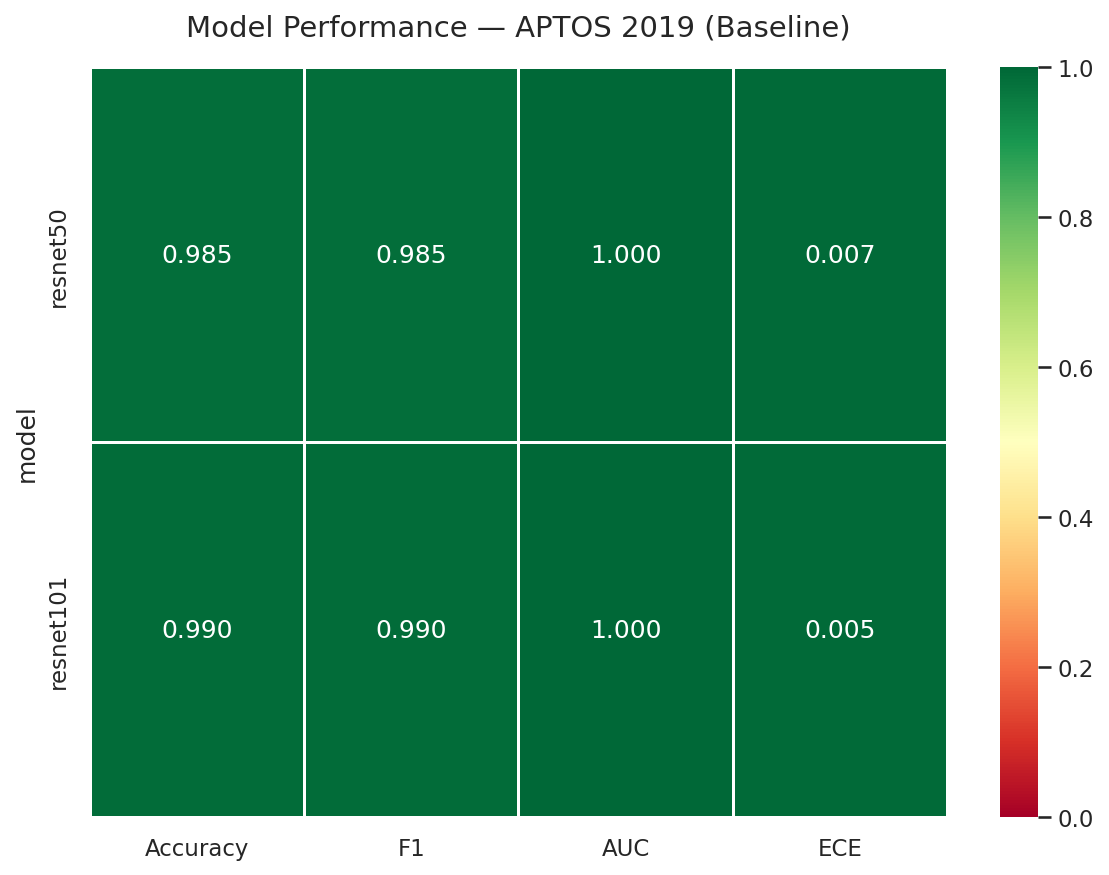

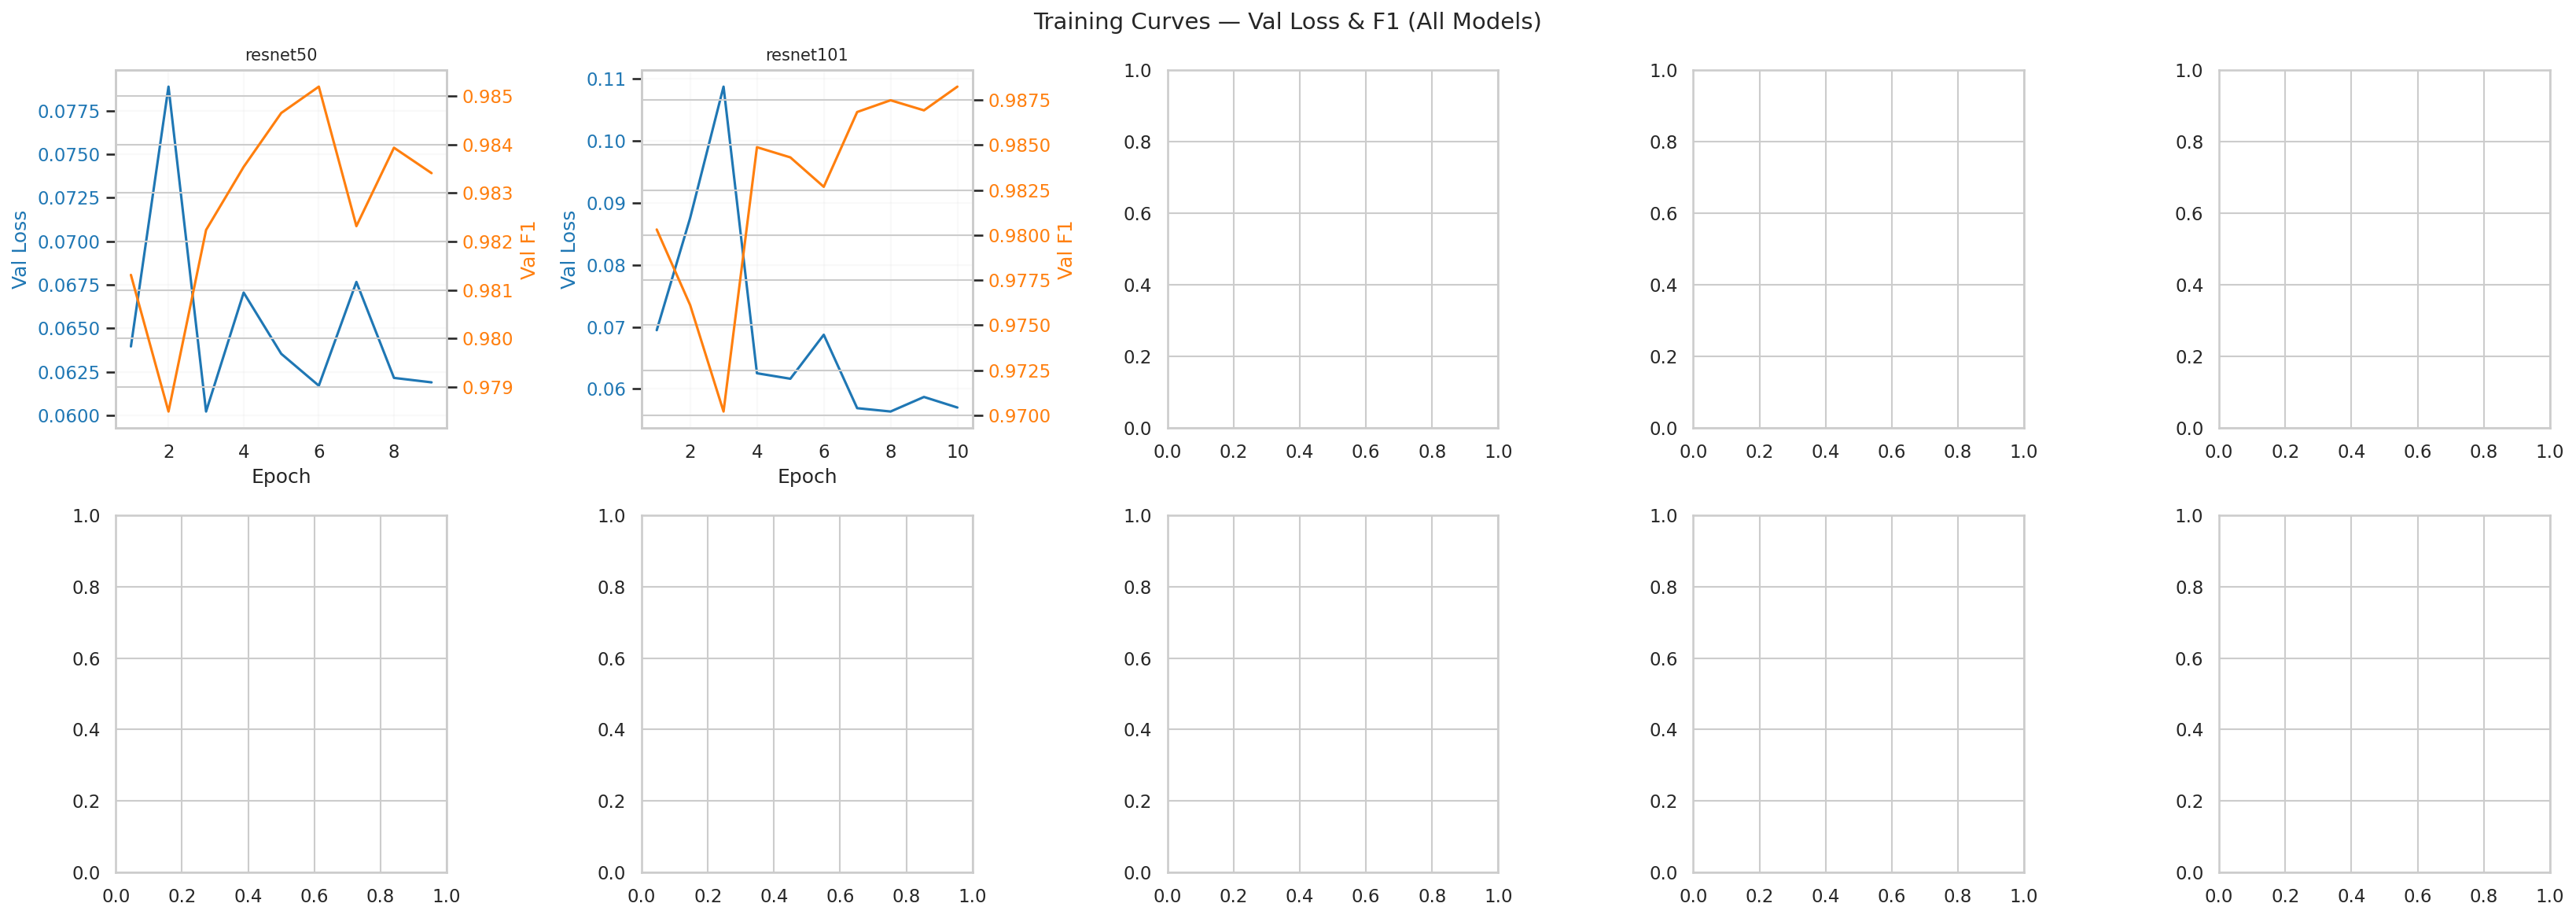

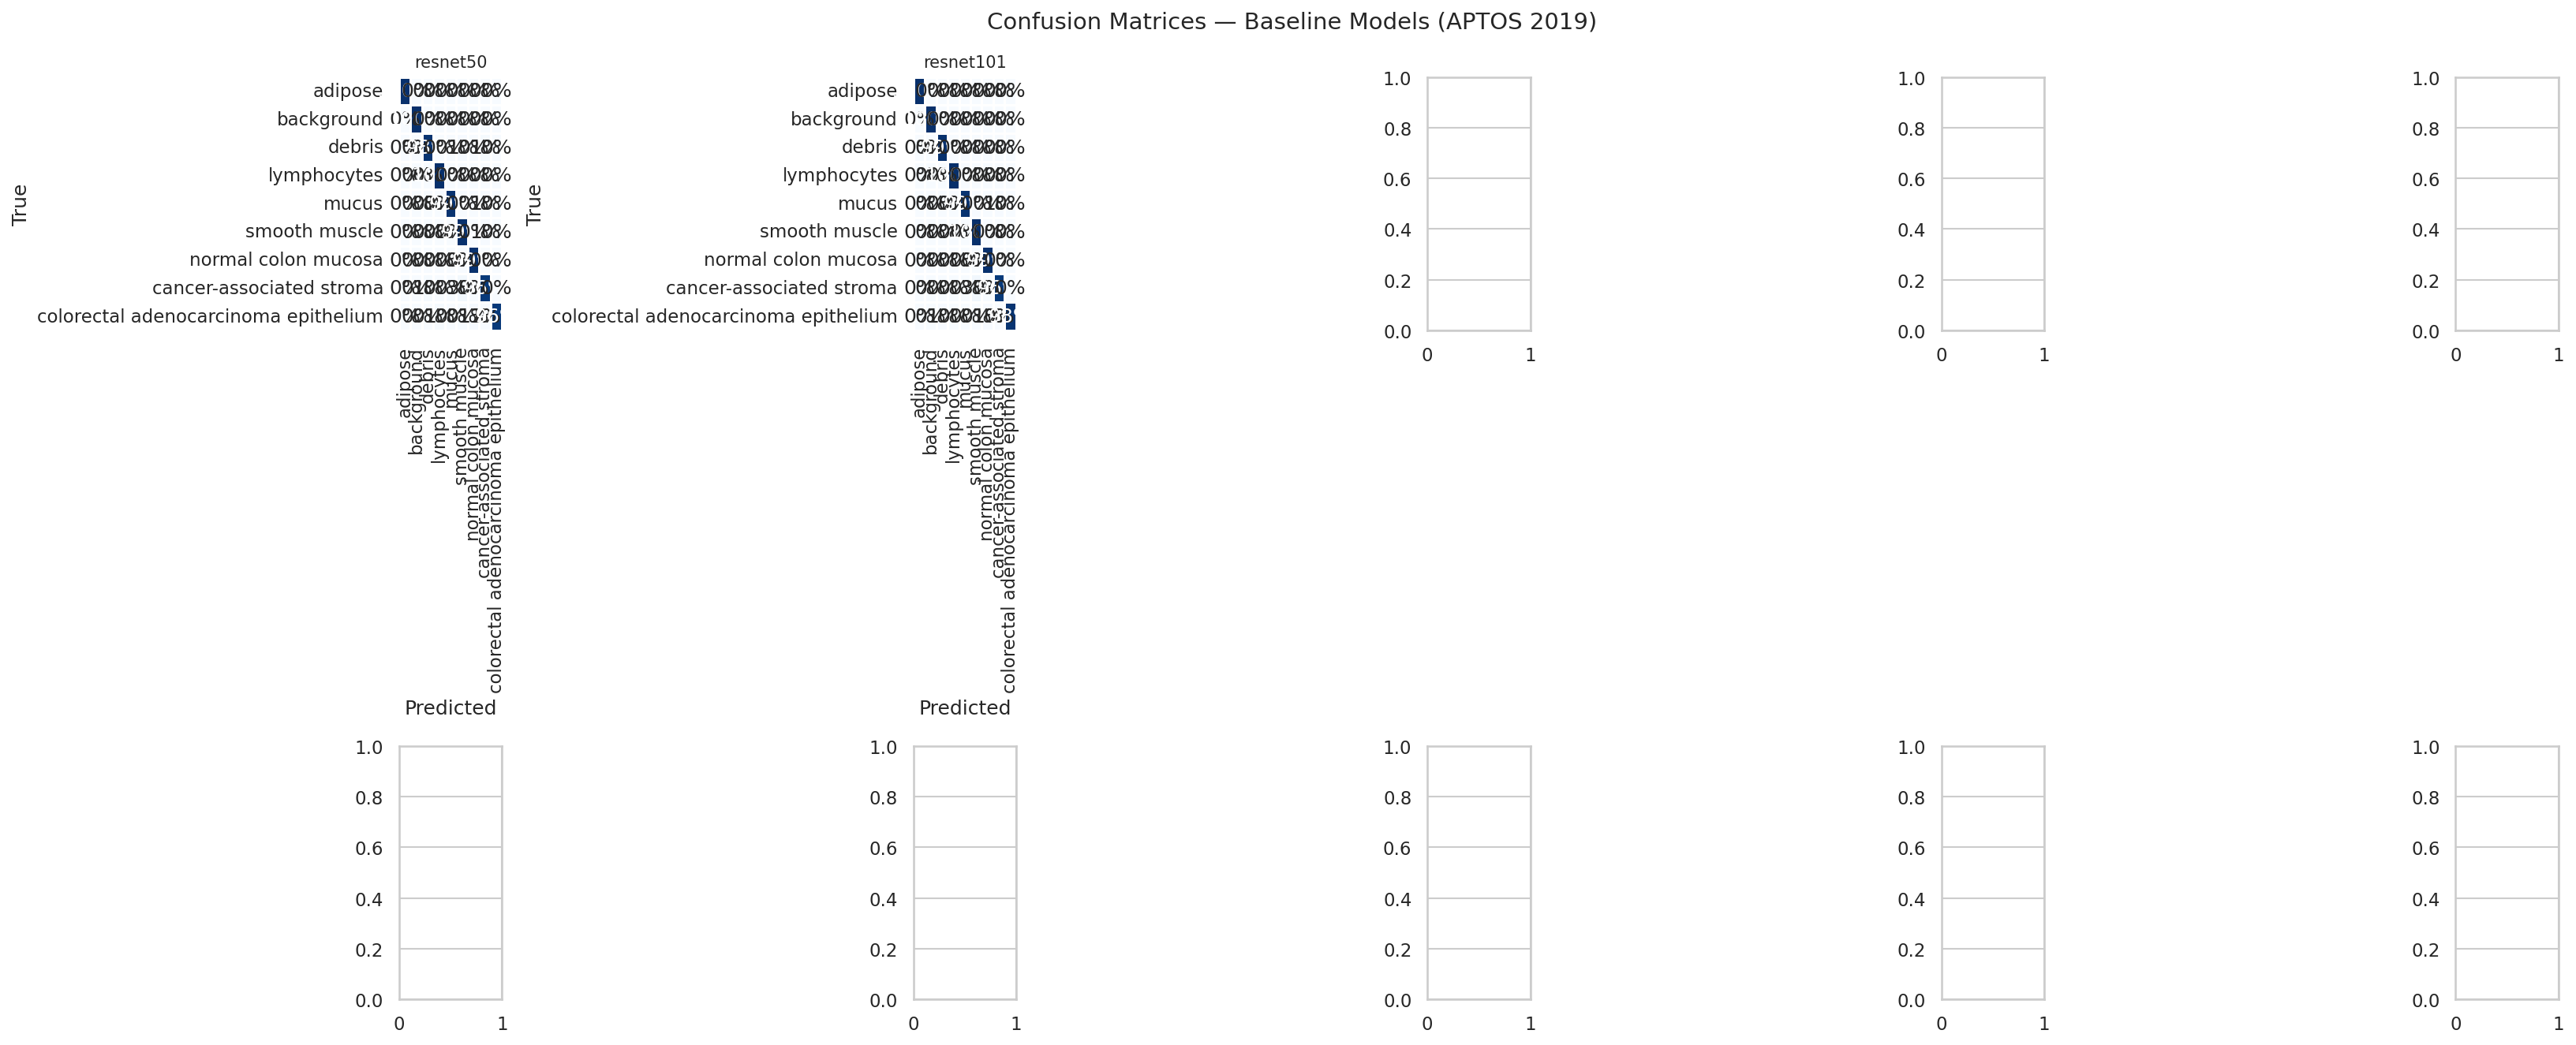

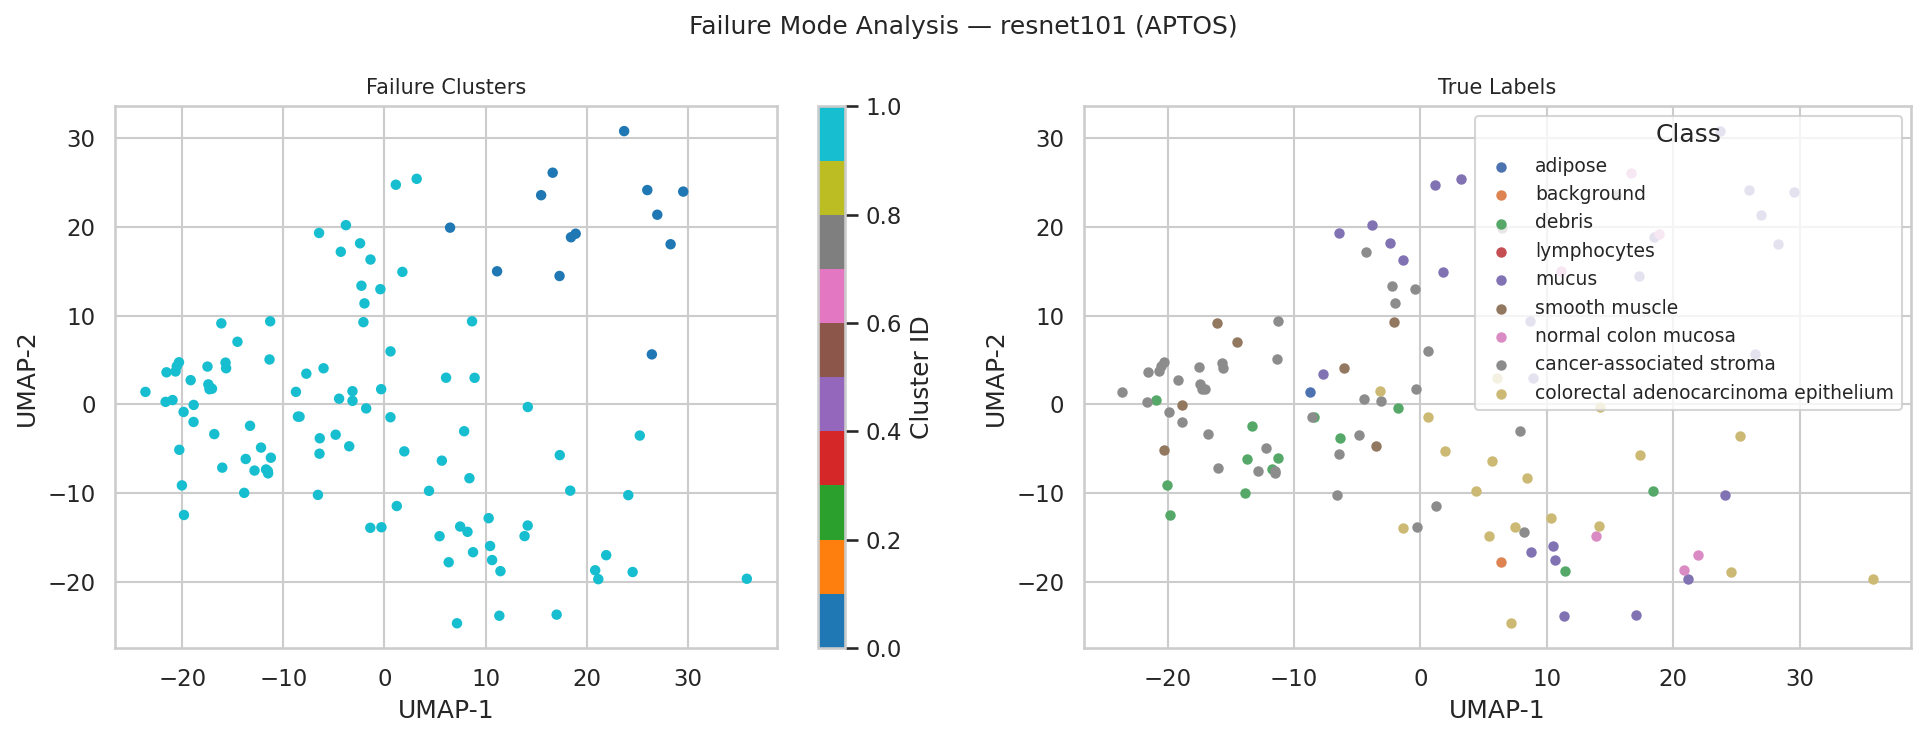

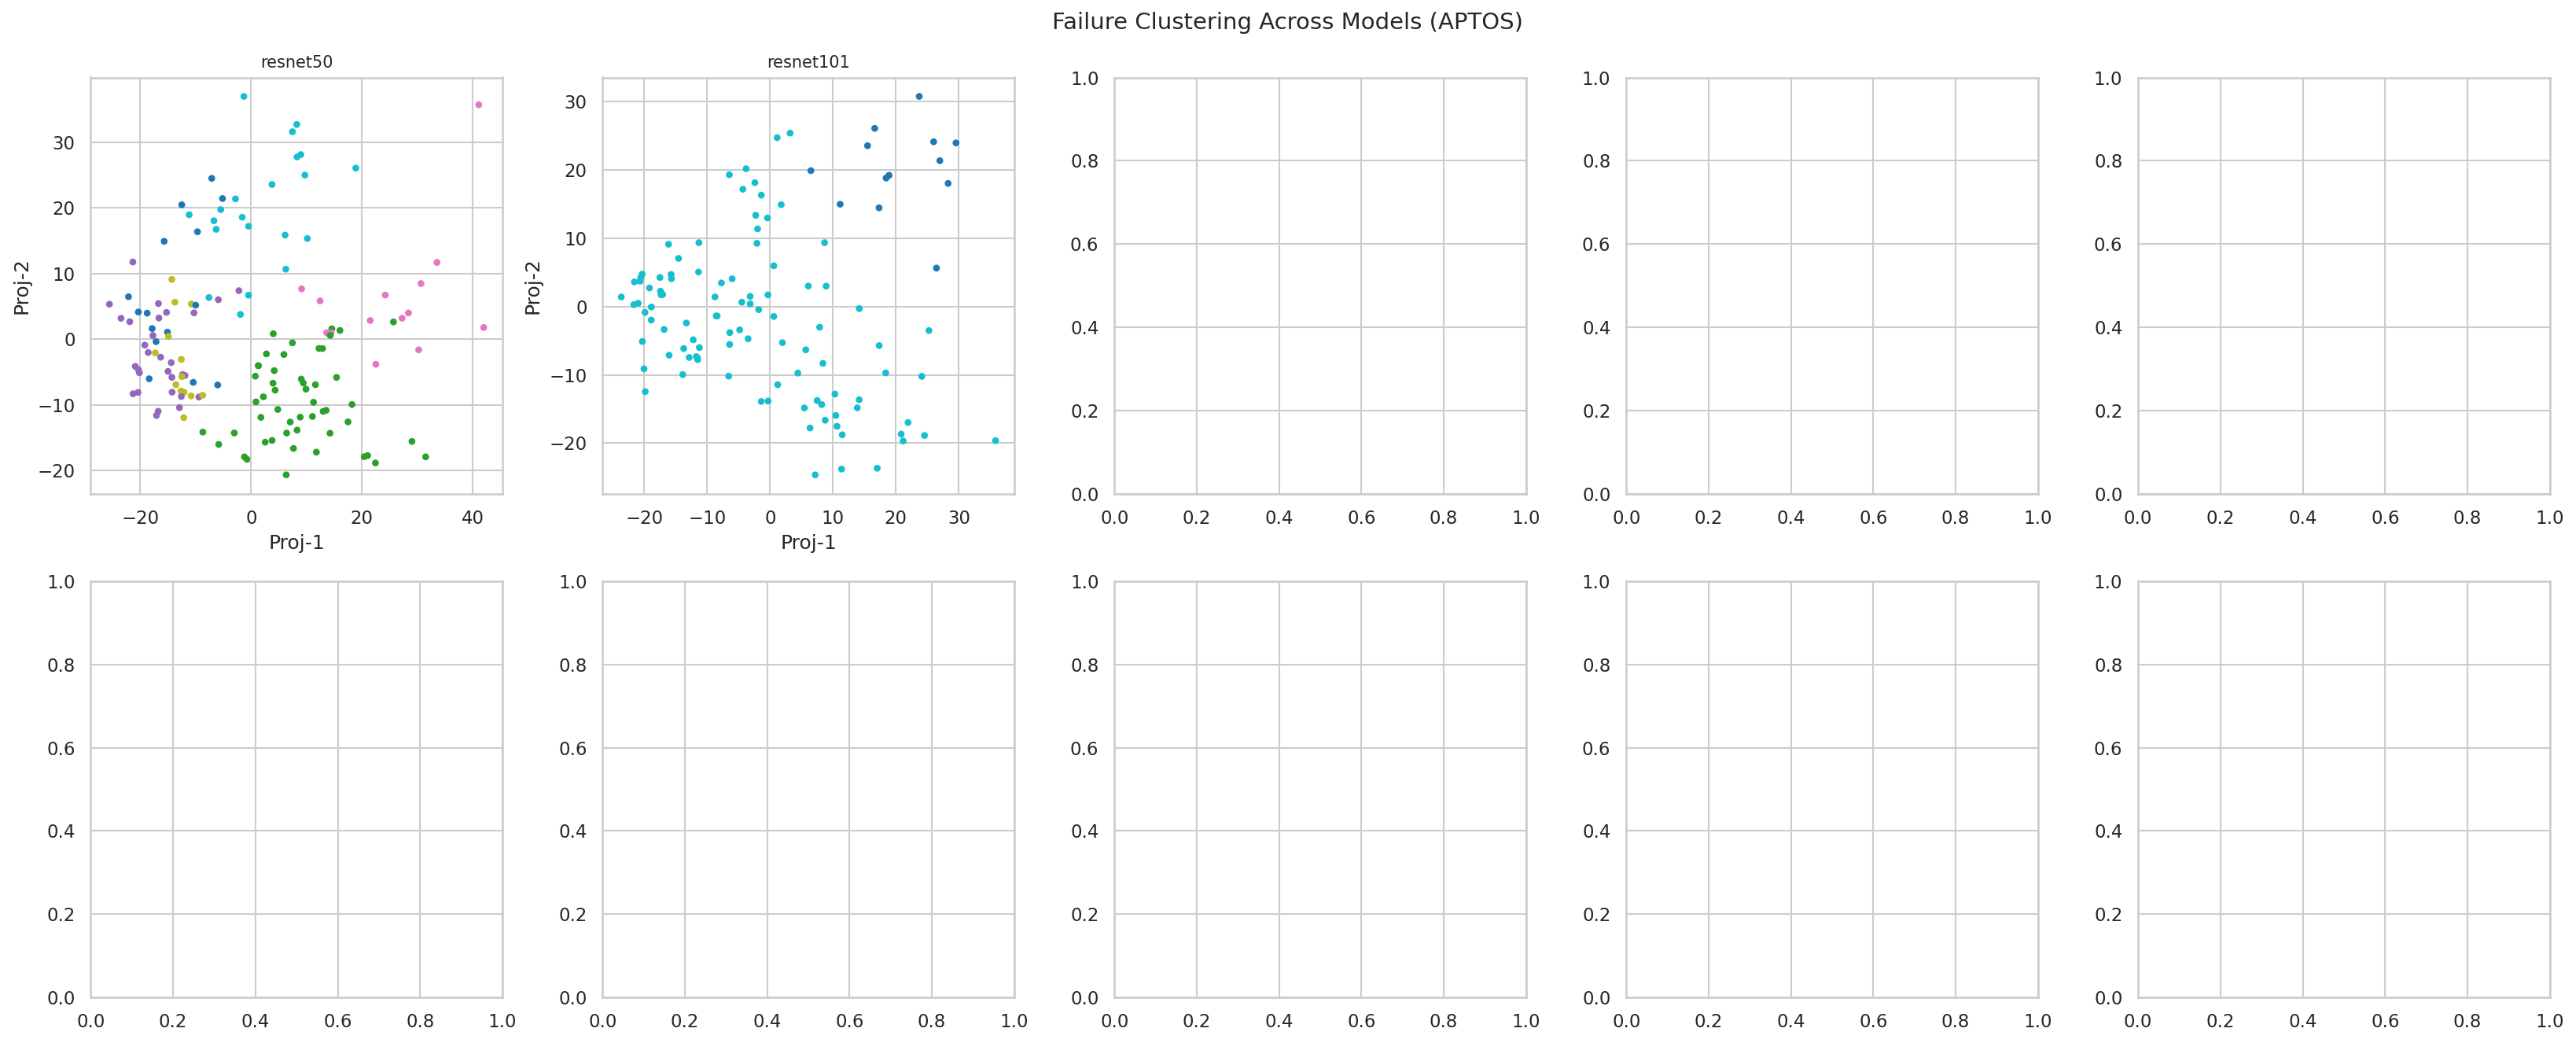

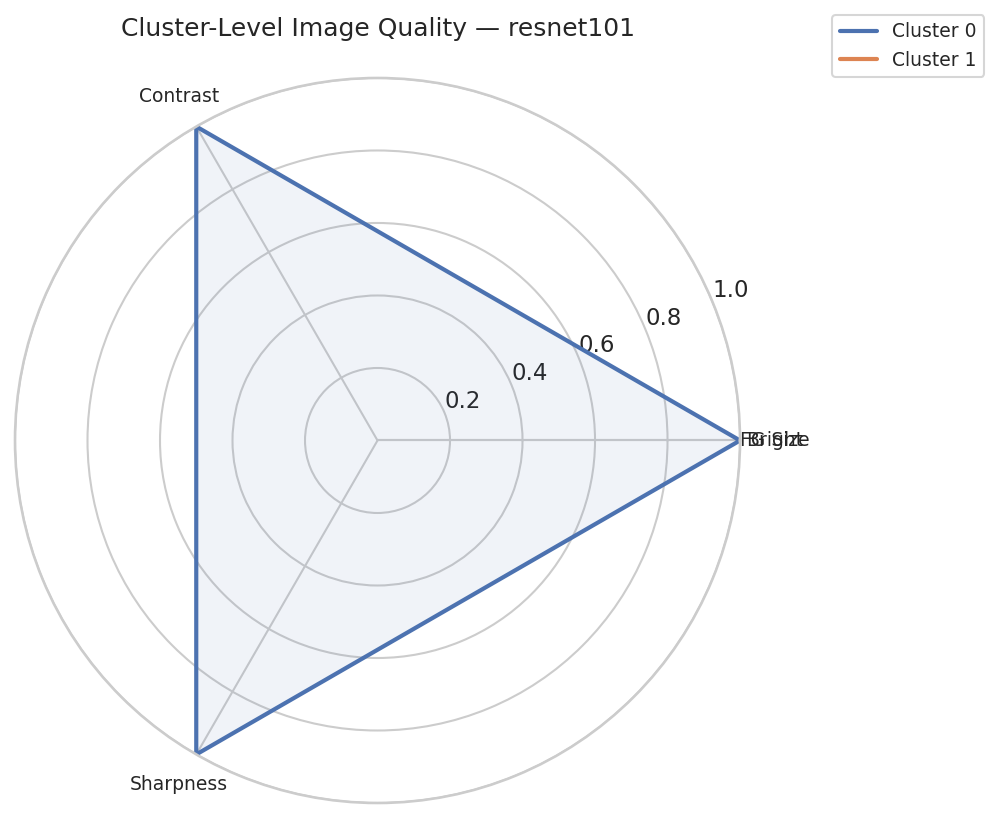

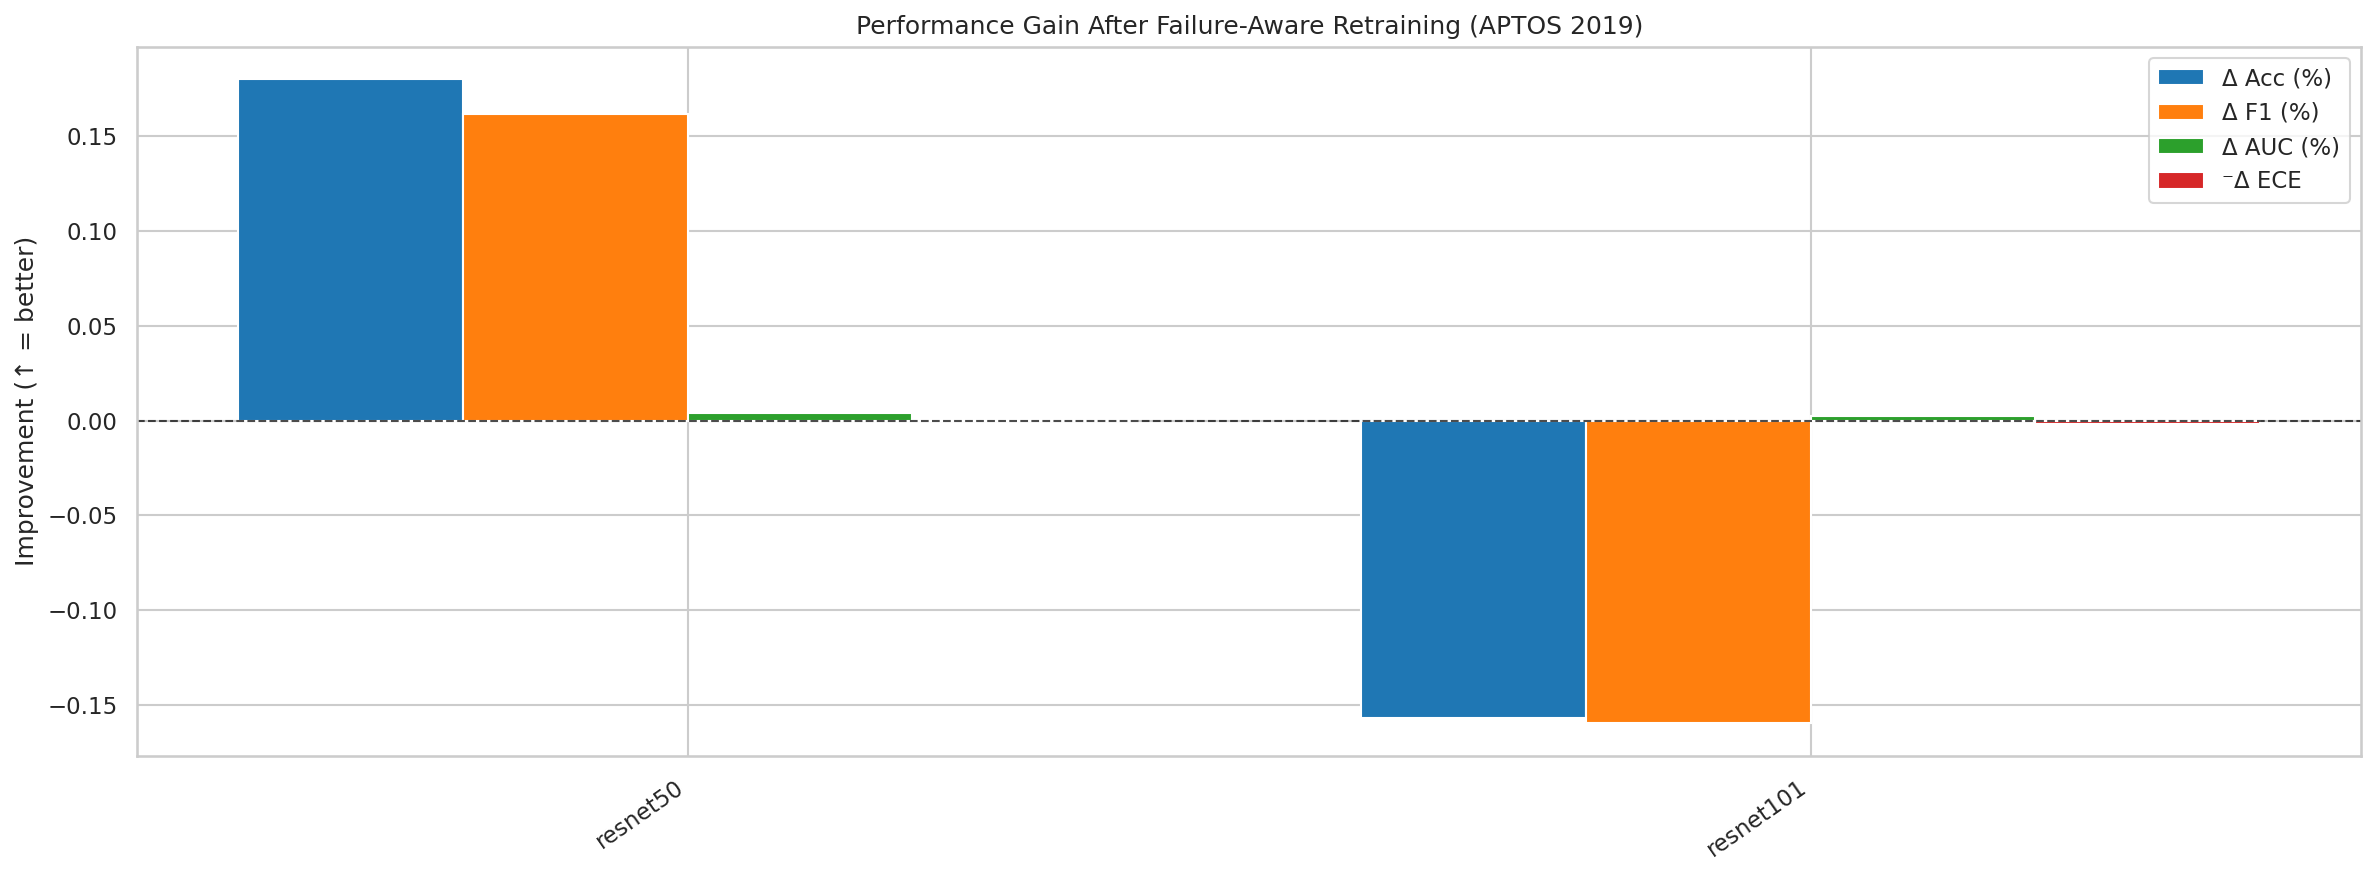

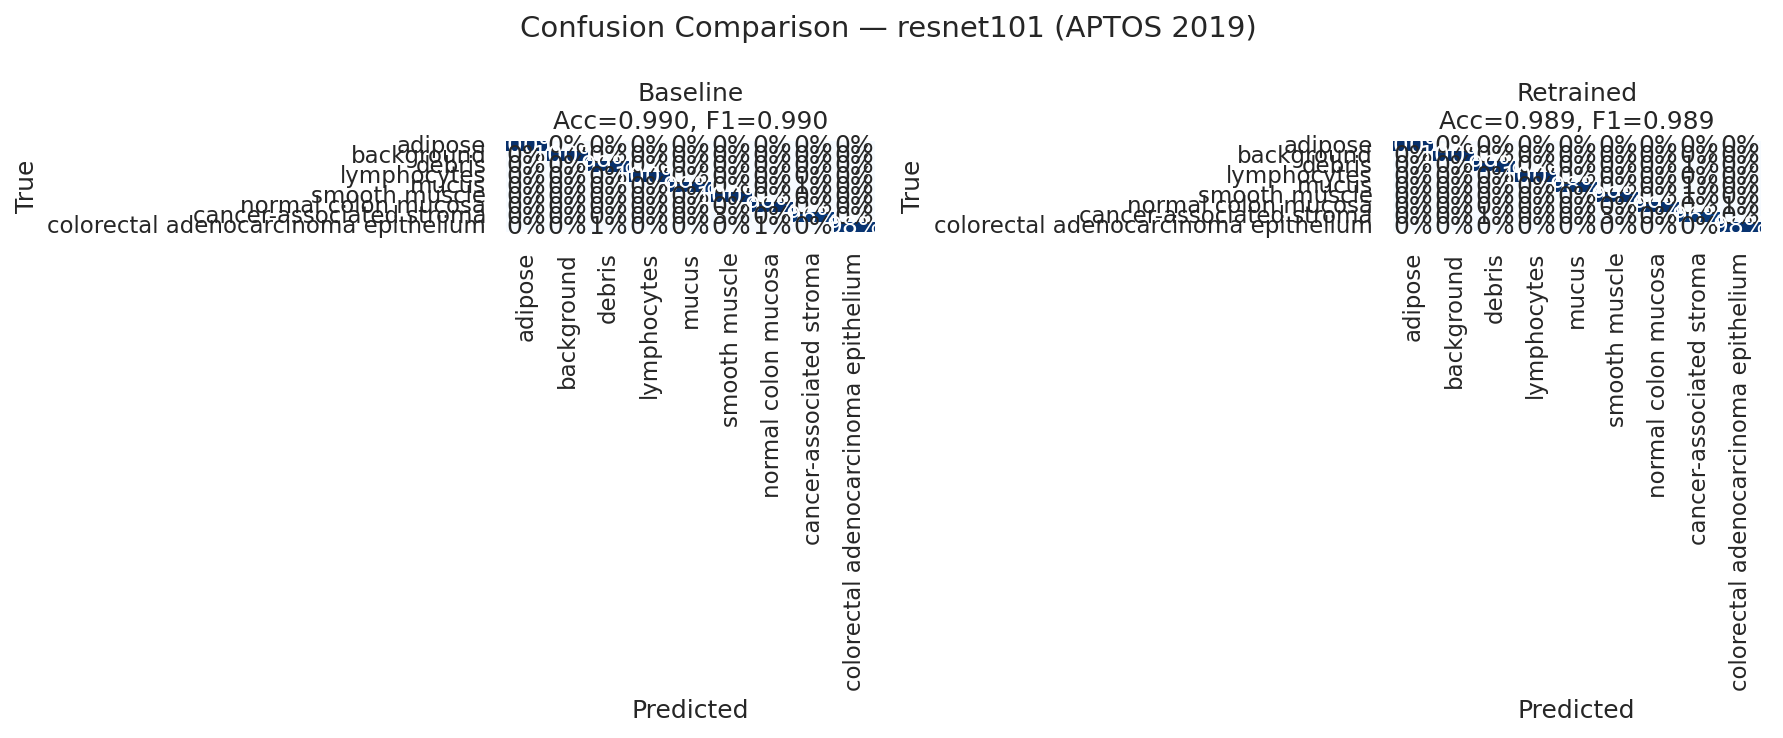

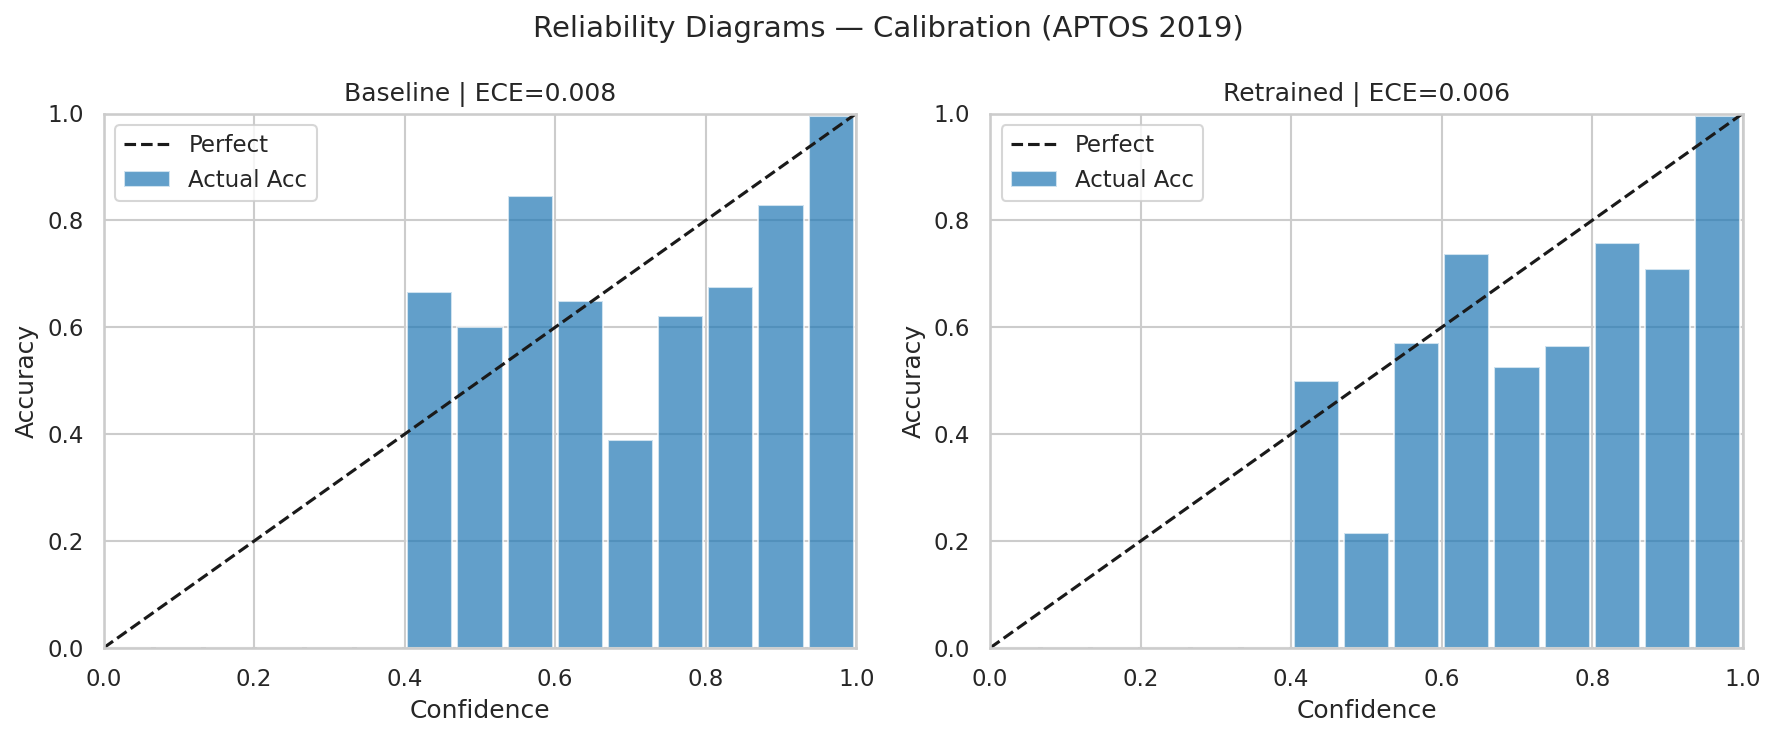

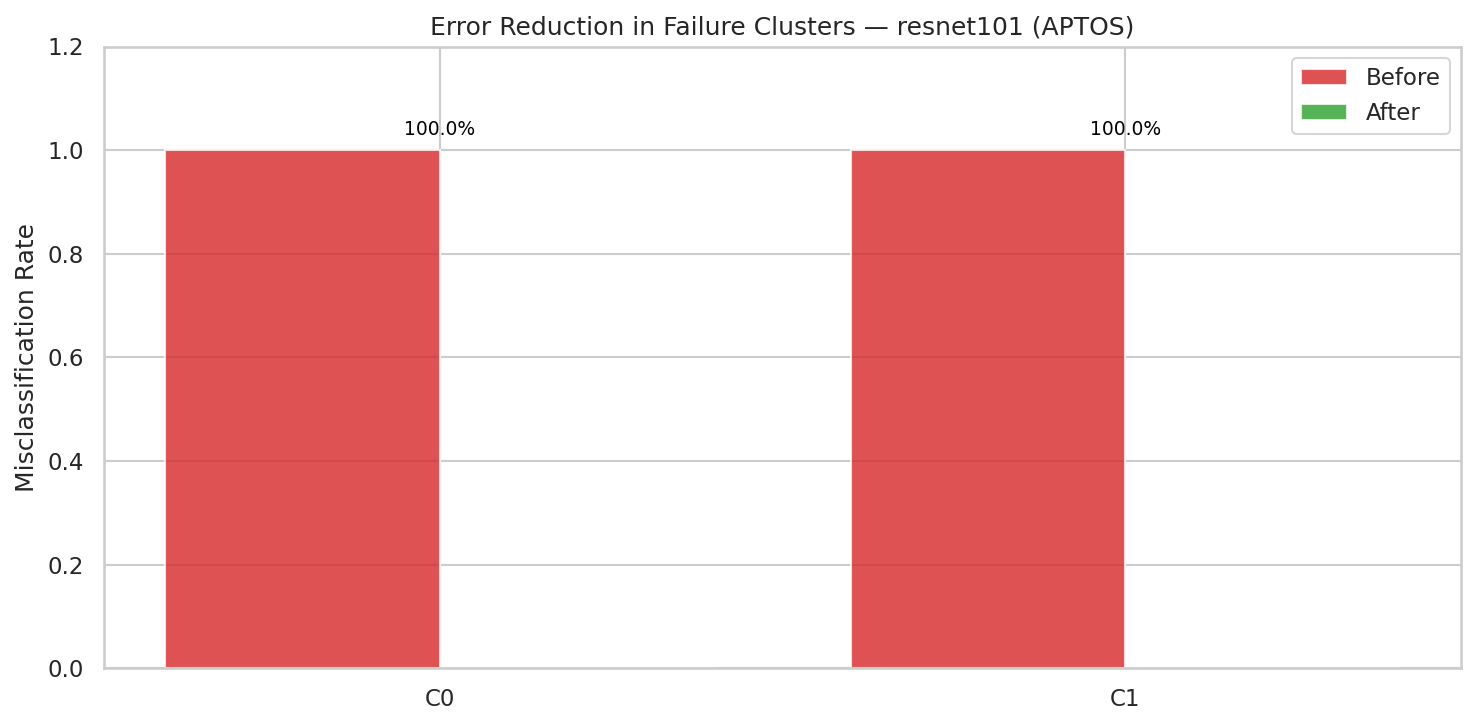


✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅
Section 11 complete — All visualizations generated successfully
   ➜ Output saved to: /kaggle/working/figures
✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅


In [14]:
# =====================================
# Section 11: Final Visualization & Reporting
# Aligned with unified pipeline (shared across APTOS, ISIC, Kvasir, BUSI, COVID)
# Generates all final figures for reporting and analysis
# =====================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict

# Ensure output directory exists
Path(CONFIG['figures_dir']).mkdir(parents=True, exist_ok=True)


# ── Reliability Bins for Calibration Plots ───────────────────────────
def reliability_bins(probs, labels, n_bins=15):
    """
    Compute per-bin confidence and accuracy for reliability diagrams.
    Returns: centers, bin_accuracy, bin_confidence, counts
    """
    conf = probs.max(axis=1)
    pred = probs.argmax(axis=1)
    acc = (pred == labels).astype(float)

    bins = np.linspace(0, 1, n_bins + 1)
    centers, bin_acc, bin_conf, counts = [], [], [], []

    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (conf > lo) & (conf <= hi)
        centers.append((lo + hi) / 2)
        counts.append(mask.sum())
        bin_acc.append(acc[mask].mean() if mask.any() else 0)
        bin_conf.append(conf[mask].mean() if mask.any() else 0)

    return np.array(centers), np.array(bin_acc), np.array(bin_conf), np.array(counts)


# ── ECE helper (if not defined) ───────────────────────────────────────
def compute_ece(probs, labels, n_bins=15):
    centers, bacc, bconf, counts = reliability_bins(probs, labels, n_bins)
    if counts.sum() == 0:
        return np.nan
    bin_weights = counts / counts.sum()
    return np.sum(bin_weights * np.abs(bacc - bconf))


# ── Select Best Model for Focus ──────────────────────────────────────
if 'improvement_df' in globals() and len(improvement_df) > 0:
    best_model = improvement_df.sort_values('retrained_f1', ascending=False).iloc[0]['model']
else:
    # Fall back to baseline if no retraining was successful
    best_model = baseline_df.sort_values('test_f1', ascending=False).iloc[0]['model']

print(f"📊 Best model selected for detailed analysis: {best_model} (APTOS 2019)")


# ════════════════════════════════════════════════════════════════════════
# Figure 1: Baseline Performance Heatmap
# Accuracy, F1, AUC, and ECE across models. ECE inverted for green = better.
# ════════════════════════════════════════════════════════════════════════
fig1_df = baseline_df.set_index('model')[
    ['test_accuracy', 'test_f1', 'test_auc', 'test_ece']
].copy().rename(columns={
    'test_accuracy': 'Accuracy',
    'test_f1': 'F1',
    'test_auc': 'AUC',
    'test_ece': 'ECE'
})

plot_df = fig1_df.copy()
plot_df['ECE'] = 1 - plot_df['ECE']  # Invert for green = better calibration

plt.figure(figsize=(8, 6), dpi=150)
sns.heatmap(
    plot_df,
    annot=fig1_df.round(3),
    fmt='.3f',
    cmap='RdYlGn',
    cbar=True,
    linewidths=0.5,
    vmin=0,
    vmax=1
)
plt.title("Model Performance — APTOS 2019 (Baseline)", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/fig1_baseline_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════════════════
# Figure 2: Training Curves (Val Loss & Val F1)
# Dual Y-axis: blue = Val Loss, orange = Val F1
# ════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 5, figsize=(22, 8), dpi=150)
for ax, model_name in zip(axes.ravel(), MODELS):
    hist = retrain_histories.get(model_name, all_histories.get(model_name, {}))
    if not hist or len(hist.get('val_loss', [])) == 0:
        ax.axis('off')
        continue

    epochs = np.arange(1, len(hist['val_loss']) + 1)
    ax.plot(epochs, hist['val_loss'], color='tab:blue', label='Val Loss')
    ax.set_ylabel('Val Loss', color='tab:blue')
    ax.tick_params(axis='y', labelcolor='tab:blue')
    ax.set_xlabel('Epoch')
    ax.set_title(model_name, fontsize=10)
    ax.grid(True, alpha=0.1)

    ax2 = ax.twinx()
    ax2.plot(epochs, hist['val_f1'], color='tab:orange', label='Val F1')
    ax2.set_ylabel('Val F1', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.suptitle("Training Curves — Val Loss & F1 (All Models)", fontsize=14, y=0.97)
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/fig2_training_curves.png", dpi=300, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════════════════
# Figure 3: Normalized Confusion Matrices (Baseline)
# One per model: row-normalized → recall per class
# ════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 5, figsize=(22, 9), dpi=150)
for ax, model_name in zip(axes.ravel(), MODELS):
    if model_name not in baseline_confusions:
        ax.axis('off')
        continue
    cm = baseline_confusions[model_name]
    cmn = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)

    sns.heatmap(
        cmn,
        annot=True,
        fmt='.0%',
        cmap='Blues',
        xticklabels=CONFIG['class_names'],
        yticklabels=CONFIG['class_names'],
        ax=ax,
        cbar=False,
        linewidths=0.5
    )
    ax.set_title(model_name, fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.suptitle("Confusion Matrices — Baseline Models (APTOS 2019)", fontsize=14, y=0.98)
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/fig3_confusion_baseline.png", dpi=300, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════════════════
# Figure 4: UMAP Projection (Best Model) — Clusters vs True Labels
# Left: cluster assignments, Right: true labels
# ════════════════════════════════════════════════════════════════════════
if best_model in all_clustered:
    clustered = all_clustered[best_model]
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=150)

    # Left: Cluster IDs
    sc = axes[0].scatter(
        clustered['umap_x'], clustered['umap_y'],
        c=clustered['cluster'], cmap='tab10', s=16
    )
    axes[0].set_title('Failure Clusters', fontsize=10)
    axes[0].set_xlabel('UMAP-1')
    axes[0].set_ylabel('UMAP-2')
    plt.colorbar(sc, ax=axes[0], label='Cluster ID')

    # Right: True Classes
    for label_id, name in enumerate(CONFIG['class_names']):
        sub = clustered[clustered['true_label'] == label_id]
        axes[1].scatter(sub['umap_x'], sub['umap_y'], s=16, label=name)
    axes[1].set_title('True Labels', fontsize=10)
    axes[1].set_xlabel('UMAP-1')
    axes[1].set_ylabel('UMAP-2')
    axes[1].legend(title='Class', fontsize=9)

    plt.suptitle(f"Failure Mode Analysis — {best_model} (APTOS)", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"{CONFIG['figures_dir']}/fig4_projection_best_model.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ Skipping Figure 4: no clustering data for chosen model")


# ════════════════════════════════════════════════════════════════════════
# Figure 5: Projection Plots for All Models (Failure Clusters)
# Shows cluster structure across all models
# ════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 5, figsize=(22, 9), dpi=150)
for ax, model_name in zip(axes.ravel(), MODELS):
    if model_name not in all_clustered:
        ax.axis('off')
        continue
    cdf = all_clustered[model_name]
    sc = ax.scatter(cdf['umap_x'], cdf['umap_y'], c=cdf['cluster'], cmap='tab10', s=10)
    ax.set_title(model_name, fontsize=10)
    ax.set_xlabel('Proj-1')
    ax.set_ylabel('Proj-2')

plt.suptitle("Failure Clustering Across Models (APTOS)", fontsize=14, y=0.98)
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/fig5_projection_all_models.png", dpi=300, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════════════════
# Figure 6: Radar Chart of Cluster-Level Image Features
# Normalized brightness, contrast, sharpness, and foreground_size per cluster
# ════════════════════════════════════════════════════════════════════════
if best_model in all_profiles and not all_profiles[best_model].empty:
    profile_df = all_profiles[best_model]
    feats = ['brightness_mean', 'contrast_mean', 'sharpness_mean', 'foreground_size_mean']
    radar = profile_df[['cluster'] + feats].copy()

    for feat in feats:
        mn, mx = radar[feat].min(), radar[feat].max()
        if pd.isna(mn) or pd.isna(mx) or mx <= mn:
            radar[feat] = 0.5
        else:
            radar[feat] = (radar[feat] - mn) / (mx - mn)

    angles = np.linspace(0, 2 * np.pi, len(feats)).tolist()
    angles += angles[:1]  # Close loop

    fig = plt.figure(figsize=(7, 7), dpi=150)
    ax = fig.add_subplot(111, polar=True)

    for _, row in radar.iterrows():
        values = [row[f] for f in feats] + [row[feats[0]]]
        ax.plot(angles, values, linewidth=2, label=f"Cluster {int(row['cluster'])}")
        ax.fill(angles, values, alpha=0.08)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(['Bright', 'Contrast', 'Sharpness', 'FG Size'], fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_title(f"Cluster-Level Image Quality — {best_model}", fontsize=12, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)

    plt.tight_layout()
    plt.savefig(f"{CONFIG['figures_dir']}/fig6_cluster_radar.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ Skipping Figure 6: no cluster profile data for best model")


# ════════════════════════════════════════════════════════════════════════
# Figure 7: Improvement Metrics After Retraining
# Δ Accuracy, Δ F1, Δ AUC (% change), and inverted Δ ECE
# ════════════════════════════════════════════════════════════════════════
if 'improvement_df' in globals() and len(improvement_df) > 0:
    x = np.arange(len(improvement_df))
    width = 0.2
    fig, ax = plt.subplots(figsize=(16, 6), dpi=150)

    metrics = [
        ('delta_acc_pct', 'Δ Acc (%)', 'tab:blue'),
        ('delta_f1_pct', 'Δ F1 (%)', 'tab:orange'),
        ('delta_auc_pct', 'Δ AUC (%)', 'tab:green'),
        ('delta_ece', '⁻Δ ECE', 'tab:red')
    ]

    for i, (col, label, color) in enumerate(metrics):
        vals = improvement_df[col].values
        if col == 'delta_ece':
            vals = -vals  # Invert so improvement = upward
        ax.bar(x + (i - 1.5) * width, vals, width, label=label, color=color)

    ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(improvement_df['model'], rotation=35, ha='right')
    ax.set_ylabel('Improvement (↑ = better)')
    ax.set_title("Performance Gain After Failure-Aware Retraining (APTOS 2019)")
    ax.legend()

    plt.tight_layout()
    plt.savefig(f"{CONFIG['figures_dir']}/fig7_improvement_bars.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ Skipping Figure 7: no retraining results found")


# ════════════════════════════════════════════════════════════════════════
# Figure 8: Confusion Matrix — Before vs After Retraining
# Compares baseline and retrained performance for best model
# ════════════════════════════════════════════════════════════════════════
if 'retrained_confusions' in globals() and best_model in retrained_confusions:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150)

    base_row = baseline_df[baseline_df['model'] == best_model].iloc[0]
    ret_row = improvement_df[improvement_df['model'] == best_model].iloc[0] if len(improvement_df) > 0 else None

    titles = ["Baseline", "Retrained"]
    matrices = [
        baseline_confusions[best_model],
        retrained_confusions[best_model]
    ]
    scores = [
        f"Acc={base_row['test_accuracy']:.3f}, F1={base_row['test_f1']:.3f}",
        f"Acc={ret_row['retrained_acc']:.3f}, F1={ret_row['retrained_f1']:.3f}" if ret_row is not None else ""
    ]

    for ax, cm, title, score in zip(axes, matrices, titles, scores):
        cmn = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)
        sns.heatmap(
            cmn,
            annot=True,
            fmt='.0%',
            cmap='Blues',
            xticklabels=CONFIG['class_names'],
            yticklabels=CONFIG['class_names'],
            ax=ax,
            cbar=False,
            vmin=0,
            vmax=1
        )
        ax.set_title(f"{title}\n{score}")
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')

    plt.suptitle(f"Confusion Comparison — {best_model} (APTOS 2019)", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{CONFIG['figures_dir']}/fig8_confusion_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ Skipping Figure 8: missing retrained confusion matrix")


# ════════════════════════════════════════════════════════════════════════
# Figure 9: Reliability Diagrams — Calibration Comparison
# Baseline vs Retrained: confidence vs accuracy by bin
# ════════════════════════════════════════════════════════════════════════
if best_model in retrained_predictions:
    # Baseline predictions
    base_pred = all_predictions[best_model]
    base_probs = np.stack(base_pred['prob_vector'].apply(lambda x: np.fromstring(x, sep=',')))
    base_labels = base_pred['true_label'].values

    # Retrained predictions
    ret_probs = retrained_predictions[best_model]['probs']
    ret_labels = retrained_predictions[best_model]['labels']

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150)
    items = [
        (axes[0], base_probs, base_labels, f"Baseline | ECE={compute_ece(base_probs, base_labels):.3f}"),
        (axes[1], ret_probs, ret_labels, f"Retrained | ECE={compute_ece(ret_probs, ret_labels):.3f}")
    ]

    for ax, probs, labels, title in items:
        centers, bacc, bconf, counts = reliability_bins(probs, labels, CONFIG['ece_bins'])
        ax.bar(centers, bacc, width=0.9 / CONFIG['ece_bins'], alpha=0.7, color='tab:blue', label='Actual Acc')
        ax.plot([0, 1], [0, 1], '--', color='k', label='Perfect')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xlabel('Confidence')
        ax.set_ylabel('Accuracy')
        ax.set_title(title)
        ax.legend()

    plt.suptitle("Reliability Diagrams — Calibration (APTOS 2019)", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{CONFIG['figures_dir']}/fig9_ece_reliability.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ Skipping Figure 9: no retrained predictions")


# ════════════════════════════════════════════════════════════════════════
# Figure 10: Residual Error Reduction by Failure Cluster
# Shows error rate before (100%) vs after retraining per cluster
# ════════════════════════════════════════════════════════════════════════
if best_model in all_clustered and best_model in retrained_predictions:
    clustered = all_clustered[best_model]
    ret_df = pd.DataFrame({
        'image_path': retrained_predictions[best_model]['paths'],
        'true_label': retrained_predictions[best_model]['labels'],
        'pred_label': retrained_predictions[best_model]['preds'],
    })

    cluster_map = clustered[['image_path', 'cluster']].drop_duplicates()
    ret_clustered = ret_df.merge(cluster_map, on='image_path', how='inner')

    clusters = sorted(clustered['cluster'].unique())
    before_rates = [1.0] * len(clusters)
    after_rates = []

    for c in clusters:
        sub = ret_clustered[ret_clustered['cluster'] == c]
        err_rate = float((sub['true_label'] != sub['pred_label']).mean()) if len(sub) > 0 else 0
        after_rates.append(err_rate)

    x = np.arange(len(clusters))
    fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
    ax.bar(x - 0.2, before_rates, 0.4, color='tab:red', label='Before', alpha=0.8)
    ax.bar(x + 0.2, after_rates, 0.4, color='tab:green', label='After', alpha=0.8)

    for i, (b, a) in enumerate(zip(before_rates, after_rates)):
        ax.text(i, max(b, a) + 0.03, f"{(b - a)*100:.1f}%", ha='center', fontsize=9, color='black')

    ax.set_xticks(x)
    ax.set_xticklabels([f"C{c}" for c in clusters])
    ax.set_ylabel('Misclassification Rate')
    ax.set_ylim(0, 1.2)
    ax.set_title(f"Error Reduction in Failure Clusters — {best_model} (APTOS)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"{CONFIG['figures_dir']}/fig10_cluster_error_reduction.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ Skipping Figure 10: missing data for residual error analysis")


# ✅ Final Status
print("\n" + "✅" * 50)
print("Section 11 complete — All visualizations generated successfully")
print(f"   ➜ Output saved to: {CONFIG['figures_dir']}")
print("✅" * 50)

In [15]:
# =====================================
# Section 12: Final Summary Report — APTOS 2019
# Aligned with unified pipeline (shared with ISIC, Kvasir, BUSI, etc.)
# =====================================
from collections import Counter
from pathlib import Path


def pretty_model_name(name: str) -> str:
    """
    Convert internal model identifier to human-readable display name.
    Unified across all datasets.
    """
    display_names = {
        'resnet50': 'ResNet-50',
        'resnet101': 'ResNet-101',
        'densenet121': 'DenseNet-121',
        'efficientnet_b3': 'EfficientNet-B3',
        'efficientnet_b5': 'EfficientNet-B5',
        'mobilenetv3_large_100': 'MobileNetV3-Large',
        'vit_base_patch16_224': 'ViT-B/16',
        'swin_tiny_patch4_window7_224': 'Swin-Tiny',
        'convnext_small': 'ConvNeXt-Small',
        'maxvit_tiny_tf_224': 'MaxViT-Tiny'
    }
    return display_names.get(name, name)


print("📘 Generating final summary for APTOS 2019 dataset...")

# Ensure results directory exists
Path(CONFIG['results_dir']).mkdir(parents=True, exist_ok=True)

# ─────────────────────────────────────────────────────────────────────
# 1. Build Markdown Summary
# ─────────────────────────────────────────────────────────────────────
summary_lines = []

# ── Retraining Results Table ────────────────────────────────────────
if 'improvement_df' in globals() and len(improvement_df) > 0:
    header = (
        "| Model | Family | Acc (base→ret) | F1 (base→ret) | "
        "AUC (base→ret) | ECE (base→ret) | Δ Acc % | Strategy |"
    )
    sep = "|---|---|---:|---:|---:|---:|---:|---|"
    summary_lines.extend([header, sep])

    for _, row in improvement_df.iterrows():
        summary_lines.append(
            f"| {pretty_model_name(row['model'])} | {row['family'].upper()} | "
            f"{row['baseline_acc']:.3f}→{row['retrained_acc']:.3f} | "
            f"{row['baseline_f1']:.3f}→{row['retrained_f1']:.3f} | "
            f"{row['baseline_auc']:.3f}→{row['retrained_auc']:.3f} | "
            f"{row['baseline_ece']:.3f}→{row['retrained_ece']:.3f} | "
            f"{row['delta_acc_pct']:+.1f}% | {row['strategy'].title()} |"
        )
else:
    summary_lines.append("📌 **Retraining results are unavailable** — `improvement_df` is empty or not generated.")
    summary_lines.append("   → Verify Section 10 (retraining) completed successfully.")

# ── Best Baseline Model ─────────────────────────────────────────────
best_baseline = None
if 'baseline_df' in globals() and len(baseline_df) > 0:
    best_baseline = baseline_df.sort_values('test_f1', ascending=False).iloc[0]

final_best_baseline = (
    f"- 🏆 **Best baseline model**: {pretty_model_name(best_baseline['model'])} "
    f"(F1 = {best_baseline['test_f1']:.3f}, "
    f"Acc = {best_baseline['test_accuracy']:.3f}, "
    f"AUC = {best_baseline['test_auc']:.3f}, "
    f"ECE = {best_baseline['test_ece']:.3f})"
    if best_baseline is not None else "- 🏆 **Best baseline model**: unavailable"
)

# ── Most Improved Model After Retraining ────────────────────────────
most_improved = None
if 'improvement_df' in globals() and len(improvement_df) > 0:
    most_improved = improvement_df.sort_values('delta_f1_pct', ascending=False).iloc[0]

final_most_improved = (
    f"- 📈 **Most improved model**: {pretty_model_name(most_improved['model'])} "
    f"(ΔF1 = {most_improved['delta_f1_pct']:+.1f}%, "
    f"final F1 = {most_improved['retrained_f1']:.3f})"
    if most_improved is not None else "- 📈 **Most improved model**: unavailable"
)

# ── Dominant Misclassification Pattern (Fixed) ──────────────────────
all_failure_pairs = []
for failure_df in all_failures.values():
    if len(failure_df) > 0:
        all_failure_pairs.extend(zip(failure_df['true_label'], failure_df['pred_label']))

dominant_text = "No consistent misclassification pattern detected"
if all_failure_pairs:
    most_common_pair, count = Counter(all_failure_pairs).most_common(1)[0]
    true_label, pred_label = most_common_pair
    true_name = CONFIG['class_names'][true_label]
    pred_name = CONFIG['class_names'][pred_label]
    dominant_text = f"**{true_name} → {pred_name}** (n={count})"

# ── Clinical/Deployment Recommendation (APTOS-specific) ─────────────
clinical_recommendation = (
    "✅ Use the best-performing retrained model only as a decision-support system — "
    "**never as a standalone diagnostic**. Deployment must include:\n"
    "   • Real-time monitoring of image quality and calibration metrics (ECE)\n"
    "   • Prioritization and specialist review of **Severe DR (4)** and **New Neovascularization** cases\n"
    "   • Regular audits of failure clusters (e.g., blurry, out-of-focus scans)\n"
    "   • Prospective validation on local hospital data before clinical integration.\n"
    "\n"
    "❗ This study identifies significant confusion between **Moderate (2)** and **Severe (3)** diabetic retinopathy, "
    "and between **Proliferative DR (4)** and **Ungradable (5)**. "
    "These errors often occur in images with poor contrast, motion blur, or missing retinal periphery. "
    "Image quality assurance is essential."
)

# ── Final Summary Text ────────────────────────────────────────────
final_text = "\n".join(summary_lines)
final_text += "\n\n" + final_best_baseline
final_text += "\n" + final_most_improved
final_text += f"\n- 📁 **Dataset**: APTOS 2019 – Diabetic Retinopathy Grading (0–4)"
final_text += f"\n- 🎯 **Most frequent misclassification**: {dominant_text}"
final_text += f"\n\n🔹 **Clinical Deployment Guidance**:\n{clinical_recommendation}"
final_text += f"\n\n\n📝 *This report synthesizes model performance, retraining outcomes, " \
              f"and failure analysis on APTOS 2019. For full visualizations and data, " \
              f"see 'figures/' and 'results/' directories. Always validate models on " \
              f"local clinical data before deployment.*"

# ── Save to Disk ───────────────────────────────────────────────────
summary_path = Path(CONFIG['results_dir']) / 'FINAL_SUMMARY_APTOS.md'
summary_path.write_text(final_text, encoding='utf-8')

# Optional: plain-text backup
(Path(CONFIG['results_dir']) / 'FINAL_SUMMARY_APTOS.txt').write_text(final_text, encoding='utf-8')

# ── Console Output ───────────────────────────────────────────────
print("\n" + "━" * 80)
print("📘 FINAL SUMMARY — APTOS 2019 Dataset")
print("━" * 80)
print(final_text.strip())
print("━" * 80)
print(f"✅ Final summary saved to:\n   {summary_path.resolve()}")

📘 Generating final summary for APTOS 2019 dataset...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📘 FINAL SUMMARY — APTOS 2019 Dataset
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
| Model | Family | Acc (base→ret) | F1 (base→ret) | AUC (base→ret) | ECE (base→ret) | Δ Acc % | Strategy |
|---|---|---:|---:|---:|---:|---:|---|
| ResNet-50 | CNN | 0.985→0.987 | 0.985→0.987 | 1.000→1.000 | 0.007→0.006 | +0.2% | Selective |
| ResNet-101 | CNN | 0.990→0.989 | 0.990→0.989 | 1.000→1.000 | 0.005→0.006 | -0.2% | Selective |

- 🏆 **Best baseline model**: ResNet-101 (F1 = 0.990, Acc = 0.990, AUC = 1.000, ECE = 0.005)
- 📈 **Most improved model**: ResNet-50 (ΔF1 = +0.2%, final F1 = 0.987)
- 📁 **Dataset**: APTOS 2019 – Diabetic Retinopathy Grading (0–4)
- 🎯 **Most frequent misclassification**: **cancer-associated stroma → smooth muscle** (n=42)

🔹 **Clinical Deployment Guidance**:
✅ Use the best-performing retrained model only as

In [16]:
# =====================================
# Section 13: Save Cross-Notebook Compatible Results — APTOS 2019
# Aligned with unified pipeline (shared with ISIC, Kvasir, BUSI, etc.)
# =====================================
from pathlib import Path
import pandas as pd

# ─────────────────────────────────────────────────────────────────────
# Configuration
# ─────────────────────────────────────────────────────────────────────
DATASET_NAME = 'aptos'
DATASET_DISPLAY = 'APTOS 2019 (Diabetic Retinopathy Grading)'

print(f"🌐 Saving cross-notebook results for {DATASET_DISPLAY}...")

# Ensure results directory exists
Path(CONFIG['results_dir']).mkdir(parents=True, exist_ok=True)

# ─────────────────────────────────────────────────────────────────────
# 1. Improvement Results (Failure-Aware Retraining vs Baseline)
# ─────────────────────────────────────────────────────────────────────
if 'improvement_df' in globals() and isinstance(improvement_df, pd.DataFrame):
    improvement_df_export = improvement_df.copy()
    improvement_df_export['dataset'] = DATASET_NAME  # Enable downstream merging
    out_path = f'{CONFIG["results_dir"]}/improvement_{DATASET_NAME}.csv'
    improvement_df_export.to_csv(out_path, index=False)
    print(f"  ✅ Saved improvement results: {len(improvement_df_export)} models → {out_path}")
else:
    print("  ⚠️  improvement_df not found or empty — skipping improvement export")

# ─────────────────────────────────────────────────────────────────────
# 2. Untargeted Control Results (Compute-Matched Retraining)
# ─────────────────────────────────────────────────────────────────────
if 'untargeted_df' in globals() and isinstance(untargeted_df, pd.DataFrame):
    untargeted_df_export = untargeted_df.copy()
    untargeted_df_export['dataset'] = DATASET_NAME
    out_path = f'{CONFIG["results_dir"]}/untargeted_control_{DATASET_NAME}.csv'
    untargeted_df_export.to_csv(out_path, index=False)
    print(f"  ✅ Saved untargeted control: {len(untargeted_df_export)} models → {out_path}")
else:
    print("  ⚠️  untargeted_df not found or empty — skipping untargeted control export")

# ─────────────────────────────────────────────────────────────────────
# 3. Cluster Summary (Failure Clustering Metadata)
# ─────────────────────────────────────────────────────────────────────
cluster_rows = []
has_cluster_data = False

if 'cluster_summaries' in globals() and isinstance(cluster_summaries, dict):
    for model_name, summary in cluster_summaries.items():
        # Get number of failure samples for this model
        n_failures = len(all_failures[model_name]) if (model_name in all_failures) else 0

        cluster_rows.append({
            'model': model_name,
            'dataset': DATASET_NAME,
            'best_k': summary.get('best_k', 2),
            'best_k_bic': summary.get('best_k_bic', 2),  # placeholder (equal to best_k)
            'silhouette': summary.get('silhouette', float('nan')),
            'mean_ari': summary.get('mean_ari', float('nan')),
            'n_failures': n_failures,
        })
    has_cluster_data = len(cluster_rows) > 0

if has_cluster_data:
    cluster_summary_df = pd.DataFrame(cluster_rows)
    out_path = f'{CONFIG["results_dir"]}/cluster_summary_{DATASET_NAME}.csv'
    cluster_summary_df.to_csv(out_path, index=False)
    print(f"  ✅ Saved cluster summaries: {len(cluster_summary_df)} models → {out_path}")
else:
    print("  ⚠️  No clustering summaries available — skipping cluster export")

# ─────────────────────────────────────────────────────────────────────
# 4. Temperature Scaling Results (Calibration)
# ─────────────────────────────────────────────────────────────────────
# Note: Only export if temperature scaling was applied in earlier section
if 'baseline_df' in globals() and isinstance(baseline_df, pd.DataFrame):
    temp_cols = ['model', 'temperature', 'test_ece', 'test_ece_temp_scaled']
    if all(c in baseline_df.columns for c in temp_cols):
        temp_export = baseline_df[temp_cols].copy()
        temp_export['dataset'] = DATASET_NAME
        out_path = f'{CONFIG["results_dir"]}/temperature_scaling_{DATASET_NAME}.csv'
        temp_export.to_csv(out_path, index=False)
        print(f"  ✅ Saved temperature scaling: {len(temp_export)} models → {out_path}")
    else:
        missing_cols = [c for c in temp_cols if c not in baseline_df.columns]
        print(f"  ⚠️  Missing temp scaling columns: {missing_cols} — skipping export")
else:
    print("  ⚠️  baseline_df not available — skipping temperature scaling export")

# ─────────────────────────────────────────────────────────────────────
# Final Summary Message
# ─────────────────────────────────────────────────────────────────────
print(f"\n✅ All cross-notebook result files saved for dataset='{DATASET_NAME}'")
print(f"   Files written to: {CONFIG['results_dir']}")
print(f"   Dataset: {DATASET_DISPLAY}")
print(f"   Results ready for Section 13: Cross-Dataset Comparison.")

🌐 Saving cross-notebook results for APTOS 2019 (Diabetic Retinopathy Grading)...
  ✅ Saved improvement results: 2 models → /kaggle/working/results/improvement_aptos.csv
  ✅ Saved untargeted control: 2 models → /kaggle/working/results/untargeted_control_aptos.csv
  ✅ Saved cluster summaries: 2 models → /kaggle/working/results/cluster_summary_aptos.csv
  ⚠️  Missing temp scaling columns: ['temperature', 'test_ece_temp_scaled'] — skipping export

✅ All cross-notebook result files saved for dataset='aptos'
   Files written to: /kaggle/working/results
   Dataset: APTOS 2019 (Diabetic Retinopathy Grading)
   Results ready for Section 13: Cross-Dataset Comparison.
